# BERT - Enhanced feature attribution analysis
## Full validation set - all 3 methods (IG, SHAP, Attention Rollout)

Attribution results from `attribution.ipynb` are loaded and analyzed across 7 dimensions:


1. POS-tag analysis
2. Lexical sophistication and word rarity
3. Attribution concentration (entropy and Gini)
4. Cross-method agreement (Jaccard overlap)
5. Vocabulary fingerprints
6. Positional analysis
7. Statistical testing with effect sizes (Cohen's d)

## 1. Setup and data loading

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install captum seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 12.1 MB/s eta 0:00:00


In [3]:
import json, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from cycler import cycler
from collections import Counter, defaultdict
from itertools import combinations
from scipy.stats import ttest_ind, mannwhitneyu

import nltk
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk import pos_tag, word_tokenize

STOP_WORDS = set(stopwords.words("english"))

# Shared visual style for the whole notebook.
# All plots use the same seaborn "mako" colour family.
sns.set_theme(style="whitegrid", font_scale=1.1)
MAKO_CMAP = sns.color_palette("mako", as_cmap=True)

def mako_palette(n, reverse=False):
    """Return n colours from the mako palette for bars, lines, histograms, and scatter plots."""
    colors = sns.color_palette("mako", n_colors=max(n, 1))
    if reverse:
        colors = list(reversed(colors))
    return colors[:n]

def apply_mako_style(n_colors=24):
    """Apply mako as the default matplotlib colour cycle."""
    colors = mako_palette(n_colors)
    sns.set_palette(colors)
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
    plt.rcParams["figure.dpi"] = 120
    plt.rcParams["savefig.bbox"] = "tight"

apply_mako_style()

ROOT = "/content/drive/MyDrive/ap-thesis"
RUNS_ROOT = f"{ROOT}/runs"

print("Setup complete.")


Setup complete.


In [4]:
# Load full-validation ratios CSVs
pan_ratios = pd.read_csv(f"{RUNS_ROOT}/results/pan25_full_validation_all_methods_ratios.csv")
am_ratios  = pd.read_csv(f"{RUNS_ROOT}/results/authormix_full_validation_all_methods_ratios.csv")

print(f"PAN25 ratios: {pan_ratios.shape[0]} examples, {pan_ratios['class'].nunique()} classes")
print(f"AuthorMix ratios: {am_ratios.shape[0]} examples, {am_ratios['class'].nunique()} classes")

# Load full-validation attributions JSONs
with open(f"{RUNS_ROOT}/results/pan25_full_validation_all_methods_attributions.json") as f:
    pan_data = json.load(f)

with open(f"{RUNS_ROOT}/results/authormix_full_validation_all_methods_attributions.json") as f:
    am_data = json.load(f)

print(f"PAN25 full attributions: {len(pan_data)} examples")
print(f"AuthorMix full attributions: {len(am_data)} examples")

PAN25 ratios: 3556 examples, 23 classes
AuthorMix ratios: 3642 examples, 14 classes
PAN25 full attributions: 3556 examples
AuthorMix full attributions: 3642 examples


In [5]:
METHODS = [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]

RATIO_TYPES = [
    "content_ratio",
    "punct_ratio",
    "stop_ratio",
    "newline_ratio",
]

def check_ratio_columns(df, name):
    missing = []
    for prefix, _ in METHODS:
        for ratio in RATIO_TYPES:
            col = f"{prefix}_{ratio}"
            if col not in df.columns:
                missing.append(col)
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

    print(f"{name}: all ratio columns found.")


def check_ratio_sums(df, name):
    for prefix, _ in METHODS:
        cols = [f"{prefix}_{r}" for r in RATIO_TYPES]
        sums = df[cols].sum(axis=1)
        print(
            name,
            prefix,
            "min sum:",
            round(sums.min(), 6),
            "max sum:",
            round(sums.max(), 6),
        )

        assert np.allclose(sums, 1.0, atol=1e-6)


def add_nonnewline_ratios(df):
    """
    Add content/punct/stop ratios renormalised over non-newline tokens.
    These columns are needed for fair BERT-vs-ModernBERT comparison.
    """
    df = df.copy()

    for prefix, _ in METHODS:
        denom = (
            df[f"{prefix}_content_ratio"]
            + df[f"{prefix}_punct_ratio"]
            + df[f"{prefix}_stop_ratio"]
        )

        denom = denom.replace(0, np.nan)

        df[f"{prefix}_content_nonnewline_ratio"] = df[f"{prefix}_content_ratio"] / denom
        df[f"{prefix}_punct_nonnewline_ratio"] = df[f"{prefix}_punct_ratio"] / denom
        df[f"{prefix}_stop_nonnewline_ratio"] = df[f"{prefix}_stop_ratio"] / denom

    return df


check_ratio_columns(pan_ratios, "BERT PAN25")
check_ratio_columns(am_ratios, "BERT AuthorMix")

check_ratio_sums(pan_ratios, "BERT PAN25")
check_ratio_sums(am_ratios, "BERT AuthorMix")

pan_ratios = add_nonnewline_ratios(pan_ratios)
am_ratios = add_nonnewline_ratios(am_ratios)

print("Added non-newline-normalised ratio columns.")

BERT PAN25: all ratio columns found.
BERT AuthorMix: all ratio columns found.
BERT PAN25 ig min sum: 1.0 max sum: 1.0
BERT PAN25 gs min sum: 1.0 max sum: 1.0
BERT PAN25 ar min sum: 1.0 max sum: 1.0
BERT AuthorMix ig min sum: 1.0 max sum: 1.0
BERT AuthorMix gs min sum: 1.0 max sum: 1.0
BERT AuthorMix ar min sum: 1.0 max sum: 1.0
Added non-newline-normalised ratio columns.


## 2. Token-level heatmap visualizations

Coloured token heatmaps show what the classifier "sees" for each method.
A sample of examples per key class contrast is displayed.

In [46]:
def build_full_attribution_scores(ex, method_key):
    """
    Given an example dict and a method key ('top_ig', 'top_gs', 'top_ar'),
    return a score array aligned with ex['tokens'].
    Assigns each top-k token to the first unmatched position.
    """
    tokens = ex["tokens"]
    scores = np.zeros(len(tokens))
    top_list = ex[method_key]

    used = set()
    for tok_str, score in top_list:
        for j, t in enumerate(tokens):
            if j not in used and t == tok_str:
                scores[j] = abs(float(score))
                used.add(j)
                break
    return scores


import seaborn as sns
import matplotlib.pyplot as plt

def render_heatmap_text(ax, tokens, scores, title="", max_tokens=80):
    """
    Render tokens as coloured boxes on a matplotlib axis.
    Uses a readable white-to-mako-blue palette.
    """
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")

    if len(tokens) > max_tokens:
        tokens = tokens[:max_tokens]
        scores = scores[:max_tokens]

    smax = scores.max() if scores.max() > 0 else 1.0
    norm_scores = scores / smax

    # choose one blue tone from mako and build a light -> blue cmap
    mako_blue = sns.color_palette("mako", 9)[5]
    cmap = sns.blend_palette(["#f7f7f7", mako_blue], as_cmap=True)

    x, y = 0.01, 0.85
    line_height = 0.13

    for tok, ns in zip(tokens, norm_scores):
        display_tok = tok.replace("##", "")
        txt_width = len(display_tok) * 0.009 + 0.015

        if x + txt_width > 0.99:
            x = 0.01
            y -= line_height
            if y < 0.02:
                break

        color = cmap(ns)

        ax.add_patch(
            plt.Rectangle(
                (x, y - 0.04),
                txt_width,
                0.09,
                facecolor=color,
                edgecolor="white",
                linewidth=0.5,
                alpha=1.0
            )
        )

        r, g, b = color[:3]
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        text_color = "white" if luminance < 0.55 else "black"

        ax.text(
            x + txt_width / 2,
            y,
            display_tok,
            fontsize=6.8,
            ha="center",
            va="center",
            color=text_color,
            fontfamily="monospace"
        )

        x += txt_width + 0.004


import os
import re

def safe_filename(text):
    """
    Make strings safe for file names.
    """
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_-]+", "_", text)
    return text.strip("_").lower()


def plot_example_heatmaps(data, dataset_name, n=4, save_dir=None):
    """
    For each example, show 3 rows (IG / SHAP / AR) of token heatmaps.
    Optionally saves each figure as PNG and PDF.
    """
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for i, ex in enumerate(data[:n]):
        fig, axes = plt.subplots(3, 1, figsize=(16, 5))

        fig.suptitle(
            f"{dataset_name}  |  Example {ex['example_idx']}  |  True class: {ex['class_name']}",
            fontsize=12,
            fontweight="bold",
            y=1.02
        )

        tokens = ex["tokens"]

        for ax, (method_key, method_label) in zip(axes, [
            ("top_ig", "Integrated Gradients"),
            ("top_gs", "GradientShap"),
            ("top_ar", "Attention Rollout"),
        ]):
            scores = build_full_attribution_scores(ex, method_key)
            render_heatmap_text(ax, tokens, scores, title=method_label)

        plt.tight_layout()

        if save_dir is not None:
            dataset_safe = safe_filename(dataset_name)
            class_safe = safe_filename(ex["class_name"])
            example_idx = ex["example_idx"]

            filename_base = f"{dataset_safe}_example_{example_idx}_{class_safe}_heatmap"

            png_path = os.path.join(save_dir, filename_base + ".png")
            pdf_path = os.path.join(save_dir, filename_base + ".pdf")

            fig.savefig(png_path, dpi=300, bbox_inches="tight")
            fig.savefig(pdf_path, bbox_inches="tight")

            print(f"Saved PNG: {png_path}")
            print(f"Saved PDF: {pdf_path}")

        plt.show()

PAN25: Human vs GPT-4o
Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_1_human_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_1_human_heatmap.pdf


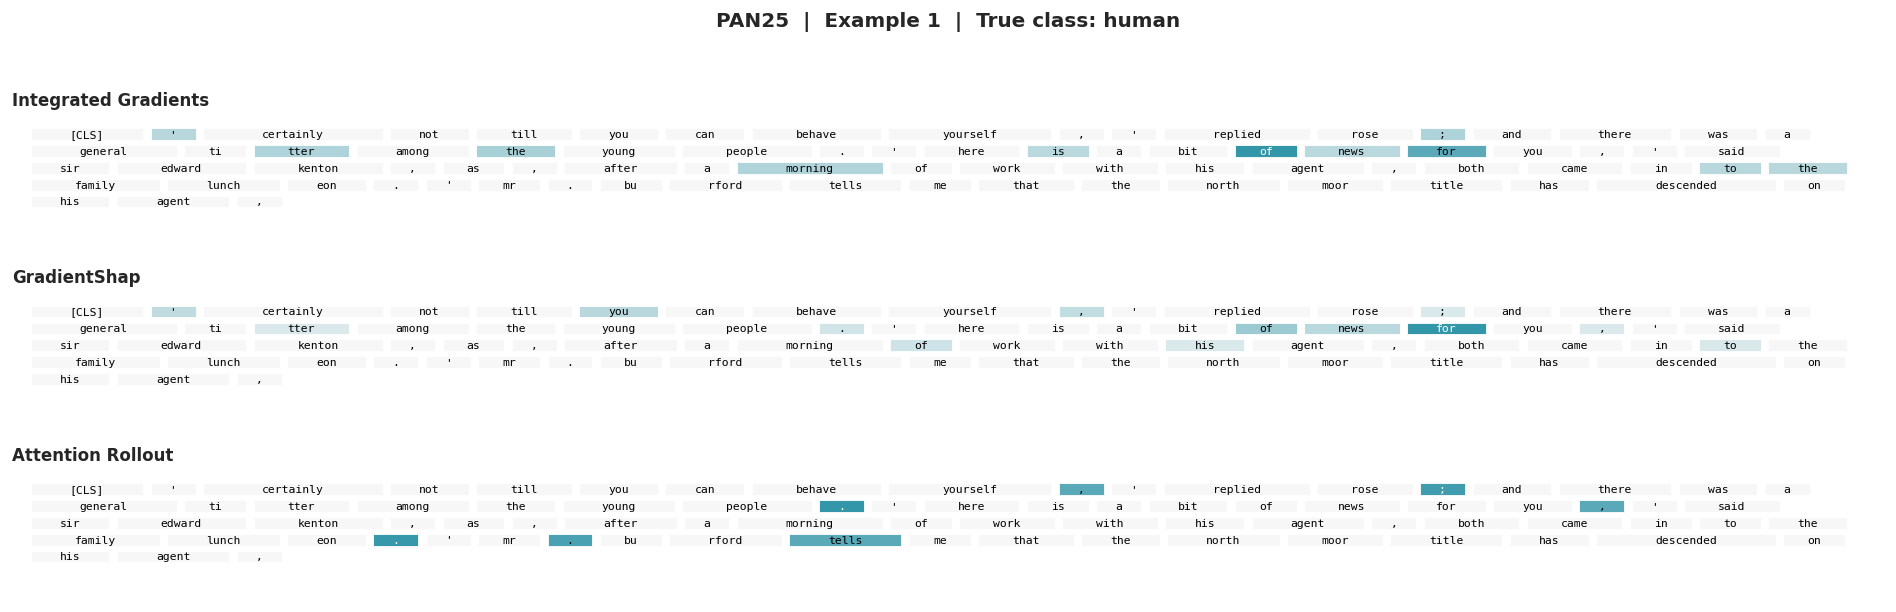

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_4_human_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_4_human_heatmap.pdf


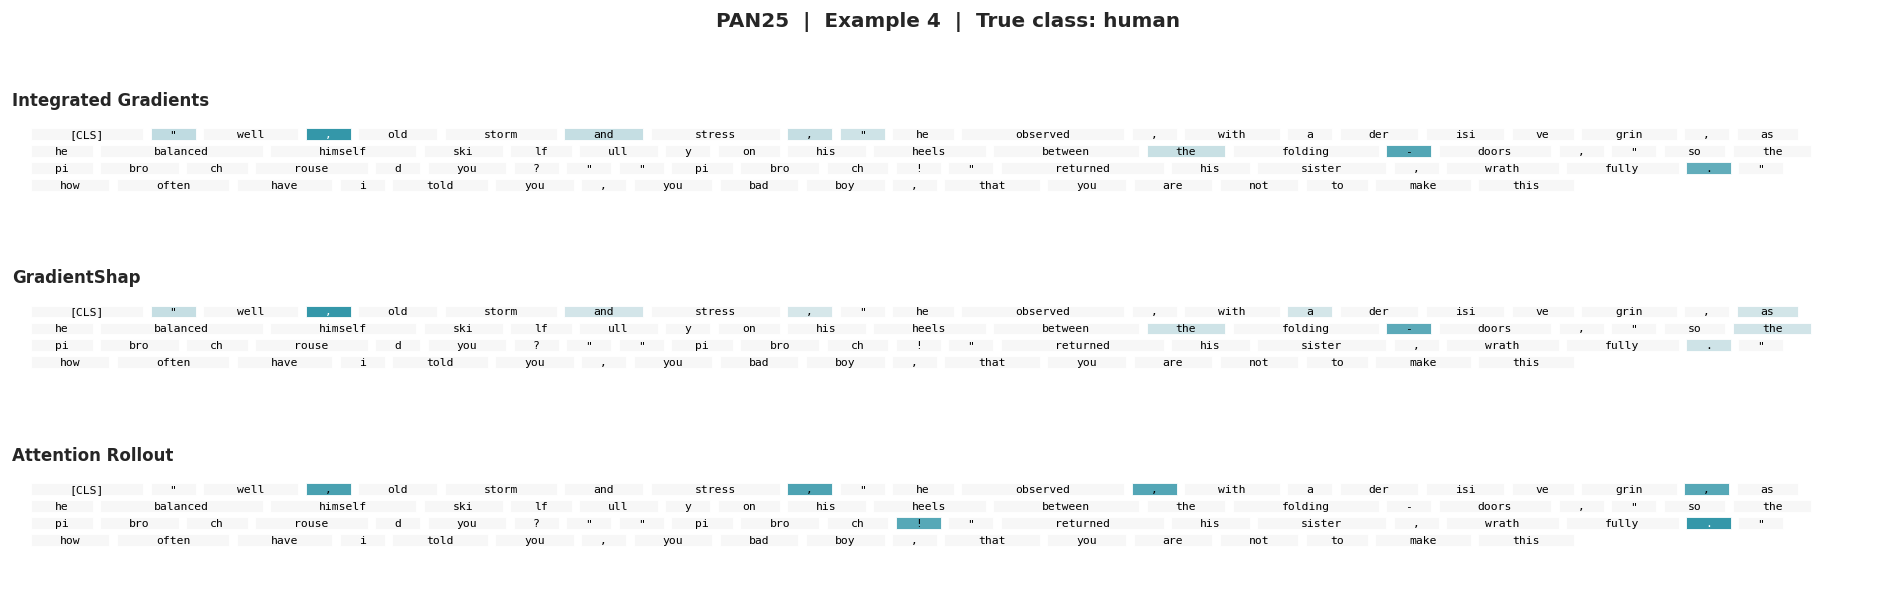

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_0_gpt-4o_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_0_gpt-4o_heatmap.pdf


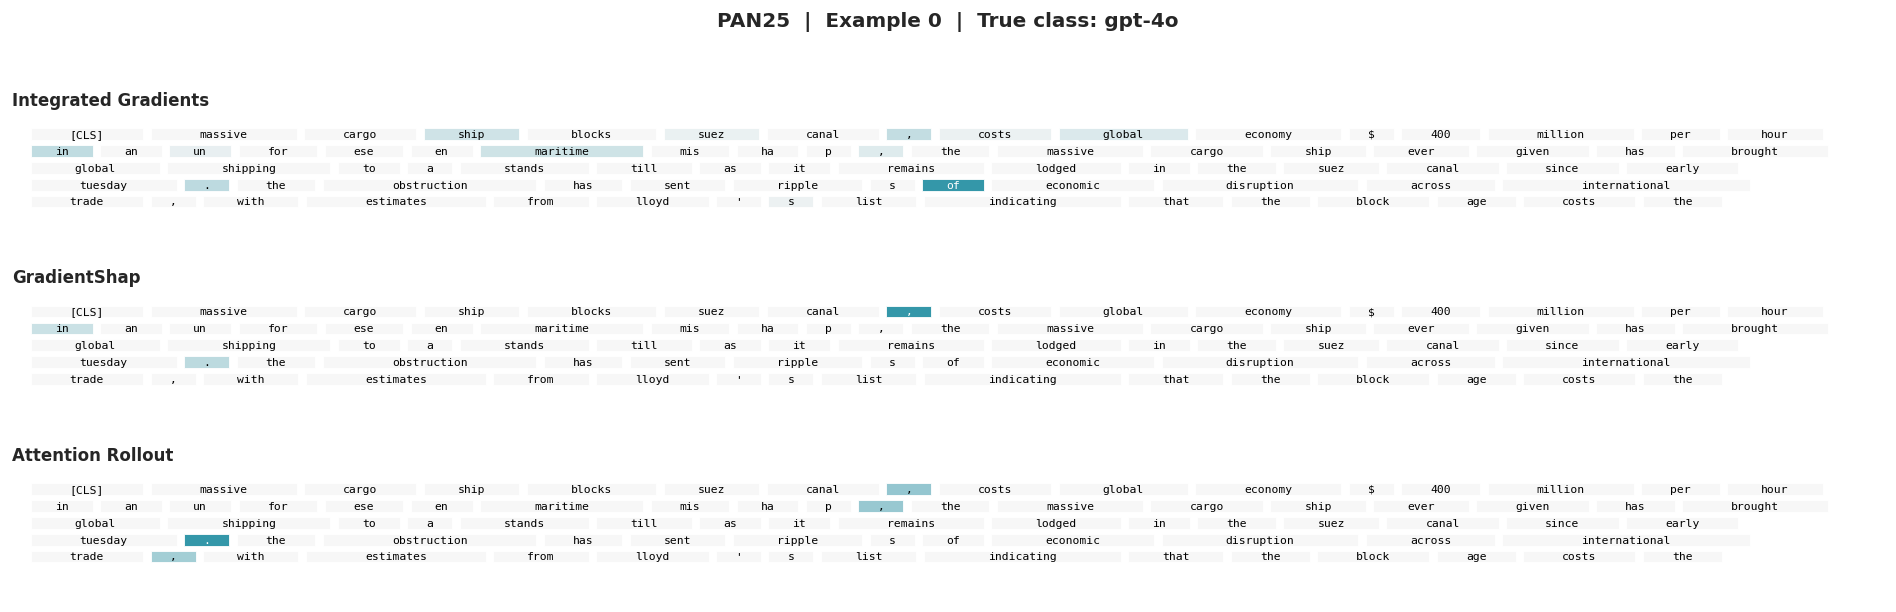

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_14_gpt-4o_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/pan25_example_14_gpt-4o_heatmap.pdf


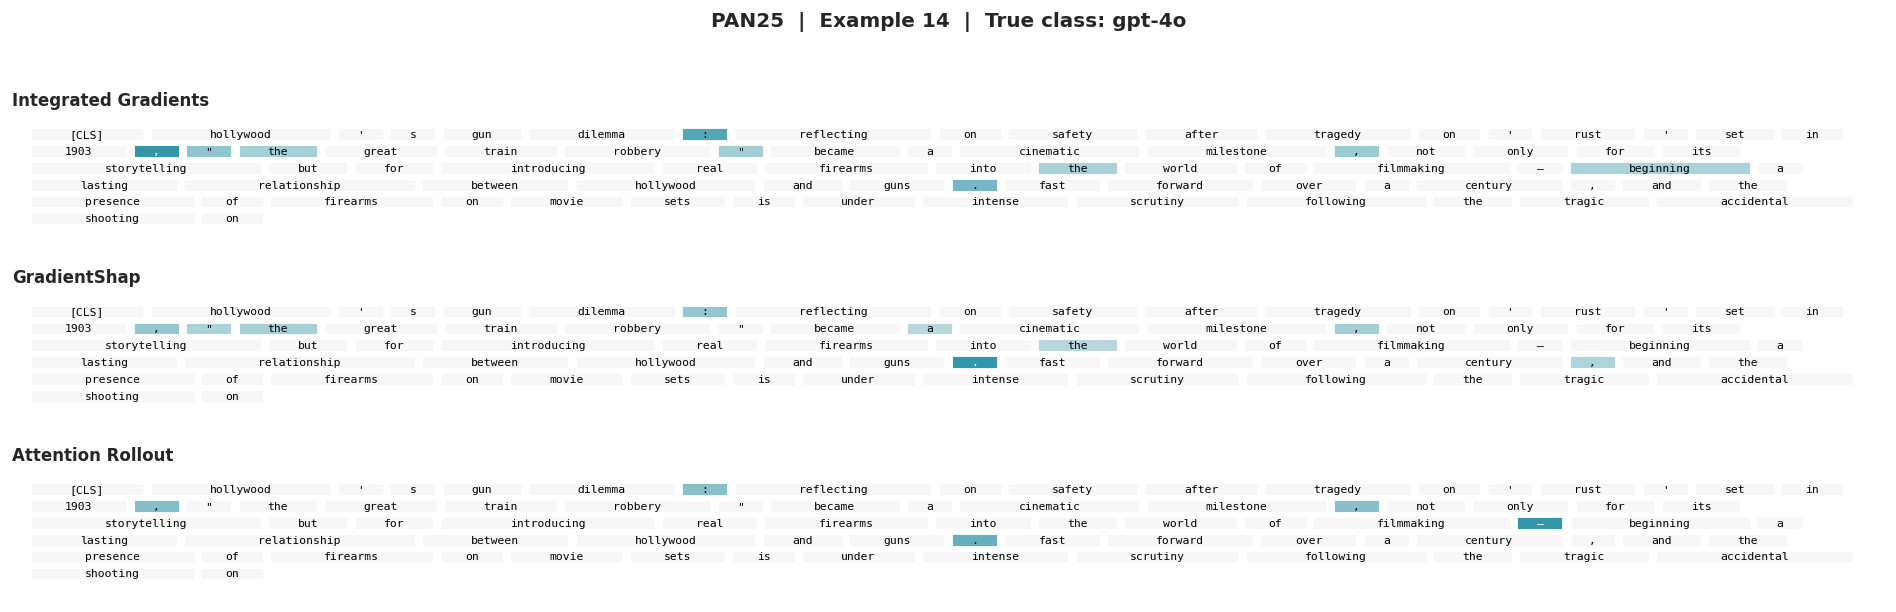

AuthorMix: bush vs blog30102
Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_273_bush_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_273_bush_heatmap.pdf


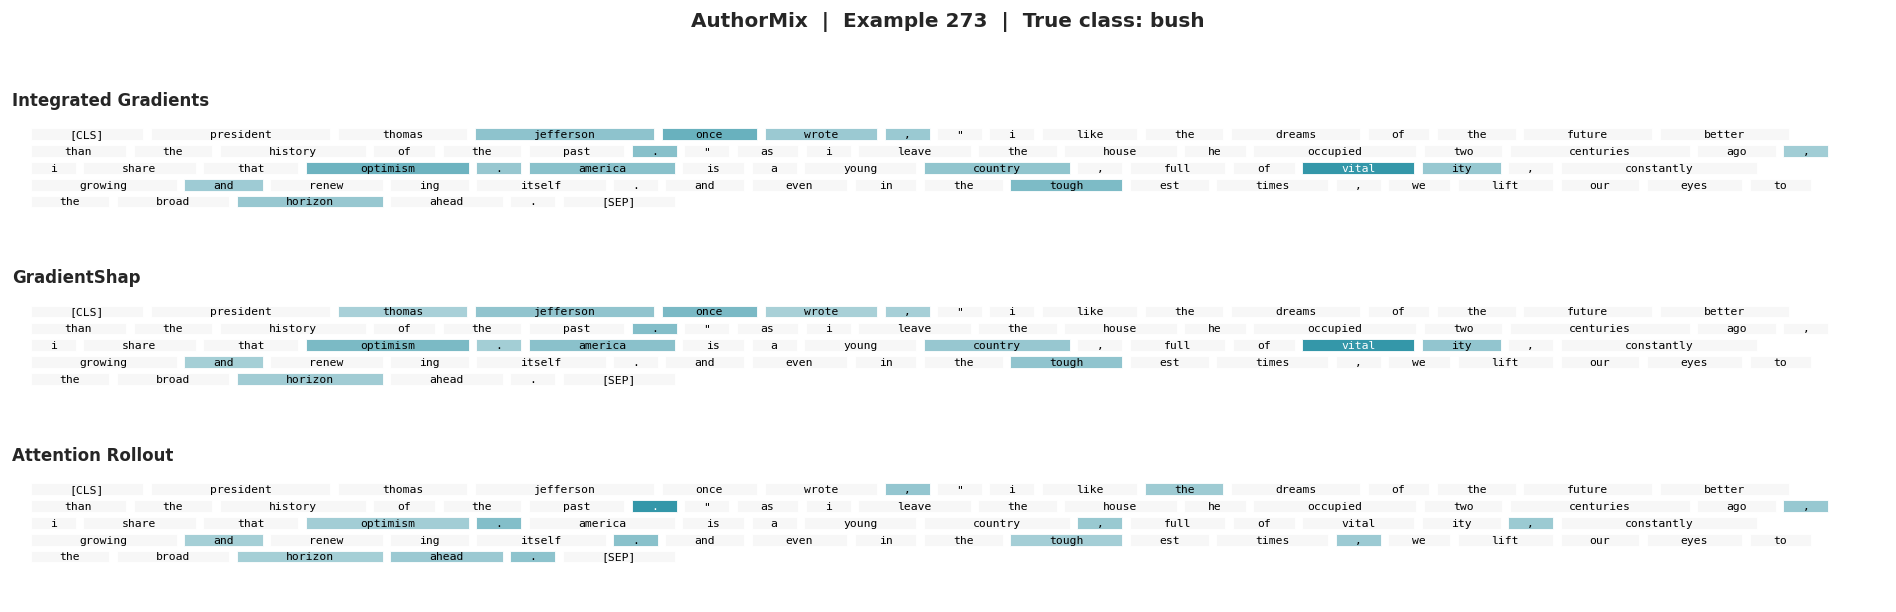

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_274_bush_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_274_bush_heatmap.pdf


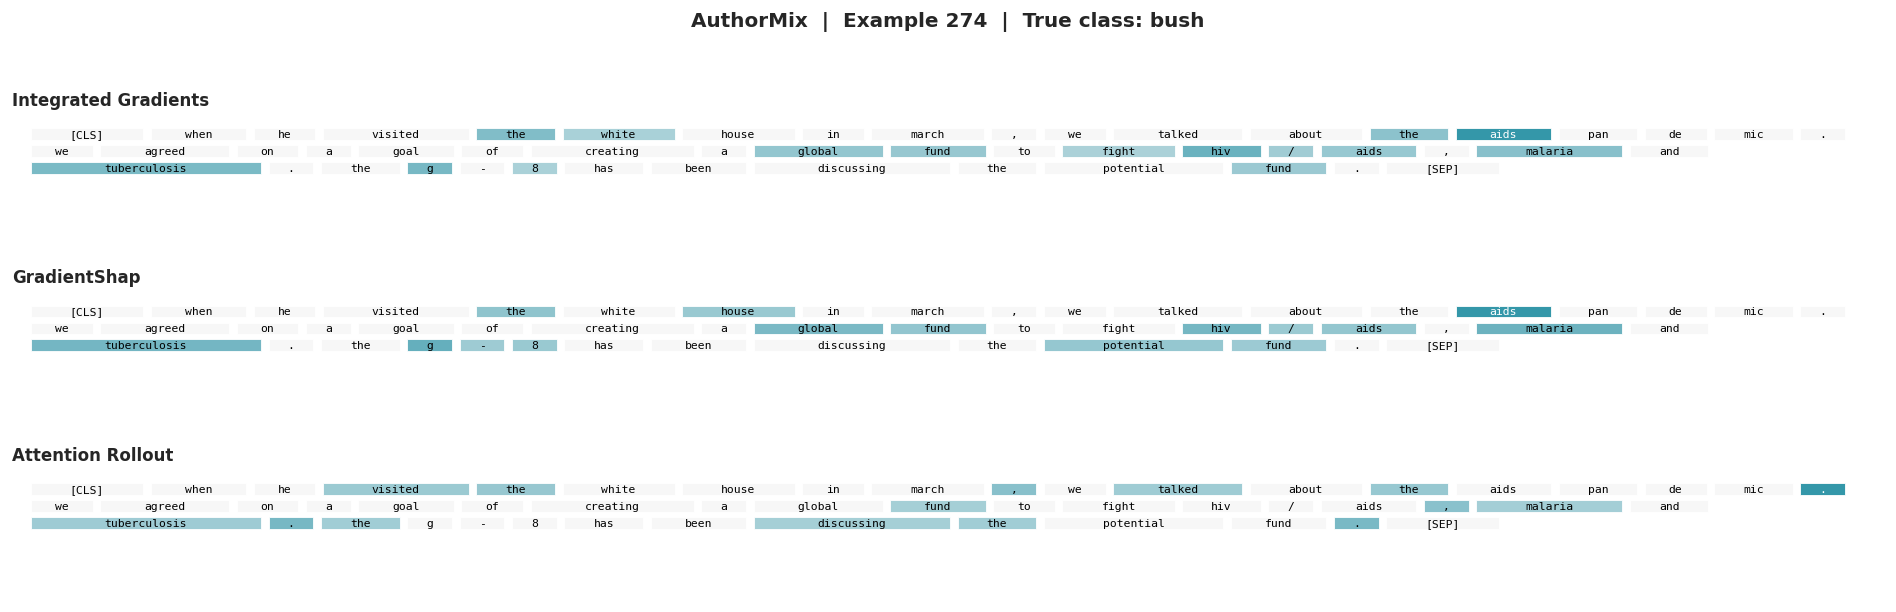

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_3347_blog30102_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_3347_blog30102_heatmap.pdf


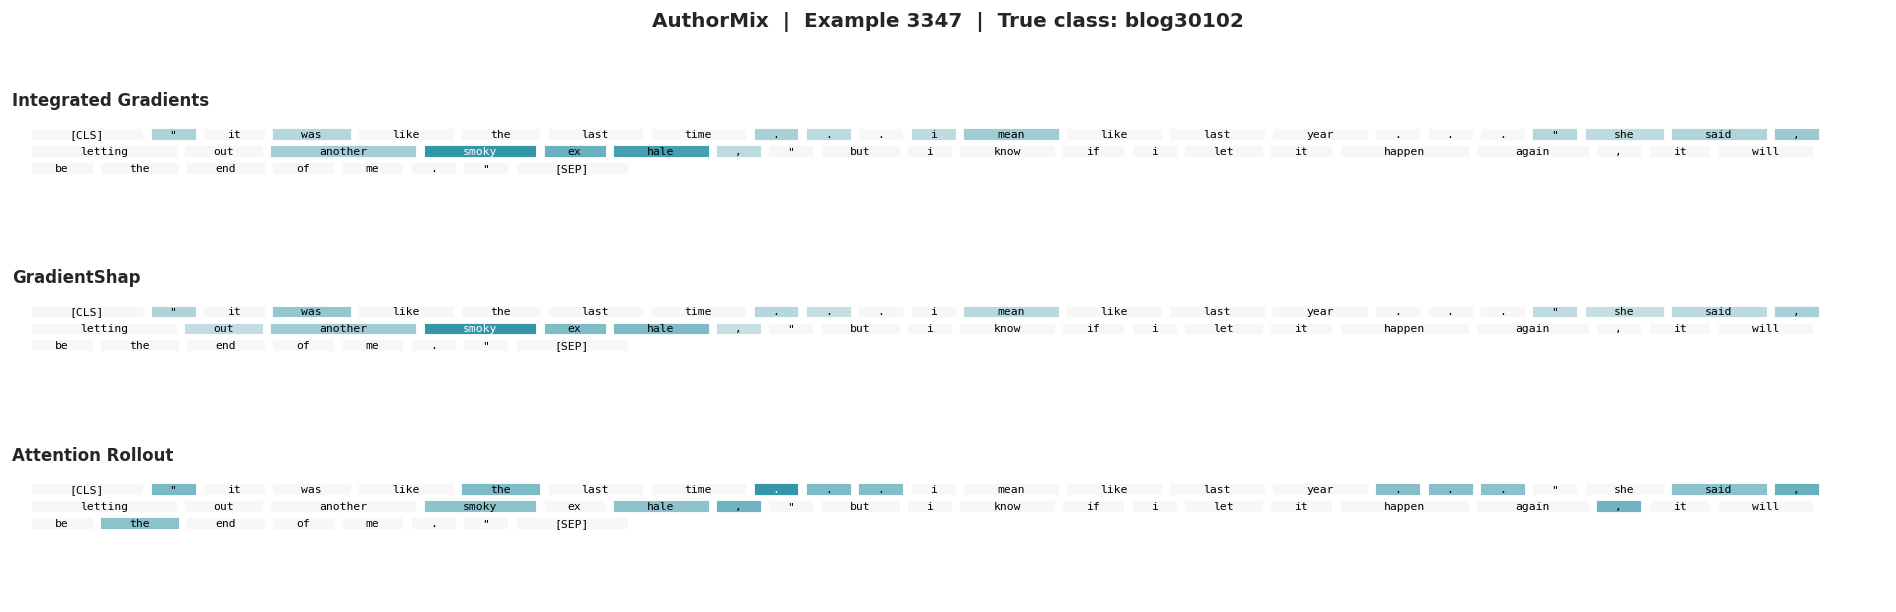

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_3348_blog30102_heatmap.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/example_heatmaps/authormix_example_3348_blog30102_heatmap.pdf


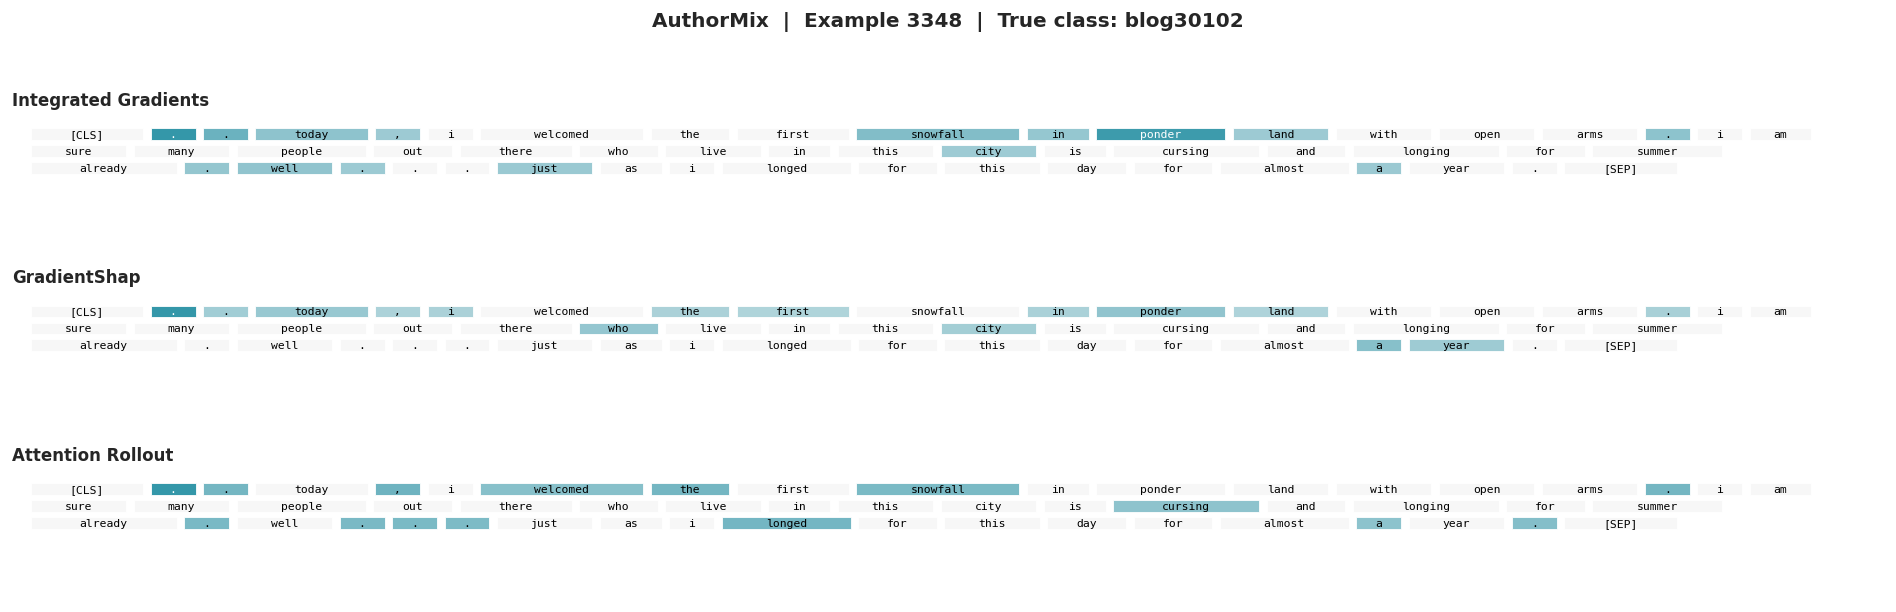

In [47]:
# heatmaps for a sample: examples from key class contrasts
def pick_examples_by_class(data, class_name, n=2):
    return [ex for ex in data if ex["class_name"] == class_name][:n]
HEATMAP_DIR = f"{RUNS_ROOT}/plots/example_heatmaps"
# PAN25: human vs gpt-4o
pan_sample = pick_examples_by_class(pan_data, "human", 2) + pick_examples_by_class(pan_data, "gpt-4o", 2)
print("PAN25: Human vs GPT-4o")
plot_example_heatmaps(pan_sample, "PAN25", save_dir=HEATMAP_DIR)

# AuthorMix: best vs worst class
am_classes = am_ratios.groupby("class")["ig_content_ratio"].mean().sort_values()
am_worst = am_classes.index[0]
am_best  = am_classes.index[-1]
am_sample = pick_examples_by_class(am_data, am_best, 2) + pick_examples_by_class(am_data, am_worst, 2)
print(f"AuthorMix: {am_best} vs {am_worst}")
plot_example_heatmaps(am_sample, "AuthorMix", save_dir=HEATMAP_DIR)


## 3. Part-of-speech analysis

Does the classifier rely on content words (nouns, verbs) vs function words (determiners, prepositions)?

In [8]:
POS_CATEGORIES = {
    "Noun":        {"NN", "NNS", "NNP", "NNPS"},
    "Verb":        {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"},
    "Adjective":   {"JJ", "JJR", "JJS"},
    "Adverb":      {"RB", "RBR", "RBS"},
    "Determiner":  {"DT", "PDT", "WDT"},
    "Preposition": {"IN"},
    "Conjunction":  {"CC"},
    "Pronoun":     {"PRP", "PRP$", "WP", "WP$"},
    "Punctuation": set(),
}


def classify_pos(token_str, pos_tag_str):
    """Map a POS tag to a human-readable category."""
    if re.fullmatch(r"\W+", token_str):
        return "Punctuation"
    for cat, tags in POS_CATEGORIES.items():
        if pos_tag_str in tags:
            return cat
    return "Other"


def pos_profile(data, method_key="top_ig"):
    """
    POS-tag the top-attributed tokens for each example.
    Returns DataFrame: [class, category, count, proportion, example_idx]
    """
    rows = []
    for ex in data:
        cls = ex["class_name"]
        top_toks = [t[0] for t in ex[method_key]]
        clean = [t.replace("##", "") for t in top_toks]
        tagged = pos_tag(clean)

        cats = [classify_pos(tok, tag) for tok, tag in tagged]
        total = len(cats)
        counts = Counter(cats)

        for cat, cnt in counts.items():
            rows.append({
                "class": cls,
                "category": cat,
                "count": cnt,
                "proportion": cnt / total,
                "example_idx": ex["example_idx"]
            })
    return pd.DataFrame(rows)


def plot_pos_comparison(data, dataset_name, figsize=None, save_dir=None):
    """
    POS distribution plots for all 3 methods.
    Same analysis as before. Added saving to PNG and PDF.
    """
    import textwrap
    import os

    methods = [
        ("top_ig", "Integrated Gradients"),
        ("top_gs", "GradientShap"),
        ("top_ar", "Attention Rollout"),
    ]

    class_order = sorted({ex["class_name"] for ex in data})
    n_classes = len(class_order)

    if figsize is None:
        figsize = (max(16, 0.75 * n_classes), 10)

    fig, axes = plt.subplots(
        3, 1,
        figsize=figsize,
        sharex=True,
        sharey=True,
        dpi=150
    )

    legend_handles = None
    legend_labels = None

    for ax, (method_key, method_label) in zip(axes, methods):
        df = pos_profile(data, method_key)

        pivot = (
            df.groupby(["class", "category"])["proportion"]
              .mean()
              .unstack(fill_value=0)
        )

        pivot = pivot.reindex(class_order)

        pos_colors = mako_palette(len(pivot.columns))

        pivot.plot(
            kind="bar",
            ax=ax,
            width=0.78,
            color=pos_colors,
            edgecolor="white",
            linewidth=0.4
        )

        ax.set_title(method_label, fontsize=12, fontweight="bold", pad=8)
        ax.set_ylabel("Mean Proportion", fontsize=10)
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="y", labelsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.get_legend().remove()

    wrapped_labels = [
        "\n".join(textwrap.wrap(str(label), width=18))
        for label in class_order
    ]

    axes[-1].set_xticks(range(len(class_order)))
    axes[-1].set_xticklabels(
        wrapped_labels,
        rotation=35,
        ha="right",
        fontsize=8
    )

    fig.suptitle(
        f"{dataset_name} — POS Distribution of Top-Attributed Tokens",
        fontsize=15,
        fontweight="bold",
        y=0.995
    )

    fig.legend(
        legend_handles,
        legend_labels,
        title="POS category",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=5,
        fontsize=8,
        title_fontsize=9,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        safe_name = dataset_name.lower().replace(" ", "_")
        png_path = os.path.join(save_dir, f"{safe_name}_pos_distribution.png")
        pdf_path = os.path.join(save_dir, f"{safe_name}_pos_distribution.pdf")

        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")

        print(f"Saved PNG: {png_path}")
        print(f"Saved PDF: {pdf_path}")

    plt.show()

def pos_summary_table(data, method_key, dataset_name):
    """Detailed POS breakdown table."""
    df = pos_profile(data, method_key)
    summary = df.groupby(["class", "category"])["proportion"].agg(["mean", "std"]).round(3)
    summary.columns = ["mean_prop", "std_prop"]
    summary = summary.reset_index()
    print(f"\n{dataset_name} — {method_key.replace('top_', '').upper()} POS Summary:")
    display(summary.pivot(index="category", columns="class", values="mean_prop").fillna(0).round(3))
    return summary

Plots will be saved to: /content/drive/MyDrive/ap-thesis/thesis plots
POS sample: 460 PAN25, 264 AuthorMix
Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_pos_distribution.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/pan25_pos_distribution.pdf


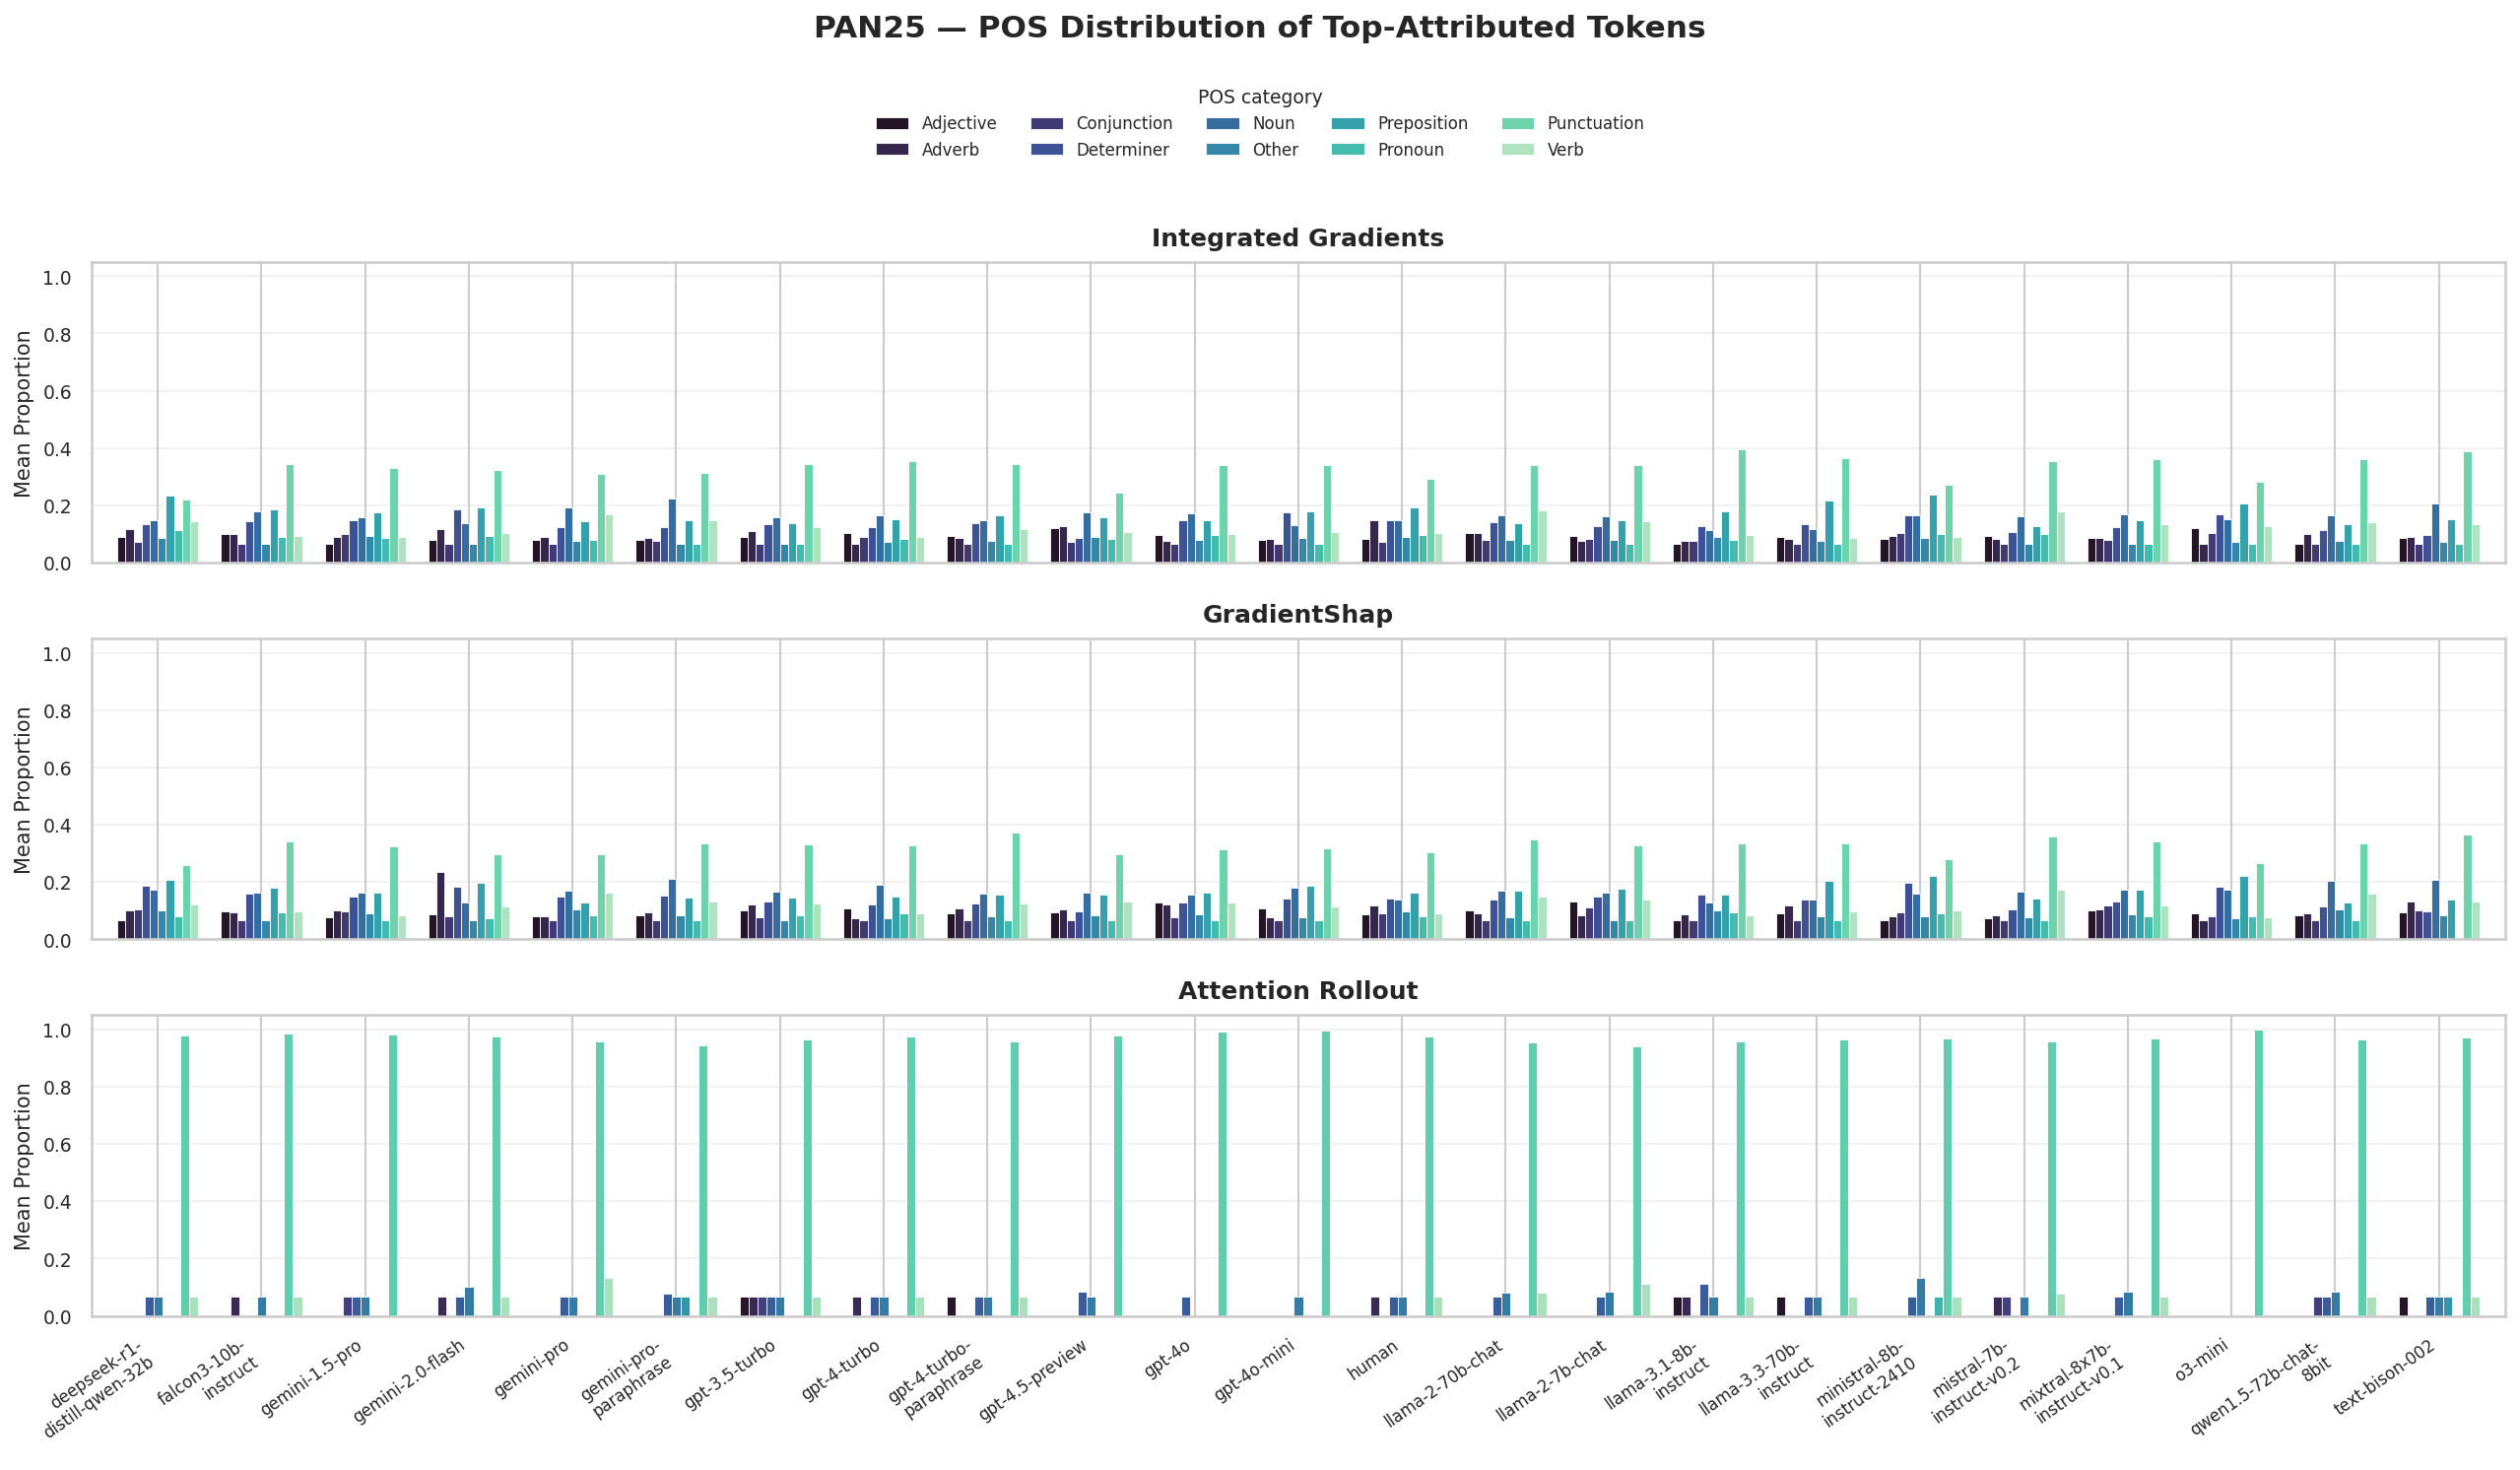

Saved PNG: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_pos_distribution.png
Saved PDF: /content/drive/MyDrive/ap-thesis/thesis plots/authormix_pos_distribution.pdf


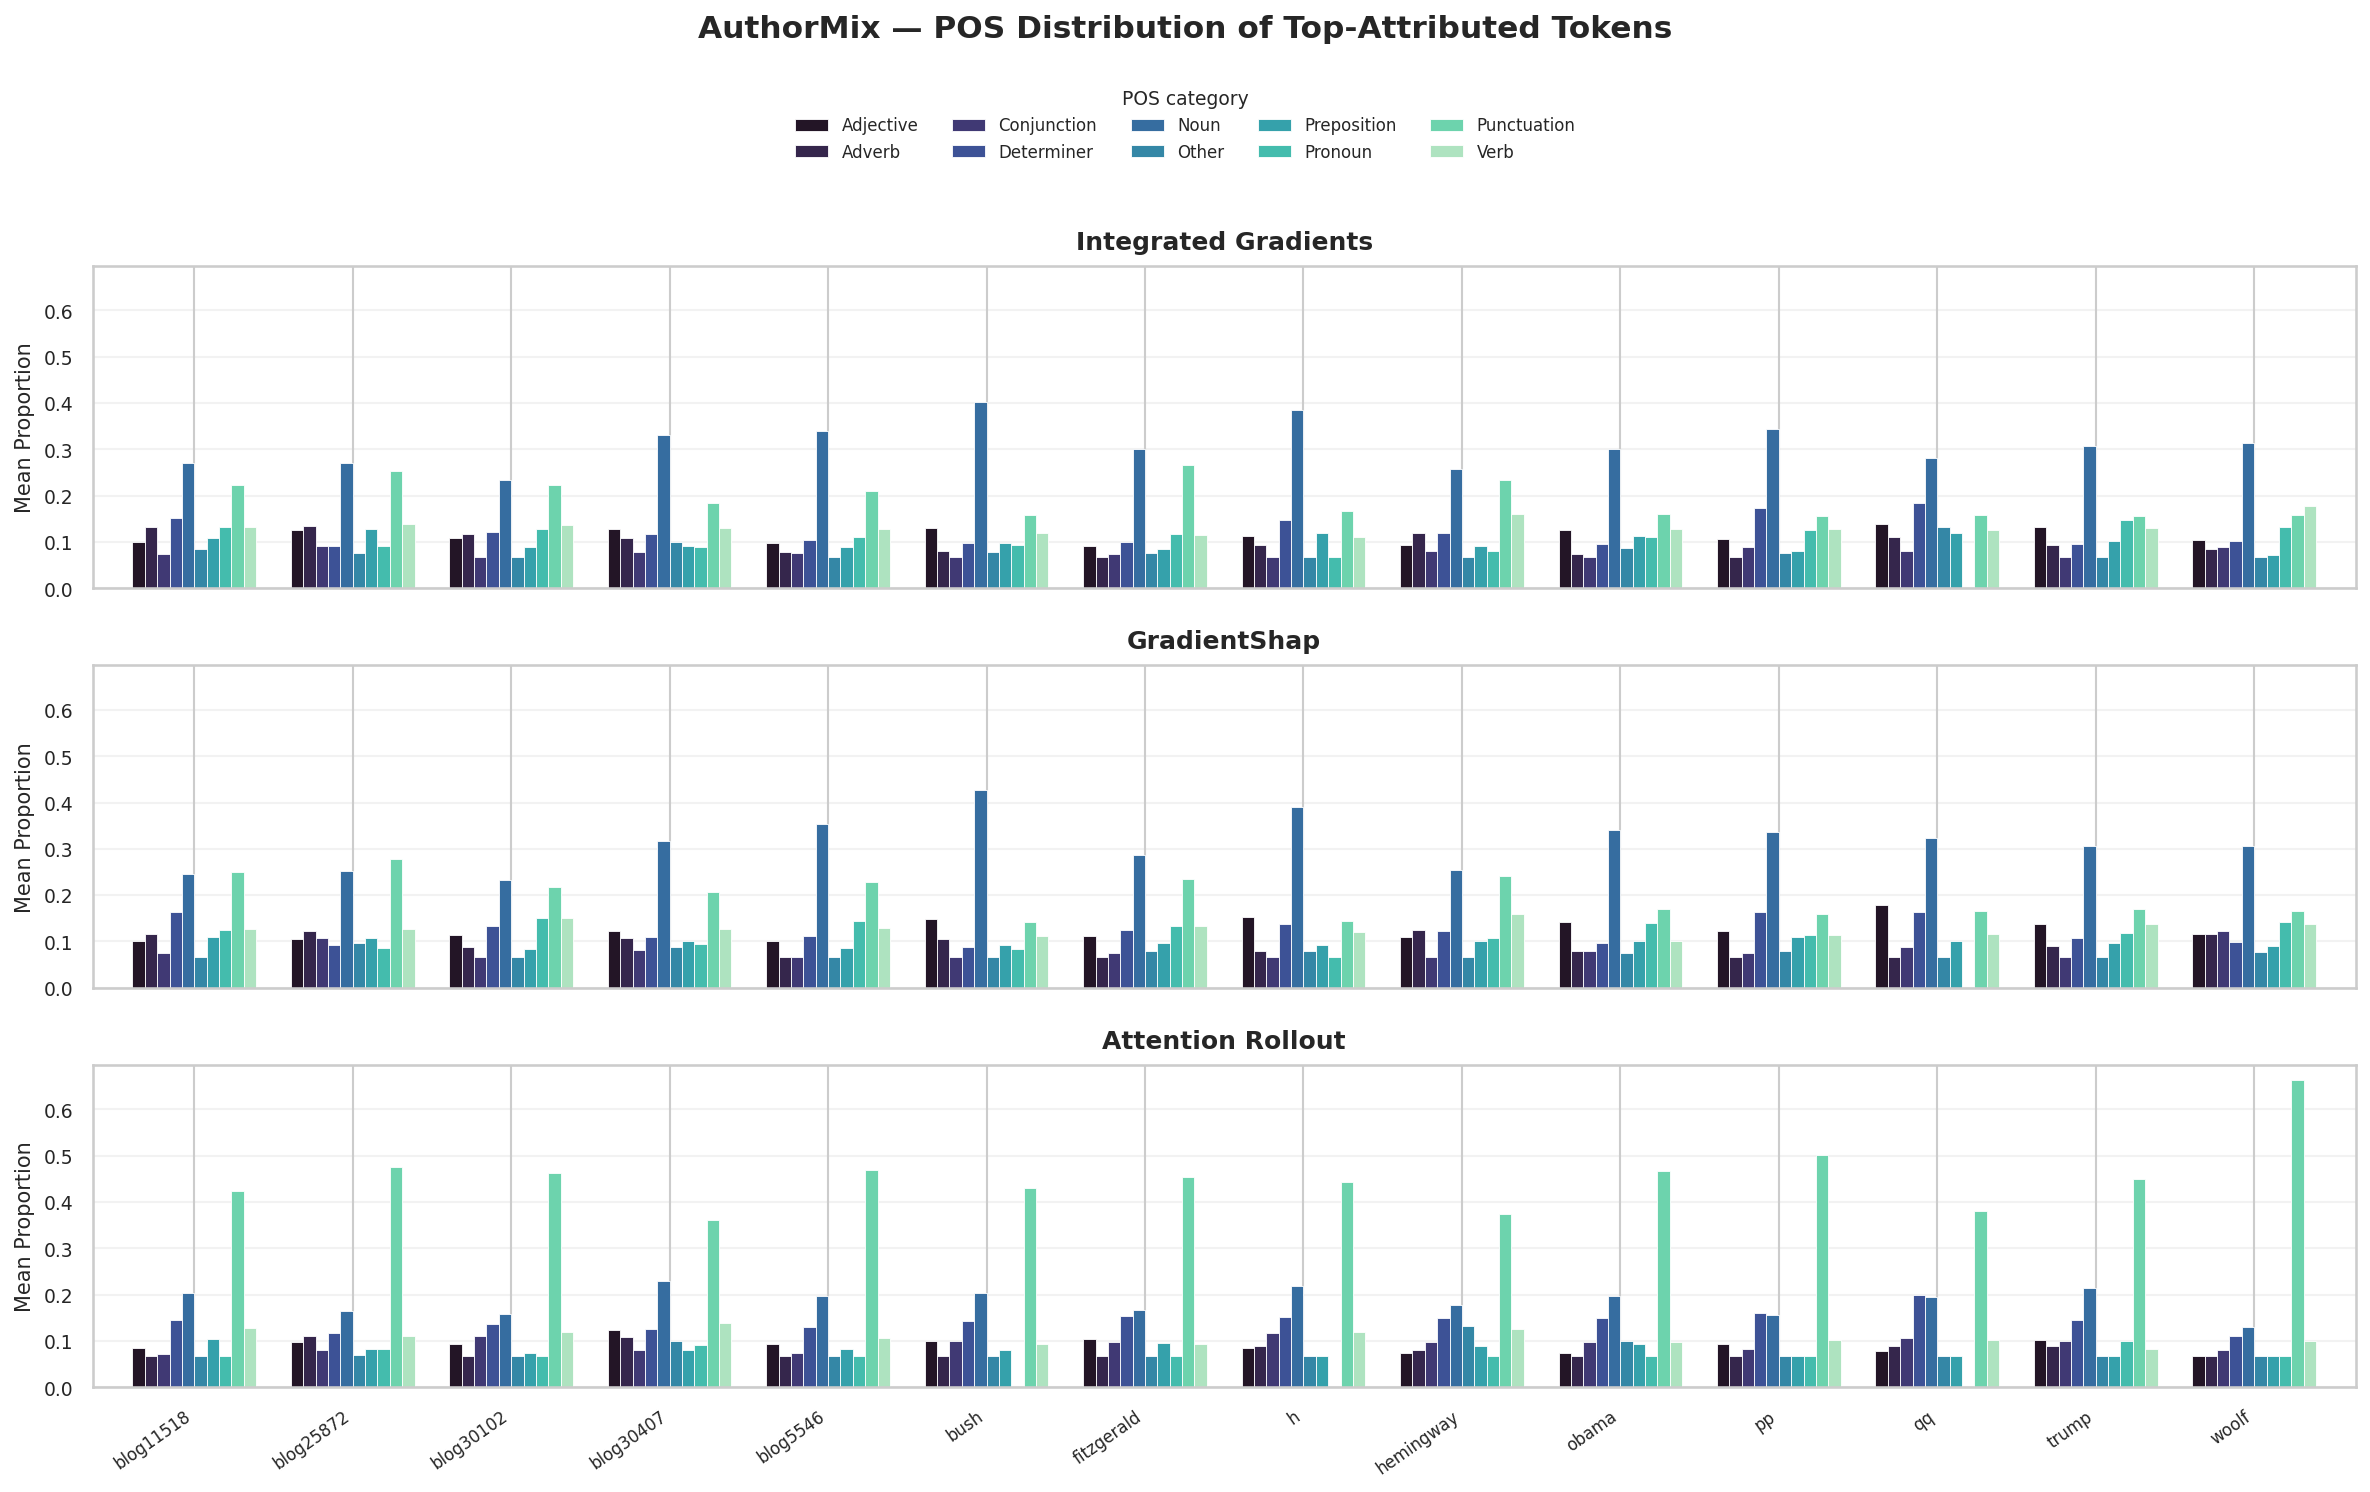


PAN25 — IG POS Summary:


class,deepseek-r1-distill-qwen-32b,falcon3-10b-instruct,gemini-1.5-pro,gemini-2.0-flash,gemini-pro,gemini-pro-paraphrase,gpt-3.5-turbo,gpt-4-turbo,gpt-4-turbo-paraphrase,gpt-4.5-preview,...,llama-2-70b-chat,llama-2-7b-chat,llama-3.1-8b-instruct,llama-3.3-70b-instruct,ministral-8b-instruct-2410,mistral-7b-instruct-v0.2,mixtral-8x7b-instruct-v0.1,o3-mini,qwen1.5-72b-chat-8bit,text-bison-002
category,,,,,,,,,,,,,,,,,,,,,
Adjective,0.089,0.100,0.067,0.080,0.078,0.080,0.091,0.103,0.092,0.120,...,0.105,0.092,0.067,0.089,0.081,0.094,0.087,0.120,0.067,0.087
Adverb,0.117,0.100,0.089,0.117,0.089,0.086,0.111,0.067,0.087,0.128,...,0.105,0.076,0.076,0.083,0.092,0.081,0.086,0.067,0.100,0.089
Conjunction,0.073,0.067,0.100,0.067,0.067,0.075,0.067,0.089,0.067,0.074,...,0.078,0.081,0.075,0.067,0.105,0.067,0.078,0.104,0.067,0.067
Determiner,0.133,0.145,0.149,0.186,0.123,0.125,0.133,0.125,0.137,0.088,...,0.141,0.126,0.126,0.133,0.165,0.105,0.125,0.168,0.114,0.098
Noun,0.147,0.180,0.159,0.137,0.193,0.222,0.157,0.165,0.147,0.176,...,0.165,0.163,0.115,0.118,0.165,0.163,0.168,0.150,0.167,0.207
Other,0.086,0.067,0.092,0.067,0.075,0.067,0.067,0.074,0.075,0.089,...,0.078,0.078,0.090,0.077,0.086,0.067,0.067,0.074,0.076,0.073
Preposition,0.233,0.187,0.177,0.193,0.143,0.148,0.137,0.153,0.167,0.160,...,0.137,0.148,0.179,0.217,0.239,0.126,0.147,0.207,0.133,0.152
Pronoun,0.113,0.089,0.086,0.092,0.078,0.067,0.067,0.083,0.067,0.083,...,0.067,0.067,0.078,0.067,0.100,0.100,0.067,0.067,0.067,0.067
Punctuation,0.220,0.343,0.330,0.323,0.310,0.313,0.343,0.353,0.343,0.243,...,0.340,0.340,0.397,0.363,0.273,0.353,0.360,0.283,0.360,0.390



AuthorMix — IG POS Summary:


class,blog11518,blog25872,blog30102,blog30407,blog5546,bush,fitzgerald,h,hemingway,obama,pp,qq,trump,woolf
category,,,,,,,,,,,,,,
Adjective,0.100,0.126,0.108,0.128,0.098,0.130,0.092,0.113,0.094,0.125,0.107,0.139,0.133,0.105
Adverb,0.133,0.134,0.117,0.109,0.078,0.080,0.067,0.093,0.120,0.073,0.067,0.111,0.093,0.086
Conjunction,0.074,0.092,0.067,0.079,0.076,0.067,0.075,0.067,0.080,0.067,0.089,0.080,0.067,0.089
Determiner,0.152,0.092,0.122,0.118,0.104,0.097,0.100,0.148,0.120,0.096,0.173,0.185,0.096,0.102
Noun,0.270,0.271,0.233,0.331,0.340,0.403,0.302,0.386,0.257,0.300,0.345,0.282,0.307,0.313
Other,0.086,0.076,0.067,0.100,0.067,0.078,0.076,0.067,0.067,0.087,0.076,0.133,0.067,0.067
Preposition,0.108,0.128,0.089,0.092,0.089,0.097,0.084,0.119,0.092,0.113,0.081,0.120,0.103,0.073
Pronoun,0.133,0.091,0.129,0.090,0.111,0.093,0.117,0.067,0.081,0.111,0.125,0.000,0.148,0.133
Punctuation,0.223,0.252,0.223,0.184,0.210,0.158,0.267,0.167,0.233,0.161,0.157,0.159,0.156,0.159



PAN25 — GS POS Summary:


...

class,blog11518,blog25872,blog30102,blog30407,blog5546,bush,fitzgerald,h,hemingway,obama,pp,qq,trump,woolf
category,,,,,,,,,,,,,,
Adjective,0.100,0.105,0.114,0.122,0.100,0.149,0.113,0.153,0.109,0.143,0.122,0.178,0.137,0.116
Adverb,0.117,0.123,0.089,0.108,0.067,0.105,0.067,0.080,0.124,0.080,0.067,0.067,0.091,0.117
Conjunction,0.076,0.107,0.067,0.082,0.067,0.067,0.076,0.067,0.067,0.080,0.076,0.089,0.067,0.122
Determiner,0.164,0.092,0.133,0.110,0.112,0.089,0.124,0.138,0.123,0.096,0.164,0.164,0.107,0.098
Noun,0.247,0.253,0.233,0.318,0.353,0.427,0.286,0.390,0.253,0.340,0.337,0.323,0.307,0.305
Other,0.067,0.097,0.067,0.089,0.067,0.067,0.080,0.080,0.067,0.074,0.080,0.067,0.067,0.078
Preposition,0.110,0.108,0.083,0.101,0.086,0.092,0.097,0.093,0.100,0.100,0.109,0.100,0.097,0.090
Pronoun,0.125,0.085,0.150,0.094,0.144,0.085,0.133,0.067,0.107,0.139,0.114,0.000,0.118,0.142
Punctuation,0.250,0.279,0.218,0.208,0.228,0.141,0.235,0.144,0.242,0.170,0.158,0.167,0.170,0.167



PAN25 — AR POS Summary:


class,deepseek-r1-distill-qwen-32b,falcon3-10b-instruct,gemini-1.5-pro,gemini-2.0-flash,gemini-pro,gemini-pro-paraphrase,gpt-3.5-turbo,gpt-4-turbo,gpt-4-turbo-paraphrase,gpt-4.5-preview,...,llama-2-70b-chat,llama-2-7b-chat,llama-3.1-8b-instruct,llama-3.3-70b-instruct,ministral-8b-instruct-2410,mistral-7b-instruct-v0.2,mixtral-8x7b-instruct-v0.1,o3-mini,qwen1.5-72b-chat-8bit,text-bison-002
category,,,,,,,,,,,,,,,,,,,,,
Adjective,0.000,0.000,0.000,0.000,0.000,0.000,0.067,0.000,0.067,0.000,...,0.000,0.000,0.067,0.067,0.000,0.000,0.000,0.0,0.000,0.067
Adverb,0.000,0.067,0.000,0.067,0.000,0.000,0.067,0.067,0.000,0.000,...,0.000,0.000,0.067,0.000,0.000,0.067,0.000,0.0,0.000,0.000
Conjunction,0.000,0.000,0.067,0.000,0.000,0.000,0.067,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.067,0.000,0.0,0.067,0.000
Determiner,0.067,0.000,0.067,0.067,0.067,0.078,0.067,0.067,0.067,0.083,...,0.067,0.067,0.111,0.067,0.067,0.000,0.067,0.0,0.067,0.067
Noun,0.067,0.067,0.067,0.100,0.067,0.067,0.067,0.067,0.067,0.067,...,0.080,0.083,0.067,0.067,0.133,0.067,0.083,0.0,0.083,0.067
Other,0.000,0.000,0.000,0.000,0.000,0.067,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.067
Preposition,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.067,0.000,0.000,0.0,0.000,0.000
Punctuation,0.980,0.987,0.983,0.977,0.957,0.943,0.963,0.973,0.957,0.980,...,0.953,0.940,0.957,0.963,0.967,0.957,0.967,1.0,0.963,0.970
Verb,0.067,0.067,0.000,0.067,0.133,0.067,0.067,0.067,0.067,0.000,...,0.080,0.111,0.067,0.067,0.067,0.078,0.067,0.0,0.067,0.067



AuthorMix — AR POS Summary:


class,blog11518,blog25872,blog30102,blog30407,blog5546,bush,fitzgerald,h,hemingway,obama,pp,qq,trump,woolf
category,,,,,,,,,,,,,,
Adjective,0.085,0.097,0.094,0.124,0.093,0.100,0.105,0.086,0.075,0.075,0.093,0.078,0.103,0.067
Adverb,0.067,0.111,0.067,0.108,0.067,0.067,0.067,0.089,0.080,0.067,0.067,0.089,0.089,0.067
Conjunction,0.072,0.082,0.111,0.081,0.074,0.100,0.097,0.117,0.097,0.097,0.083,0.107,0.100,0.080
Determiner,0.145,0.117,0.137,0.125,0.129,0.144,0.153,0.152,0.150,0.149,0.161,0.200,0.144,0.111
Noun,0.204,0.164,0.158,0.230,0.197,0.204,0.167,0.218,0.177,0.197,0.157,0.195,0.214,0.130
Other,0.067,0.069,0.067,0.100,0.067,0.067,0.067,0.067,0.133,0.100,0.067,0.067,0.067,0.067
Preposition,0.104,0.082,0.074,0.080,0.083,0.080,0.095,0.067,0.089,0.093,0.067,0.067,0.067,0.067
Pronoun,0.067,0.083,0.067,0.092,0.067,0.000,0.067,0.000,0.067,0.067,0.067,0.000,0.100,0.067
Punctuation,0.423,0.476,0.463,0.361,0.470,0.430,0.453,0.443,0.373,0.467,0.502,0.379,0.450,0.663


In [9]:
import os

PLOTS_DIR = "/content/drive/MyDrive/ap-thesis/thesis plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Plots will be saved to: {PLOTS_DIR}")

# NOTE: POS tagging on 7000+ examples is slow.
# We run on a stratified sample for POS analysis.
def stratified_sample(data, n_per_class=20, seed=42):
    """Sample n examples per class from the full attribution data."""
    rng = np.random.default_rng(seed)
    by_class = defaultdict(list)
    for ex in data:
        by_class[ex["class_name"]].append(ex)

    sampled = []
    for cls in sorted(by_class.keys()):
        exs = by_class[cls]
        n = min(n_per_class, len(exs))
        idxs = rng.choice(len(exs), size=n, replace=False)
        sampled.extend([exs[i] for i in idxs])
    return sampled

POS_SAMPLE_SIZE = 20  # per class

pan_pos_sample = stratified_sample(pan_data, n_per_class=POS_SAMPLE_SIZE)
am_pos_sample  = stratified_sample(am_data, n_per_class=POS_SAMPLE_SIZE)

print(f"POS sample: {len(pan_pos_sample)} PAN25, {len(am_pos_sample)} AuthorMix")

plot_pos_comparison(pan_pos_sample, "PAN25", save_dir=PLOTS_DIR)
plot_pos_comparison(am_pos_sample, "AuthorMix", save_dir=PLOTS_DIR)

for mk in ["top_ig", "top_gs", "top_ar"]:
    pos_summary_table(pan_pos_sample, mk, "PAN25")
    pos_summary_table(am_pos_sample, mk, "AuthorMix")

## 4. Lexical sophistication and word rarity

Are the classifier's important tokens common everyday words or rare/sophisticated ones?
Measures: mean word length, subword ratio, stopword ratio, type-token ratio.

In [10]:
def lexical_metrics(data, method_key="top_ig"):
    """
    Compute lexical sophistication metrics for top-attributed tokens.
    """
    rows = []
    for ex in data:
        cls = ex["class_name"]
        top_toks = [t[0] for t in ex[method_key]]

        content_toks = [t for t in top_toks if not re.fullmatch(r"\W+", t)
                        and t not in ("[CLS]", "[SEP]", "[PAD]")]
        if not content_toks:
            continue

        clean = [t.replace("##", "") for t in content_toks]
        lengths = [len(w) for w in clean]

        subword_count = sum(1 for t in content_toks if t.startswith("##"))
        ttr = len(set(t.lower() for t in clean)) / len(clean) if clean else 0
        stop_ratio = sum(1 for t in clean if t.lower() in STOP_WORDS) / len(clean)

        rows.append({
            "class": cls,
            "mean_word_length": np.mean(lengths),
            "max_word_length": np.max(lengths),
            "subword_ratio": subword_count / len(content_toks),
            "type_token_ratio": ttr,
            "stopword_ratio": stop_ratio,
            "example_idx": ex["example_idx"]
        })
    return pd.DataFrame(rows)


def plot_lexical_comparison(data, dataset_name):
    """
    Plot lexical sophistication metrics for attributed tokens.
    Design-only change: one shared legend outside the subplots.
    """
    metrics = ["mean_word_length", "subword_ratio", "stopword_ratio", "type_token_ratio"]
    labels = ["Mean Word Length", "Subword Ratio", "Stopword Ratio", "Type-Token Ratio"]

    fig, axes = plt.subplots(2, 2, figsize=(18, 11), dpi=150)
    axes = axes.ravel()

    legend_handles = None
    legend_labels = None

    for ax, metric, label in zip(axes, metrics, labels):
        combined_rows = []

        for method_key, method_label in [
            ("top_ig", "IG"),
            ("top_gs", "SHAP"),
            ("top_ar", "AR")
        ]:
            df = lexical_metrics(data, method_key)
            df["method"] = method_label
            combined_rows.append(df)

        combined = pd.concat(combined_rows, ignore_index=True)

        sns.barplot(
            data=combined,
            x="method",
            y=metric,
            hue="class",
            ax=ax,
            palette="mako",
            edgecolor="white"
        )

        ax.set_title(label, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(metric, fontsize=10)
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", labelsize=11)
        ax.tick_params(axis="y", labelsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.suptitle(
        f"{dataset_name} — Lexical Sophistication of Attributed Tokens",
        fontsize=15,
        fontweight="bold",
        y=0.98
    )
    fig.legend(
        legend_handles,
        legend_labels,
        title="Class",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4,
        fontsize=8,
        title_fontsize=9,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.18, 1, 0.94])
    plt.show()

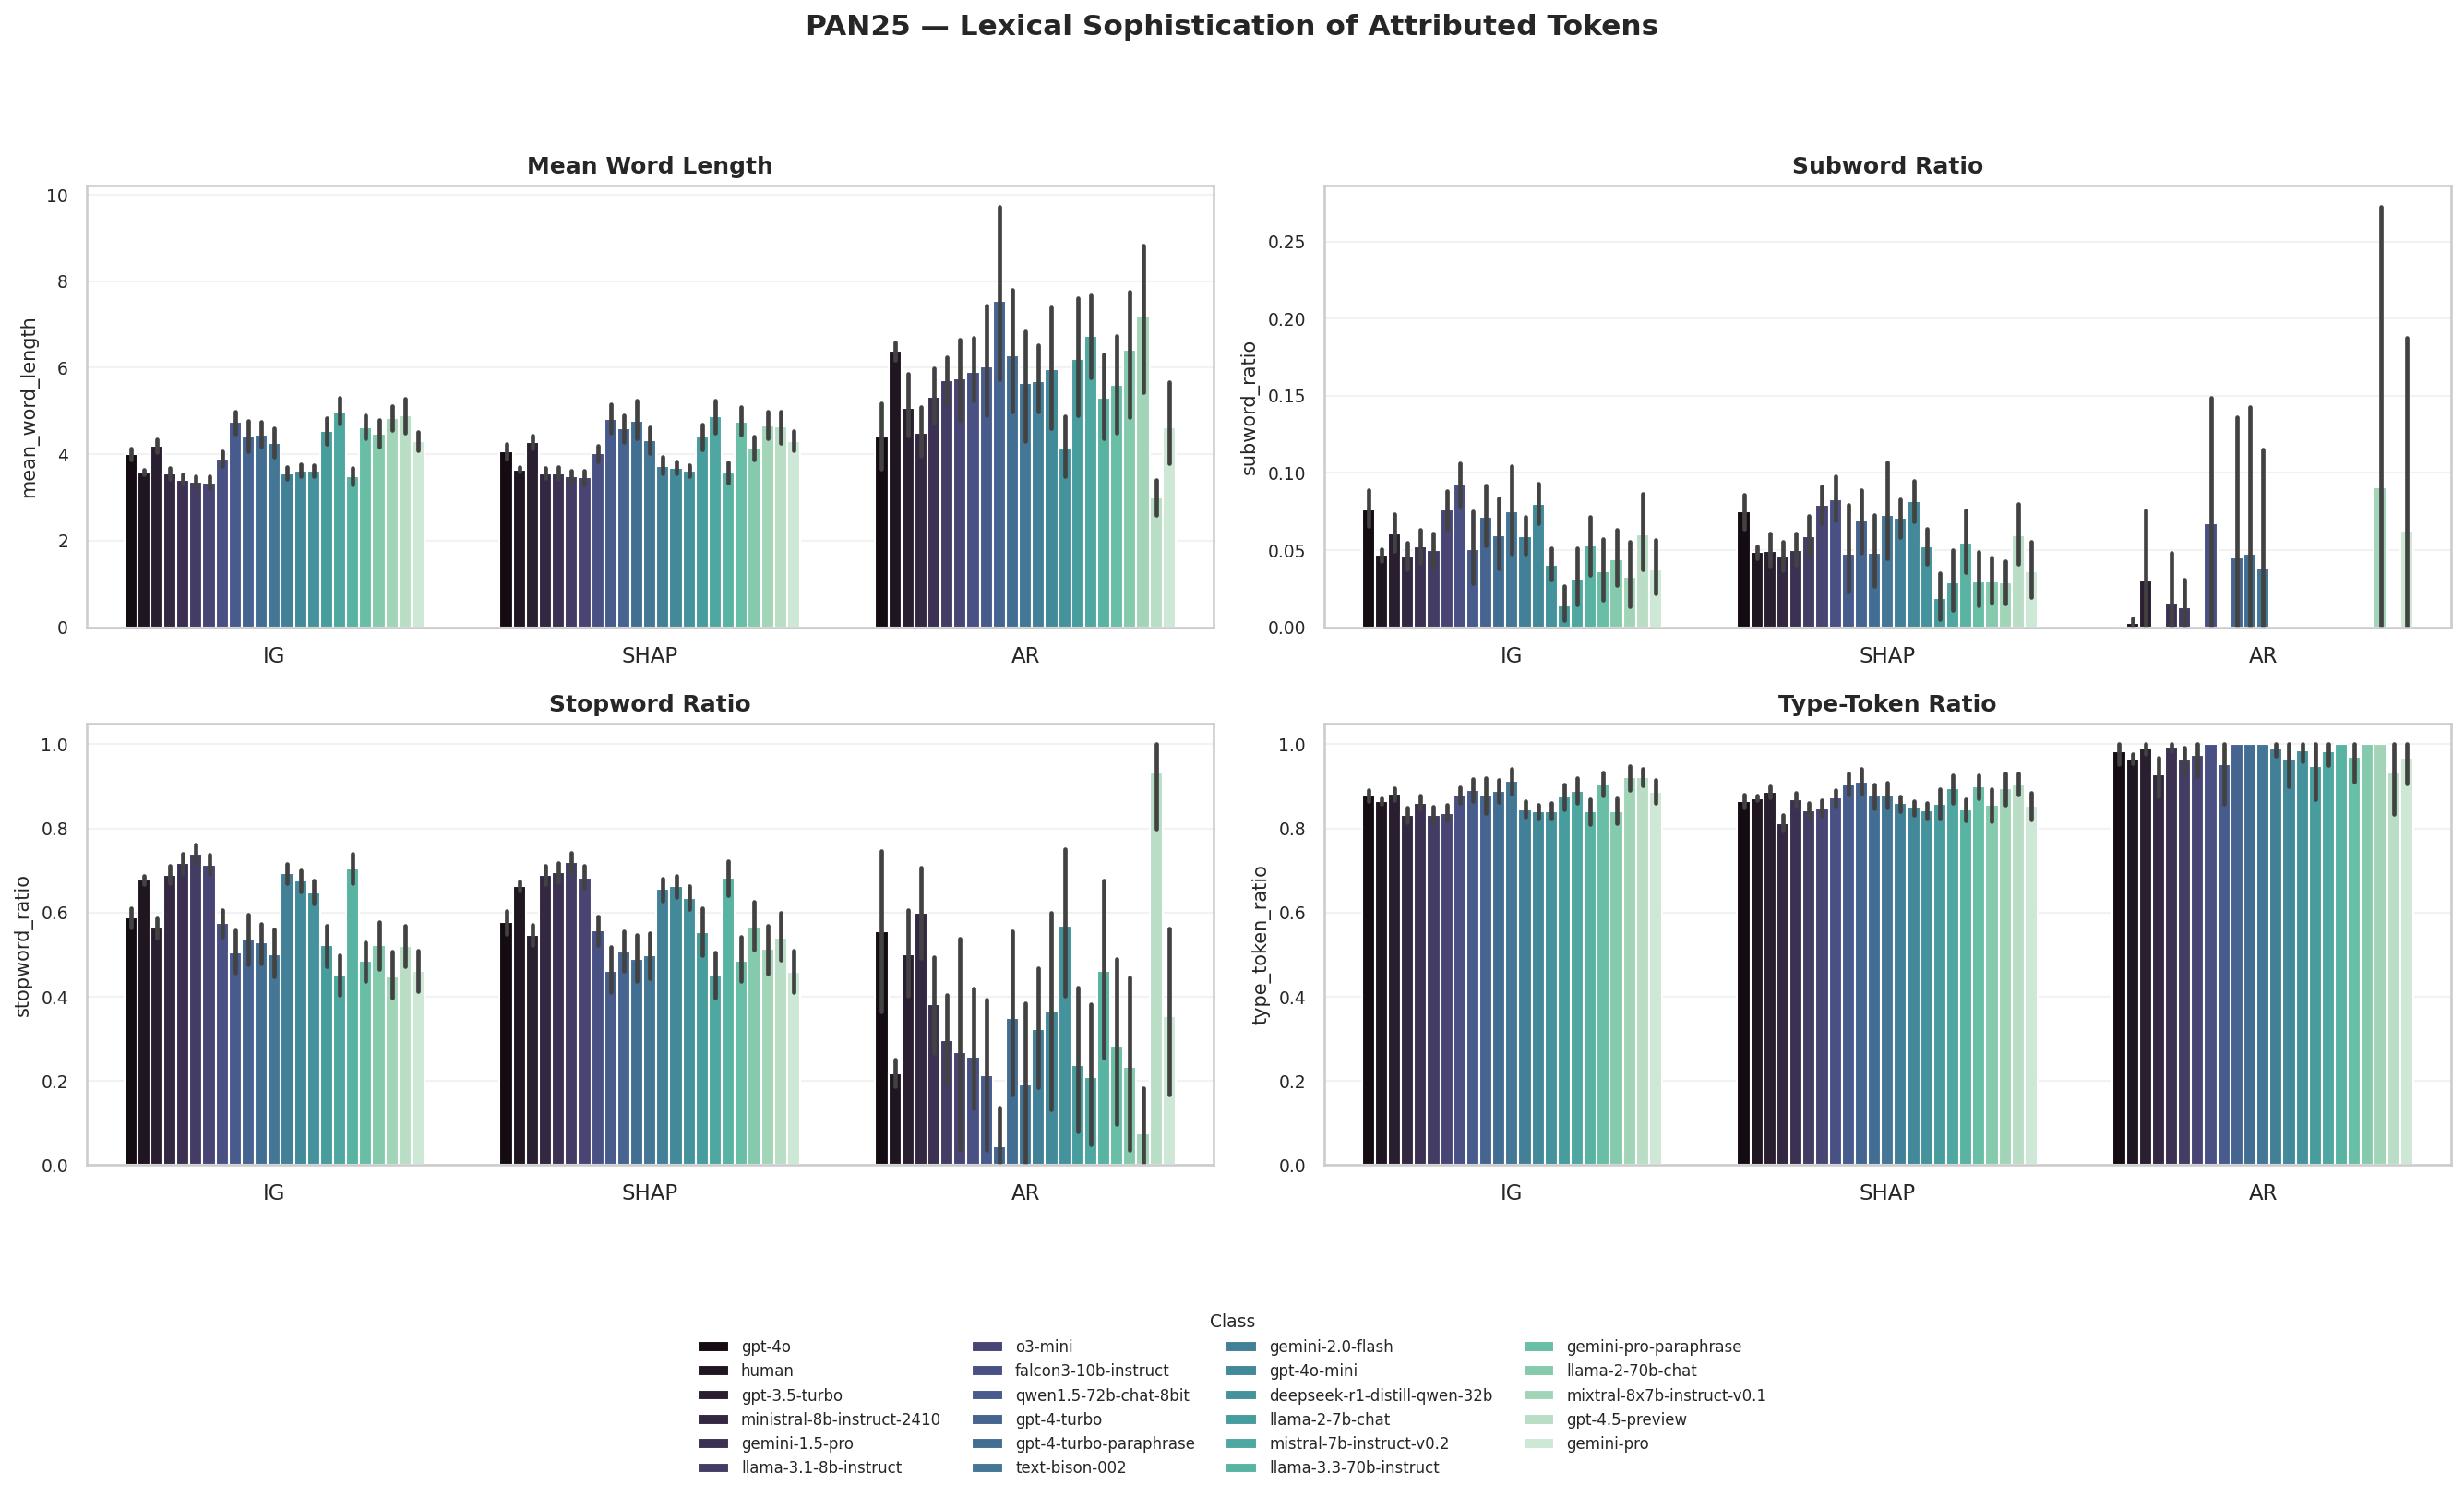

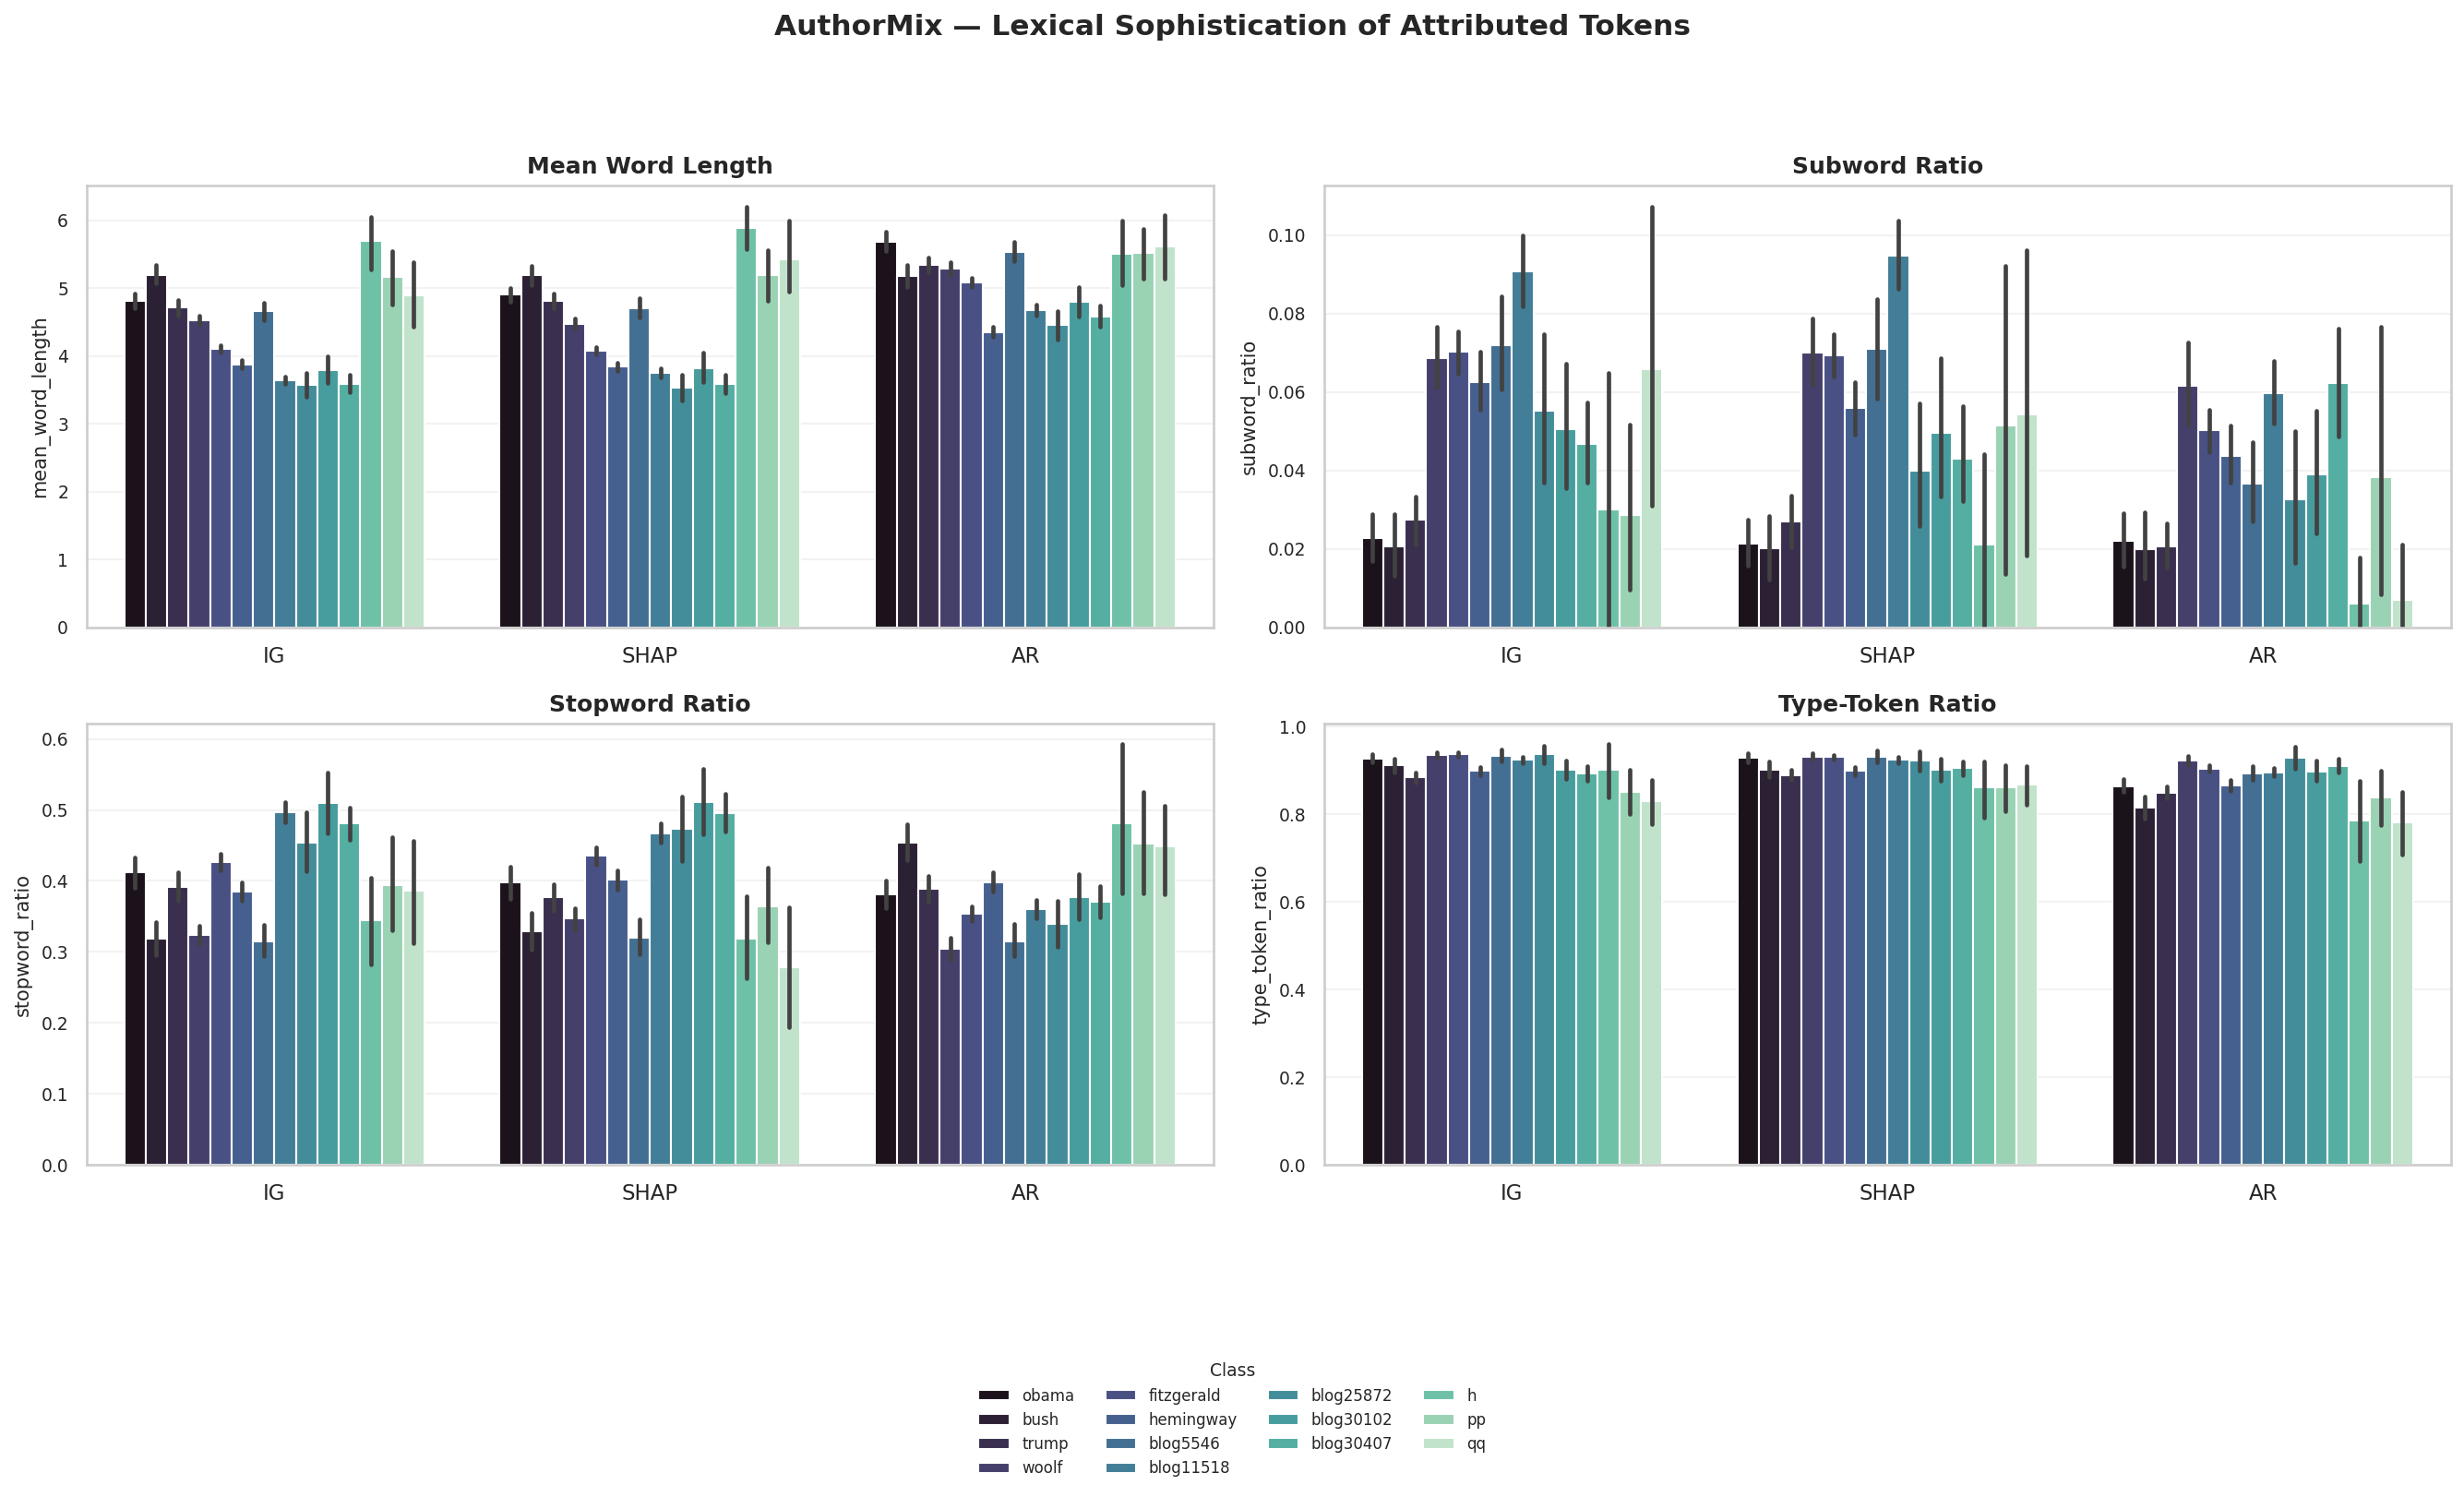

In [11]:
plot_lexical_comparison(pan_data, "PAN25")
plot_lexical_comparison(am_data, "AuthorMix")

## 5. Attribution concentration (entropy and Gini)

Does the classifier rely on a single token or spread attention across many?

In [12]:
def attribution_concentration(data, method_key="top_ig"):
    """
    Compute concentration metrics: entropy, Gini, top-1/top-3 dominance.
    """
    rows = []
    for ex in data:
        cls = ex["class_name"]
        scores = np.array([abs(float(t[1])) for t in ex[method_key]])

        if scores.sum() == 0:
            continue

        probs = scores / scores.sum()

        entropy = -np.sum(probs * np.log2(probs + 1e-12))
        max_entropy = np.log2(len(probs))

        n = len(probs)
        sorted_p = np.sort(probs)
        index = np.arange(1, n + 1)
        gini = (2 * np.sum(index * sorted_p) - (n + 1) * np.sum(sorted_p)) / (n * np.sum(sorted_p) + 1e-12)

        top1_share = probs.max()
        top3_share = np.sort(probs)[-3:].sum() if len(probs) >= 3 else probs.sum()

        rows.append({
            "class": cls,
            "entropy": entropy,
            "normalised_entropy": entropy / max_entropy if max_entropy > 0 else 0,
            "gini": gini,
            "top1_dominance": top1_share,
            "top3_dominance": top3_share,
            "example_idx": ex["example_idx"]
        })
    return pd.DataFrame(rows)


def plot_concentration(data, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, (method_key, method_label) in zip(axes, [
        ("top_ig", "Integrated Gradients"),
        ("top_gs", "GradientShap"),
        ("top_ar", "Attention Rollout"),
    ]):
        df = attribution_concentration(data, method_key)
        classes = sorted(df["class"].unique())
        x = np.arange(3)
        width = 0.8 / len(classes)

        colors = dict(zip(classes, mako_palette(len(classes))))

        for i, cls in enumerate(classes):
            subset = df[df["class"] == cls]
            vals = [
                subset["normalised_entropy"].mean(),
                subset["gini"].mean(),
                subset["top3_dominance"].mean()
            ]
            errs = [
                subset["normalised_entropy"].std(),
                subset["gini"].std(),
                subset["top3_dominance"].std()
            ]
            ax.bar(x + i * width, vals, width, yerr=errs, label=cls,
                   color=colors[cls], capsize=2, edgecolor="white")

        ax.set_xticks(x + width * len(classes) / 2)
        ax.set_xticklabels(["Norm. Entropy", "Gini", "Top-3 Share"], fontsize=8)
        ax.set_title(method_label, fontsize=11)
        ax.legend(fontsize=6, ncol=2)
        ax.set_ylim(0, 1.1)

    fig.suptitle(f"{dataset_name} — Attribution Concentration",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

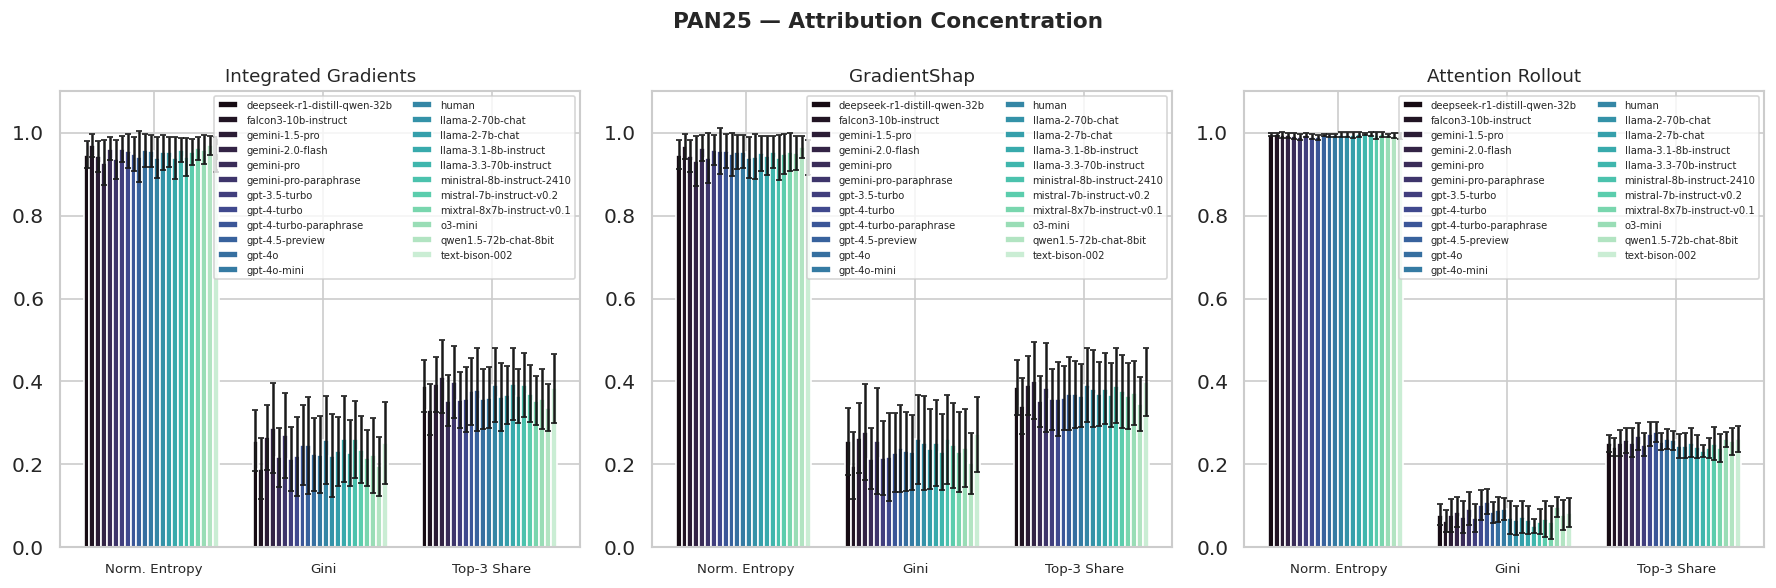

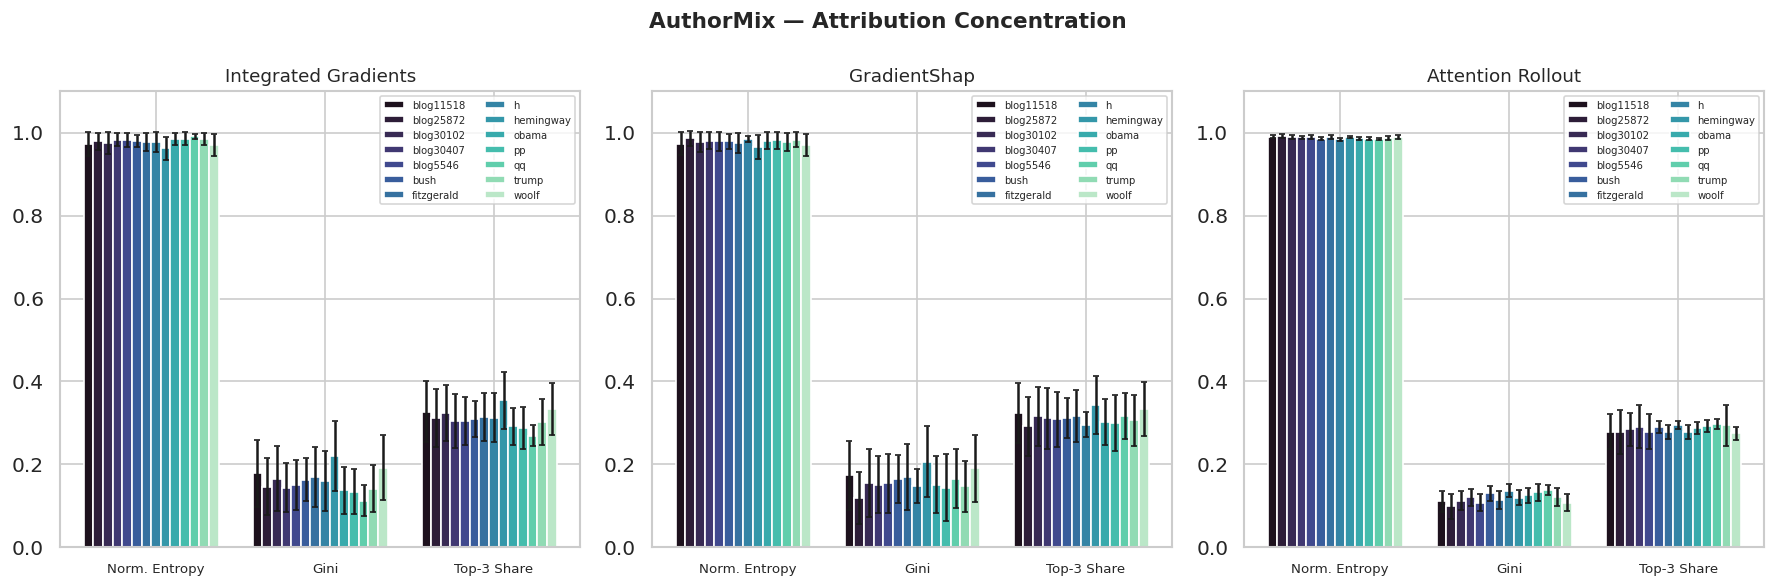

In [13]:
plot_concentration(pan_data, "PAN25")
plot_concentration(am_data, "AuthorMix")

## 6. Cross-method agreement

If IG, SHAP, and AR agree on the same tokens, this indicates high confidence that those tokens
are genuinely important for classification.

In [14]:
def pairwise_agreement(data):
    """
    Compute Jaccard overlap between all pairs of attribution methods,
    broken down by class.
    """
    methods = [("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")]
    rows = []

    for ex in data:
        cls = ex["class_name"]
        token_sets = {}
        for key, label in methods:
            token_sets[label] = set(t[0] for t in ex[key])

        for (l1, s1), (l2, s2) in combinations(token_sets.items(), 2):
            union = s1 | s2
            jaccard = len(s1 & s2) / len(union) if union else 0
            rows.append({
                "class": cls,
                "pair": f"{l1}-{l2}",
                "jaccard": jaccard,
                "overlap_count": len(s1 & s2),
                "example_idx": ex["example_idx"]
            })
    return pd.DataFrame(rows)


def plot_agreement(data, dataset_name):
    df = pairwise_agreement(data)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Grouped bar chart
    sns.barplot(data=df, x="pair", y="jaccard", hue="class", ax=axes[0],
                palette="mako", edgecolor="white")
    axes[0].set_title("Jaccard Overlap by Method Pair", fontsize=11)
    axes[0].set_ylabel("Jaccard Similarity")
    axes[0].set_xlabel("")
    axes[0].legend(fontsize=6, ncol=2)

    # Heatmap: average Jaccard per method pair
    methods = ["IG", "SHAP", "AR"]
    mat = np.eye(3)
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i != j:
                subset = df[(df["pair"] == f"{m1}-{m2}") | (df["pair"] == f"{m2}-{m1}")]
                mat[i][j] = subset["jaccard"].mean() if len(subset) > 0 else 0

    sns.heatmap(mat, annot=True, fmt=".2f", xticklabels=methods, yticklabels=methods,
                cmap="mako", ax=axes[1], vmin=0, vmax=1, square=True)
    axes[1].set_title("Average Pairwise Agreement", fontsize=11)

    fig.suptitle(f"{dataset_name} — Cross-Method Agreement",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def consensus_tokens(data, dataset_name, max_show=20):
    """Find tokens that appear in top-k of ALL 3 methods."""
    print(f"\n{'='*60}")
    print(f"  {dataset_name} — Consensus Tokens (in top-15 of ALL 3 methods)")
    print(f"{'='*60}")

    shown = 0
    for ex in data:
        if shown >= max_show:
            print(f"  ... (showing first {max_show} examples)")
            break

        ig_set = set(t[0] for t in ex["top_ig"])
        gs_set = set(t[0] for t in ex["top_gs"])
        ar_set = set(t[0] for t in ex["top_ar"])
        consensus = ig_set & gs_set & ar_set

        if consensus:
            print(f"  Example {ex['example_idx']} ({ex['class_name']}): {consensus}")
            shown += 1

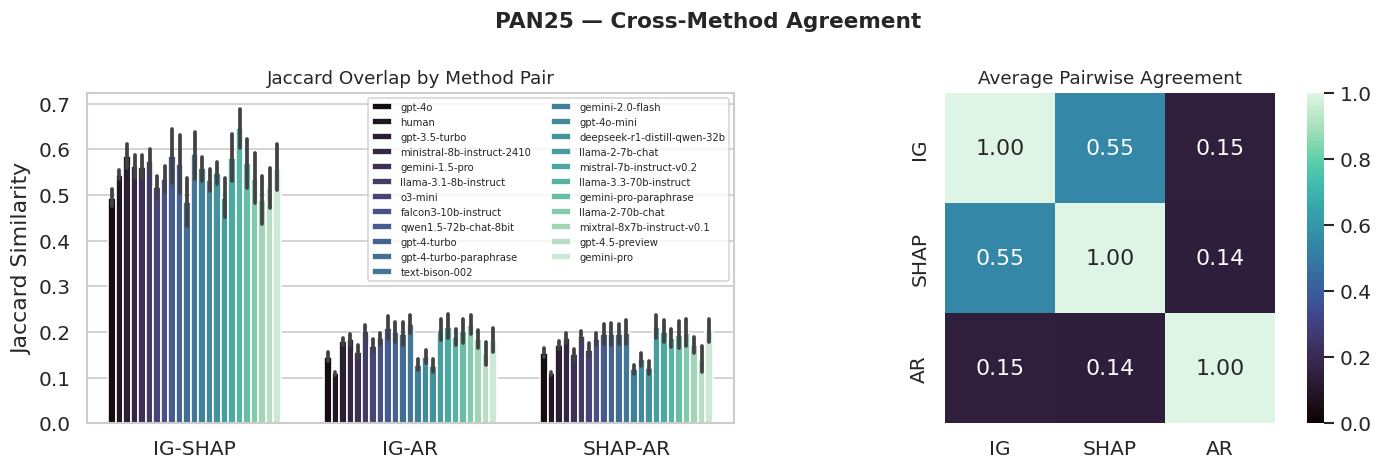

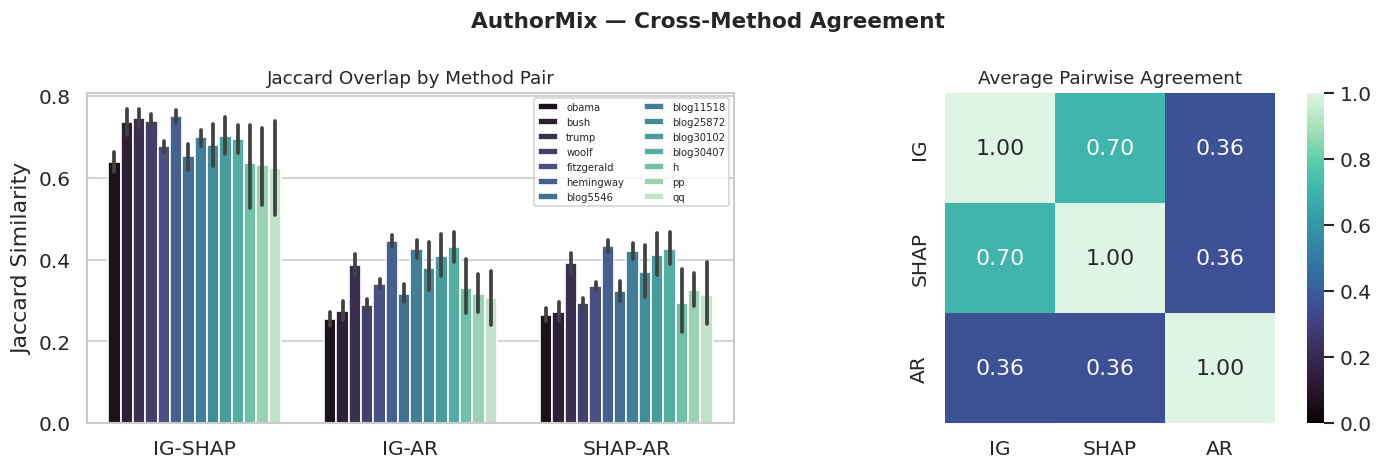


PAN25 — Mean Jaccard Overlap:


,mean,std
pair,,
IG-AR,0.147,0.086
IG-SHAP,0.547,0.172
SHAP-AR,0.144,0.087



AuthorMix — Mean Jaccard Overlap:


,mean,std
pair,,
IG-AR,0.360,0.196
IG-SHAP,0.704,0.210
SHAP-AR,0.358,0.195



  PAN25 — Consensus Tokens (in top-15 of ALL 3 methods)
  Example 0 (gpt-4o): {'.', ','}
  Example 1 (human): {';'}
  Example 2 (gpt-3.5-turbo): {'.', ','}
  Example 3 (gpt-3.5-turbo): {',', '–'}
  Example 4 (human): {'.', ','}
  Example 5 (ministral-8b-instruct-2410): {'.', 'the', ','}
  Example 6 (human): {'.'}
  Example 7 (gemini-1.5-pro): {'.'}
  Example 8 (human): {'.', ','}
  Example 9 (human): {'.'}
  Example 10 (human): {'.', ','}
  Example 11 (llama-3.1-8b-instruct): {'.', ','}
  Example 12 (gpt-3.5-turbo): {'.', ','}
  Example 13 (human): {','}
  Example 14 (gpt-4o): {':', '.', ','}
  Example 16 (human): {'“'}
  Example 17 (gpt-3.5-turbo): {'.'}
  Example 18 (human): {'.'}
  Example 19 (ministral-8b-instruct-2410): {','}
  Example 20 (falcon3-10b-instruct): {'—', '.', ','}
  ... (showing first 20 examples)

  AuthorMix — Consensus Tokens (in top-15 of ALL 3 methods)
  Example 0 (obama): {'##ac', '.', 'thank', 'very', '##as', '##ias', 'you', 'so', 'much'}
  Example 1 (obama):

In [15]:
plot_agreement(pan_data, "PAN25")
plot_agreement(am_data, "AuthorMix")

# Overall IG-SHAP overlap stats
pan_agree = pairwise_agreement(pan_data)
am_agree  = pairwise_agreement(am_data)

print("\nPAN25 — Mean Jaccard Overlap:")
display(pan_agree.groupby("pair")["jaccard"].agg(["mean", "std"]).round(3))

print("\nAuthorMix — Mean Jaccard Overlap:")
display(am_agree.groupby("pair")["jaccard"].agg(["mean", "std"]).round(3))

consensus_tokens(pan_data, "PAN25")
consensus_tokens(am_data, "AuthorMix")

## 7. Vocabulary fingerprints

Top-attributed tokens per class are aggregated to build vocabulary signatures.

In [16]:
def vocabulary_fingerprint(data, method_key="top_ig", top_n=20):
    """
    Aggregate top-attributed tokens per class.
    Returns: class_vocab (token -> total score), class_count (token -> frequency)
    """
    class_vocab = defaultdict(lambda: defaultdict(float))
    class_count = defaultdict(lambda: defaultdict(int))

    for ex in data:
        cls = ex["class_name"]
        for tok, score in ex[method_key]:
            clean_tok = tok.lower().replace("##", "")
            if clean_tok in ("[cls]", "[sep]", "[pad]"):
                continue
            class_vocab[cls][clean_tok] += abs(float(score))
            class_count[cls][clean_tok] += 1

    return class_vocab, class_count


def plot_fingerprint(data, dataset_name, method_key="top_ig", method_label="IG",
                     top_n=15, classes_to_show=None):
    """
    Horizontal bar chart of top vocabulary per class.
    Design-only change: uses the same mako colour style as the lexical plots.
    """
    vocab, counts = vocabulary_fingerprint(data, method_key)
    classes = sorted(vocab.keys()) if classes_to_show is None else classes_to_show

    fig, axes = plt.subplots(1, len(classes), figsize=(7 * len(classes), 6), dpi=150)
    if len(classes) == 1:
        axes = [axes]
    palette = sns.color_palette("mako", n_colors=len(classes))
    class_colors = dict(zip(classes, palette))

    for ax, cls in zip(axes, classes):
        sorted_words = sorted(vocab[cls].items(), key=lambda x: -x[1])[:top_n]
        words = [w for w, _ in sorted_words]
        scores = [s for _, s in sorted_words]
        freqs = [counts[cls][w] for w in words]

        ax.barh(
            range(len(words)),
            scores,
            color=class_colors[cls],
            edgecolor="white",
            linewidth=0.6
        )

        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(
            [f"{w}  (x{f})" for w, f in zip(words, freqs)],
            fontsize=9
        )
        ax.invert_yaxis()
        ax.set_xlabel("Total Attribution Score", fontsize=10)
        ax.set_title(f"Class: {cls}", fontsize=12, fontweight="bold")
        ax.grid(axis="x", alpha=0.25)
        ax.tick_params(axis="x", labelsize=9)

    fig.suptitle(
        f"{dataset_name} — Vocabulary Fingerprint ({method_label})",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

def exclusive_tokens(data, method_key="top_ig", top_n=10):
    """Find tokens that appear ONLY in one class's top attributions."""
    class_tokens = defaultdict(set)
    for ex in data:
        cls = ex["class_name"]
        for tok, _ in ex[method_key]:
            clean = tok.lower().replace("##", "")
            if clean not in ("[cls]", "[sep]", "[pad]"):
                class_tokens[cls].add(clean)

    classes = list(class_tokens.keys())
    print(f"\nExclusive tokens ({method_key}, showing up to {top_n} per class):")
    for cls in sorted(classes):
        others = set()
        for other_cls in classes:
            if other_cls != cls:
                others |= class_tokens[other_cls]
        exclusive = class_tokens[cls] - others
        shown = sorted(exclusive)[:top_n]
        print(f"  {cls} only ({len(exclusive)} total): {shown if shown else 'none'}")

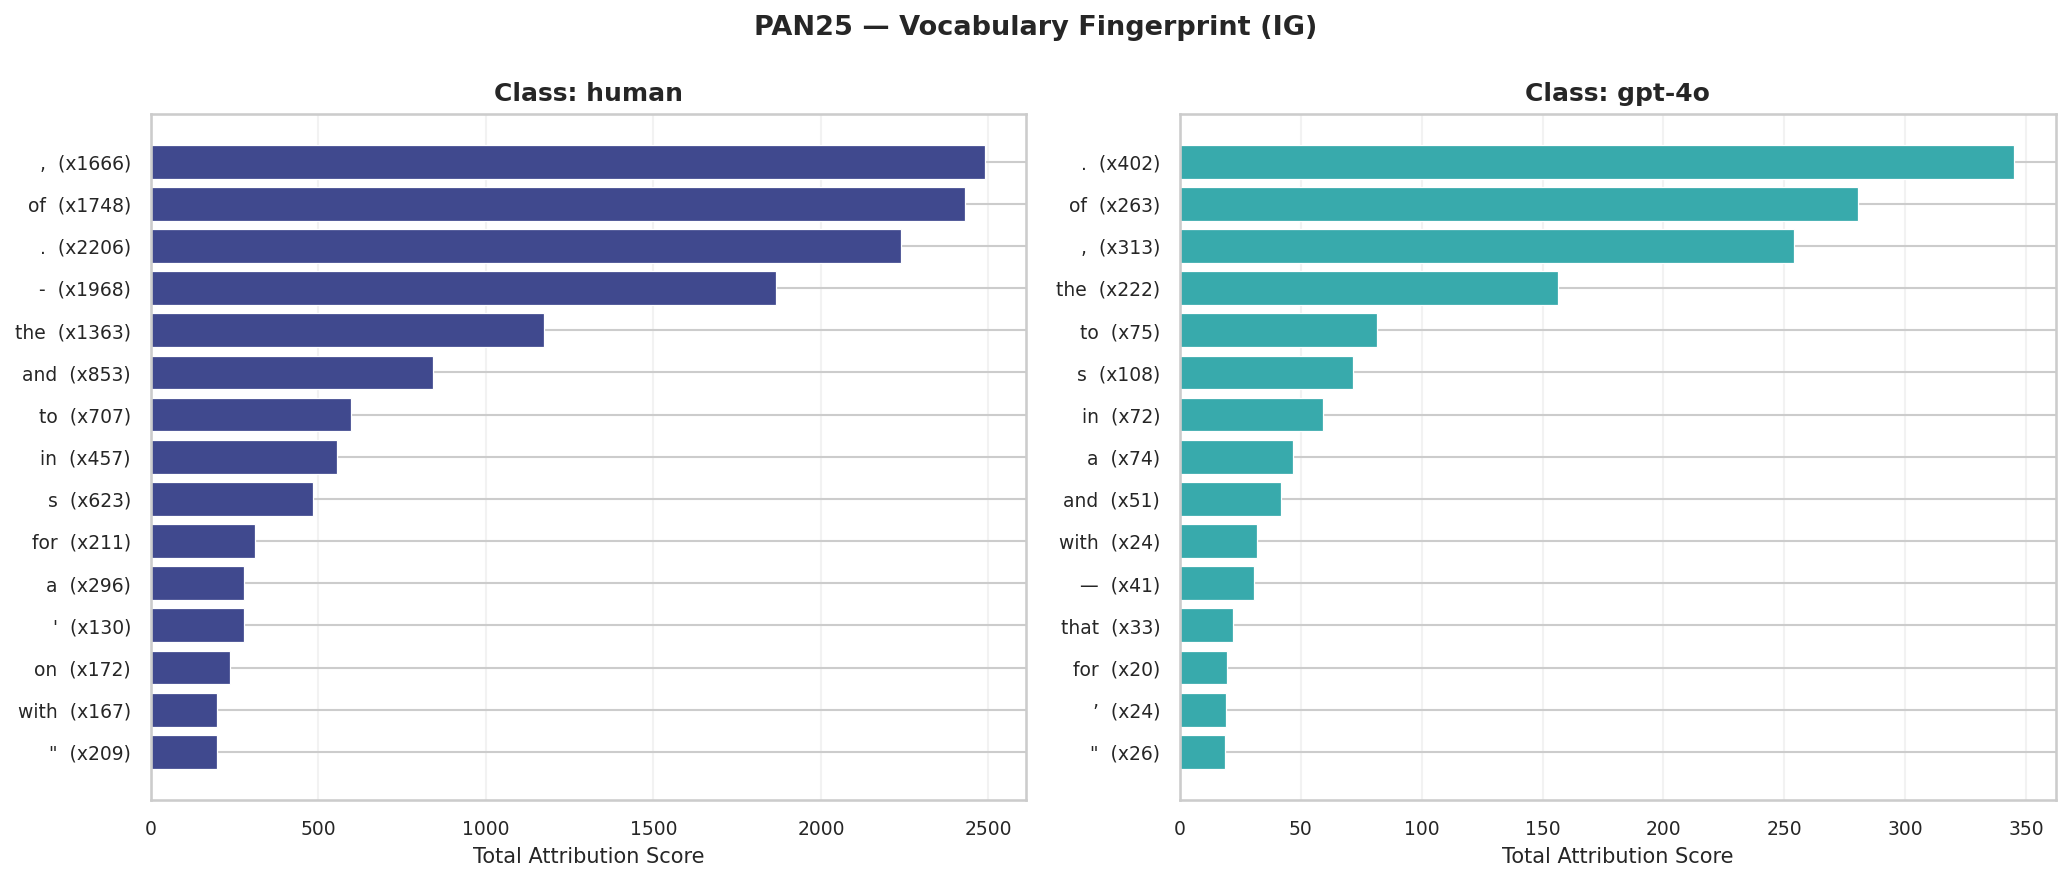

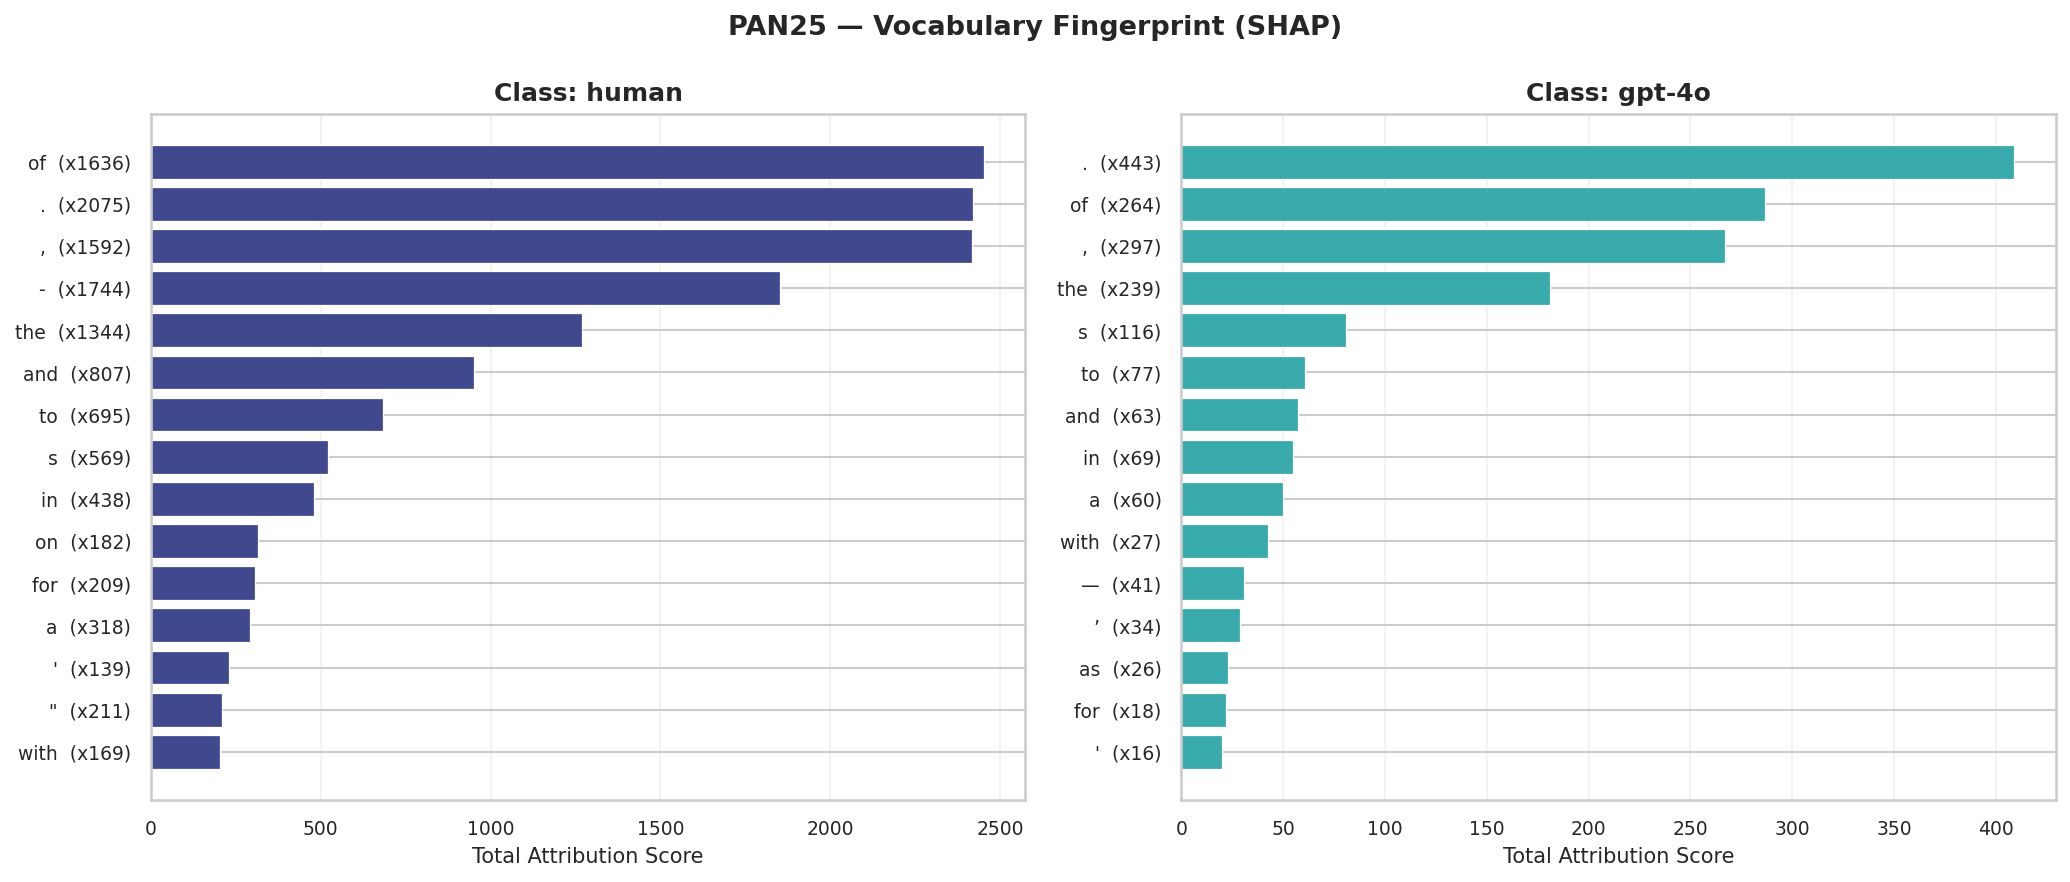

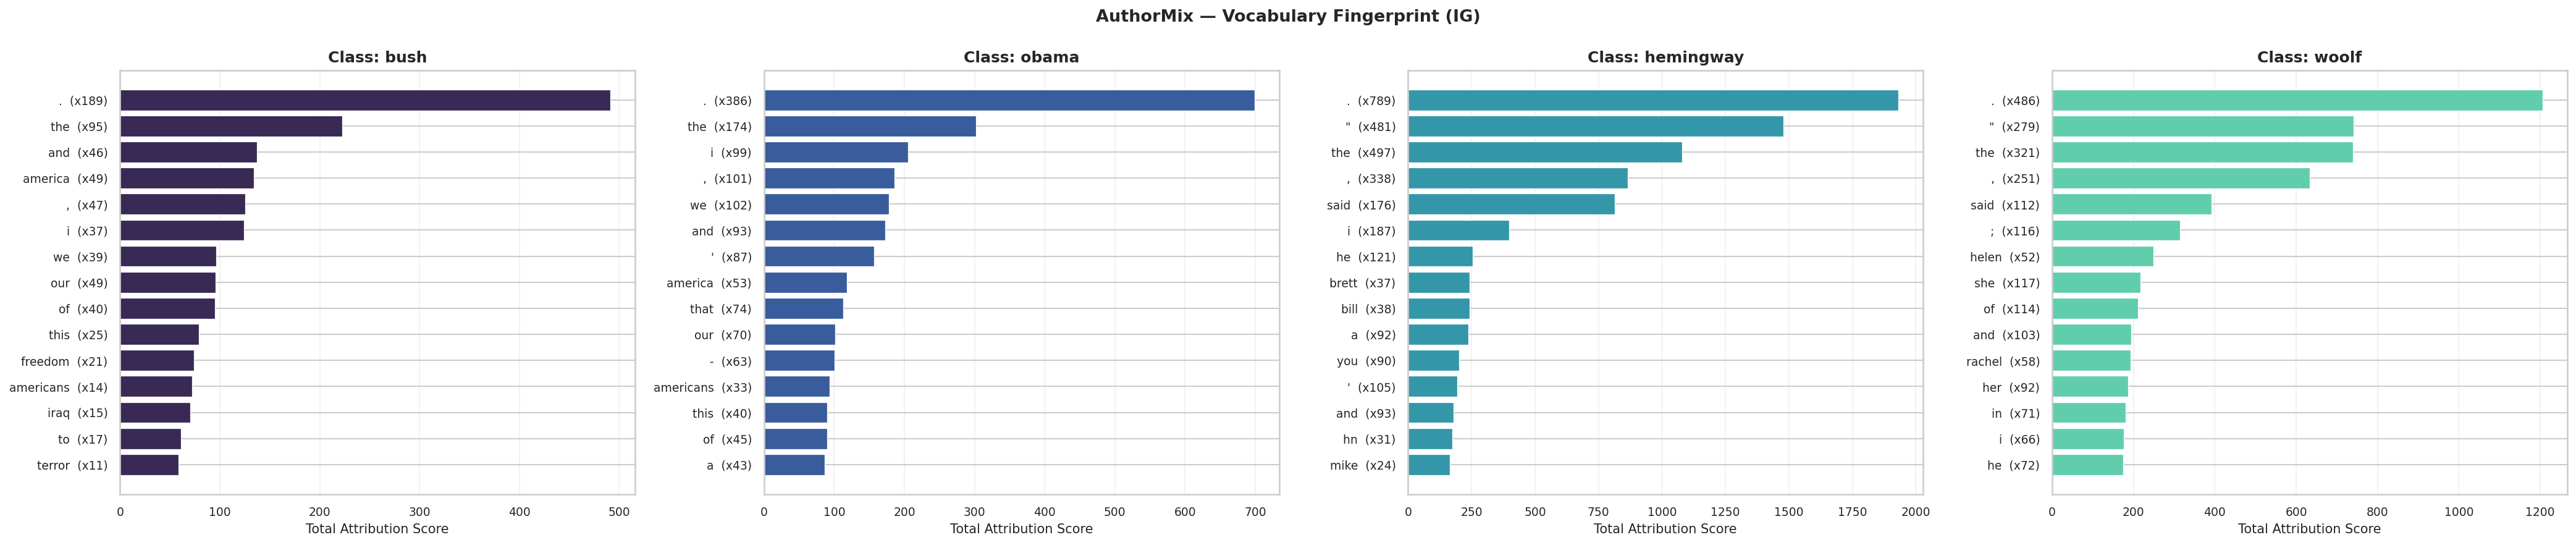


PAN25:

Exclusive tokens (top_ig, showing up to 10 per class):
  deepseek-r1-distill-qwen-32b only (96 total): ['8', '_', 'ali', 'analysis', 'angular', 'arises', 'assistance', 'attempting', 'ax', 'b']
  falcon3-10b-instruct only (126 total): ['ad', 'ah', 'algebra', 'alternative', 'anticipation', 'ascending', 'attire', 'beaming', 'begun', 'bel']
  gemini-1.5-pro only (92 total): ['airline', 'angela', 'appeal', 'assembled', 'austen', 'bank', 'baron', 'blush', 'bony', 'brand']
  gemini-2.0-flash only (126 total): [']', 'abortion', 'accounts', 'adventures', 'armchair', 'assaulted', 'athy', 'aware', 'aye', 'backing']
  gemini-pro only (40 total): ['address', 'allegations', 'attorney', 'bizarre', 'cites', 'congressional', 'distribution', 'exposed', 'fbi', 'filled']
  gemini-pro-paraphrase only (51 total): ['&', '2018', '3', 'advance', 'africa', 'algorithm', 'appreciate', 'assist', 'baldwin', 'berlin']
  gpt-3.5-turbo only (174 total): ['2014', '300', '7th', '9', 'absently', 'admired', 'adol

In [17]:
# PAN25: human vs gpt-4o fingerprint
plot_fingerprint(pan_data, "PAN25", "top_ig", "IG", classes_to_show=["human", "gpt-4o"])
plot_fingerprint(pan_data, "PAN25", "top_gs", "SHAP", classes_to_show=["human", "gpt-4o"])

# AuthorMix: show a few key contrasts
plot_fingerprint(am_data, "AuthorMix", "top_ig", "IG", classes_to_show=["bush", "obama", "hemingway", "woolf"])

# Exclusive tokens
for mk in ["top_ig", "top_gs"]:
    print(f"\n{'='*40}")
    print("PAN25:")
    exclusive_tokens(pan_data, mk)
    print("AuthorMix:")
    exclusive_tokens(am_data, mk)

## 8. Positional analysis

Does the classifier focus on the beginning (topic sentence), middle, or end of the text?

In [18]:
def positional_analysis(data, method_key="top_ig"):
    """
    Find the positions (0-1 normalised) of the top-attributed tokens.
    """
    rows = []
    for ex in data:
        cls = ex["class_name"]
        tokens = ex["tokens"]
        n_tokens = len(tokens)

        scores = build_full_attribution_scores(ex, method_key)
        top_indices = np.argsort(scores)[-15:]
        positions = top_indices / max(n_tokens - 1, 1)

        first_third  = np.sum(positions < 0.33) / len(positions)
        middle_third = np.sum((positions >= 0.33) & (positions < 0.67)) / len(positions)
        last_third   = np.sum(positions >= 0.67) / len(positions)

        rows.append({
            "class": cls,
            "mean_position": positions.mean(),
            "std_position": positions.std(),
            "first_third": first_third,
            "middle_third": middle_third,
            "last_third": last_third,
            "positions": positions.tolist(),
            "example_idx": ex["example_idx"]
        })
    return pd.DataFrame(rows)


def plot_positions(data, dataset_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (mk, ml) in zip(axes, [
        ("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")
    ]):
        df = positional_analysis(data, mk)
        classes = sorted(df["class"].unique())
        colors = dict(zip(classes, mako_palette(len(classes))))

        for cls in classes:
            all_positions = []
            for _, row in df[df["class"] == cls].iterrows():
                all_positions.extend(row["positions"])
            ax.hist(
                all_positions,
                bins=15,
                alpha=0.45,
                label=cls,
                density=True,
                color=colors[cls],
                edgecolor="white",
                linewidth=0.3
            )

        ax.set_title(ml, fontsize=11)
        ax.set_xlabel("Normalised Position (0=start, 1=end)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=6, ncol=2)

    fig.suptitle(f"{dataset_name} — Positional Distribution of Top Attributions",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def position_table(data, dataset_name):
    print(f"\n{dataset_name} — Mean position of top-attributed tokens:")
    for mk, ml in [("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")]:
        df = positional_analysis(data, mk)
        tbl = df.groupby("class")[["mean_position", "first_third", "middle_third", "last_third"]].mean().round(3)
        print(f"\n  {ml}:")
        display(tbl)

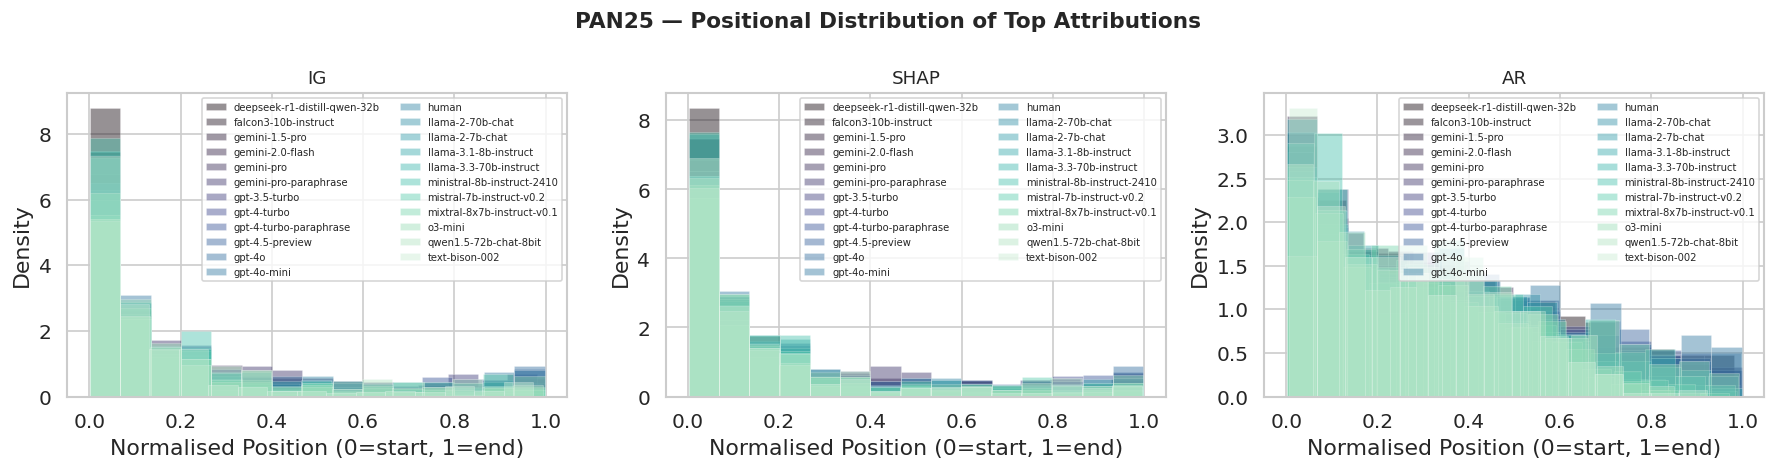

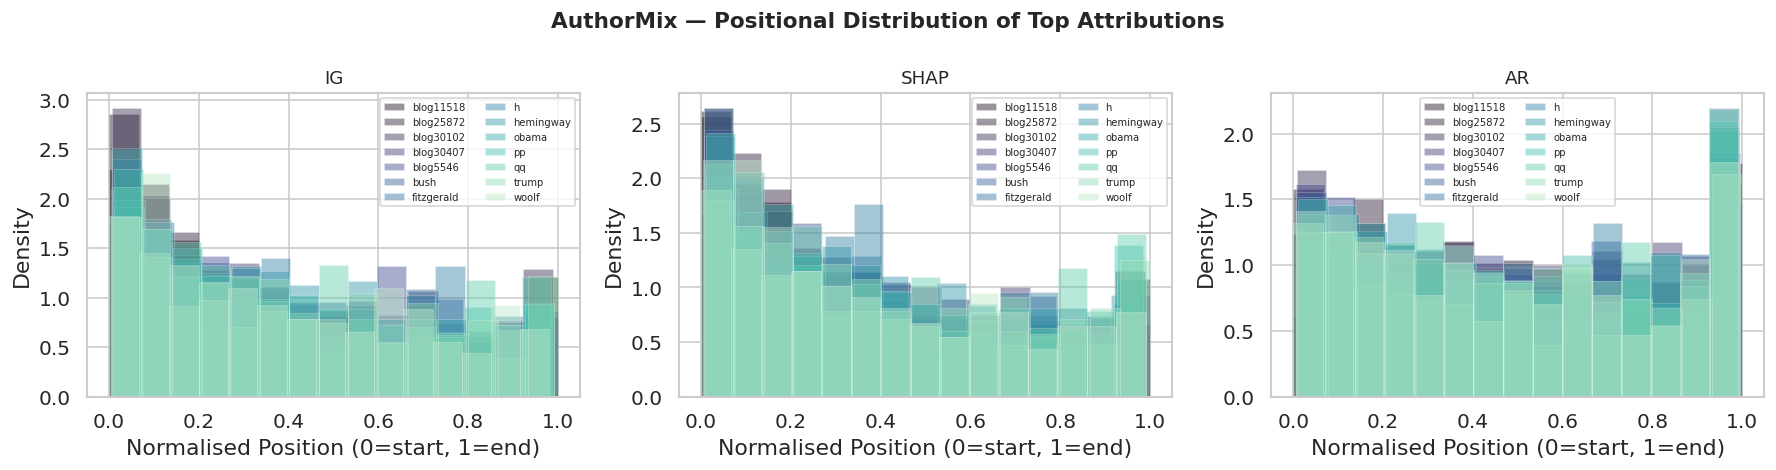


PAN25 — Mean position of top-attributed tokens:

  IG:


,mean_position,first_third,middle_third,last_third
class,,,,
deepseek-r1-distill-qwen-32b,0.135,0.896,0.051,0.053
falcon3-10b-instruct,0.176,0.831,0.089,0.080
gemini-1.5-pro,0.182,0.822,0.111,0.067
gemini-2.0-flash,0.174,0.840,0.102,0.058
gemini-pro,0.222,0.764,0.138,0.098
gemini-pro-paraphrase,0.262,0.687,0.218,0.096
gpt-3.5-turbo,0.246,0.751,0.104,0.144
gpt-4-turbo,0.216,0.796,0.096,0.109
gpt-4-turbo-paraphrase,0.254,0.733,0.131,0.136



  SHAP:


,mean_position,first_third,middle_third,last_third
class,,,,
deepseek-r1-distill-qwen-32b,0.152,0.880,0.060,0.060
falcon3-10b-instruct,0.178,0.833,0.098,0.069
gemini-1.5-pro,0.168,0.849,0.093,0.058
gemini-2.0-flash,0.174,0.827,0.122,0.051
gemini-pro,0.211,0.784,0.124,0.091
gemini-pro-paraphrase,0.272,0.673,0.211,0.116
gpt-3.5-turbo,0.229,0.764,0.111,0.124
gpt-4-turbo,0.229,0.767,0.116,0.118
gpt-4-turbo-paraphrase,0.266,0.720,0.133,0.147



  AR:


...

,mean_position,first_third,middle_third,last_third
class,,,,
blog11518,0.342,0.589,0.233,0.178
blog25872,0.376,0.549,0.229,0.222
blog30102,0.359,0.558,0.256,0.187
blog30407,0.432,0.431,0.323,0.246
blog5546,0.397,0.484,0.313,0.202
bush,0.418,0.460,0.298,0.242
fitzgerald,0.392,0.511,0.247,0.242
h,0.429,0.448,0.257,0.295
hemingway,0.410,0.462,0.333,0.204



  SHAP:


,mean_position,first_third,middle_third,last_third
class,,,,
blog11518,0.352,0.580,0.229,0.191
blog25872,0.351,0.584,0.222,0.193
blog30102,0.368,0.549,0.262,0.189
blog30407,0.436,0.422,0.320,0.258
blog5546,0.377,0.520,0.271,0.209
bush,0.403,0.493,0.269,0.238
fitzgerald,0.371,0.529,0.256,0.216
h,0.408,0.467,0.276,0.257
hemingway,0.392,0.482,0.327,0.191



  AR:


,mean_position,first_third,middle_third,last_third
class,,,,
blog11518,0.473,0.393,0.293,0.313
blog25872,0.475,0.391,0.311,0.298
blog30102,0.461,0.398,0.307,0.296
blog30407,0.541,0.295,0.323,0.382
blog5546,0.471,0.400,0.284,0.316
bush,0.495,0.369,0.289,0.342
fitzgerald,0.484,0.380,0.287,0.333
h,0.506,0.362,0.248,0.390
hemingway,0.481,0.384,0.320,0.296


In [19]:
# Positional analysis uses build_full_attribution_scores which needs token lists
pan_pos_data = stratified_sample(pan_data, n_per_class=30)
am_pos_data  = stratified_sample(am_data, n_per_class=30)

plot_positions(pan_pos_data, "PAN25")
plot_positions(am_pos_data, "AuthorMix")

position_table(pan_pos_data, "PAN25")
position_table(am_pos_data, "AuthorMix")

## 9. Statistical testing with effect sizes

Beyond p-values: Cohen's d (effect size) and Mann-Whitney U (non-parametric).

In [20]:
def cohens_d(a, b):
    """Compute Cohen's d effect size."""
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0


def full_statistical_comparison(data, ratios_df, dataset_name, class_a, class_b):
    """
    Comprehensive statistical comparison between two classes.
    Uses both the full ratios_df and the attribution data.
    """
    results = []

    # Ratio-based metrics from full validation CSV
    for method_prefix, method_label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
        for ratio_type in RATIO_TYPES:
            col = f"{method_prefix}_{ratio_type}"
            a_vals = ratios_df[ratios_df["class"] == class_a][col].values
            b_vals = ratios_df[ratios_df["class"] == class_b][col].values

            if len(a_vals) < 2 or len(b_vals) < 2:
                continue

            t_stat, t_p = ttest_ind(a_vals, b_vals, equal_var=False)
            u_stat, u_p = mannwhitneyu(a_vals, b_vals, alternative="two-sided")
            d = cohens_d(a_vals, b_vals)

            results.append({
                "Method": method_label,
                "Metric": ratio_type.replace("_", " ").title(),
                f"Mean ({class_a})": f"{a_vals.mean():.3f}",
                f"Mean ({class_b})": f"{b_vals.mean():.3f}",
                "Cohen's d": f"{d:.3f}",
                "t-stat": f"{t_stat:.3f}",
                "t p-value": f"{t_p:.2e}",
                "U p-value": f"{u_p:.2e}",
            })

    if not results:
        print(f"No data for {class_a} vs {class_b} in {dataset_name}")
        return None

    stats_df = pd.DataFrame(results)
    print(f"\n{'='*80}")
    print(f"  {dataset_name}: {class_a} vs {class_b}")
    print(f"{'='*80}")
    display(stats_df)

    # Save
    out_path = f"{RUNS_ROOT}/results/{dataset_name.lower().replace(' ','_')}_stats_{class_a}_vs_{class_b}.csv"
    stats_df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    return stats_df


def effect_size_heatmap(stats_df, dataset_name):
    """Heatmap of Cohen's d values."""
    if stats_df is None or len(stats_df) == 0:
        return

    df = stats_df.copy()
    df["d_val"] = df["Cohen's d"].astype(float)

    pivot = df.pivot(index="Metric", columns="Method", values="d_val")

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="mako", center=0,
                ax=ax, linewidths=0.5, vmin=-2, vmax=2)
    ax.set_title(f"{dataset_name} — Cohen's d Effect Sizes\n(positive = higher for first class)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


  PAN25: human vs gpt-4o


,Method,Metric,Mean (human),Mean (gpt-4o),Cohen's d,t-stat,t p-value,U p-value
0,IG,Content Ratio,0.215,0.288,-0.561,-7.689,2.83e-13,8.72e-15
1,IG,Punct Ratio,0.334,0.295,0.295,4.114,5.15e-05,2.90e-05
2,IG,Stop Ratio,0.451,0.416,0.230,3.129,1.95e-03,7.02e-03
3,IG,Newline Ratio,0.000,0.000,0.000,nan,nan,1.00e+00
4,SHAP,Content Ratio,0.230,0.288,-0.407,-5.338,2.05e-07,3.83e-08
5,SHAP,Punct Ratio,0.318,0.307,0.074,1.020,3.09e-01,3.52e-01
6,SHAP,Stop Ratio,0.452,0.405,0.292,3.648,3.22e-04,6.97e-04
7,SHAP,Newline Ratio,0.000,0.000,0.000,nan,nan,1.00e+00
8,AR,Content Ratio,0.030,0.004,0.538,14.879,1.61e-45,5.40e-15
9,AR,Punct Ratio,0.960,0.992,-0.519,-12.301,2.98e-31,2.04e-14


Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_stats_human_vs_gpt-4o.csv


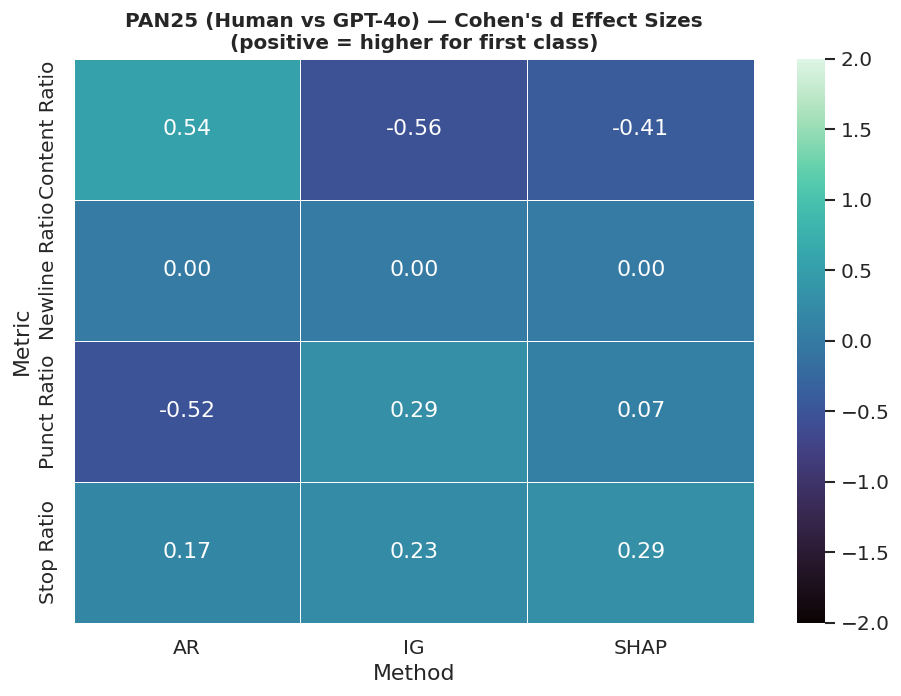


  AuthorMix: bush vs pp


,Method,Metric,Mean (bush),Mean (pp),Cohen's d,t-stat,t p-value,U p-value
0,IG,Content Ratio,0.593,0.518,0.499,2.032,5.51e-02,7.26e-02
1,IG,Punct Ratio,0.134,0.157,-0.265,-1.207,2.40e-01,2.46e-01
2,IG,Stop Ratio,0.273,0.325,-0.434,-2.147,4.21e-02,5.17e-02
3,IG,Newline Ratio,0.000,0.000,0.000,nan,nan,1.00e+00
4,SHAP,Content Ratio,0.583,0.545,0.252,1.126,2.72e-01,3.12e-01
5,SHAP,Punct Ratio,0.133,0.149,-0.209,-0.816,4.24e-01,4.00e-01
6,SHAP,Stop Ratio,0.284,0.306,-0.166,-0.938,3.56e-01,3.11e-01
7,SHAP,Newline Ratio,0.000,0.000,0.000,nan,nan,1.00e+00
8,AR,Content Ratio,0.299,0.278,0.180,0.680,5.04e-01,4.47e-01
9,AR,Punct Ratio,0.456,0.502,-0.310,-1.370,1.85e-01,2.61e-01


Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_stats_bush_vs_pp.csv


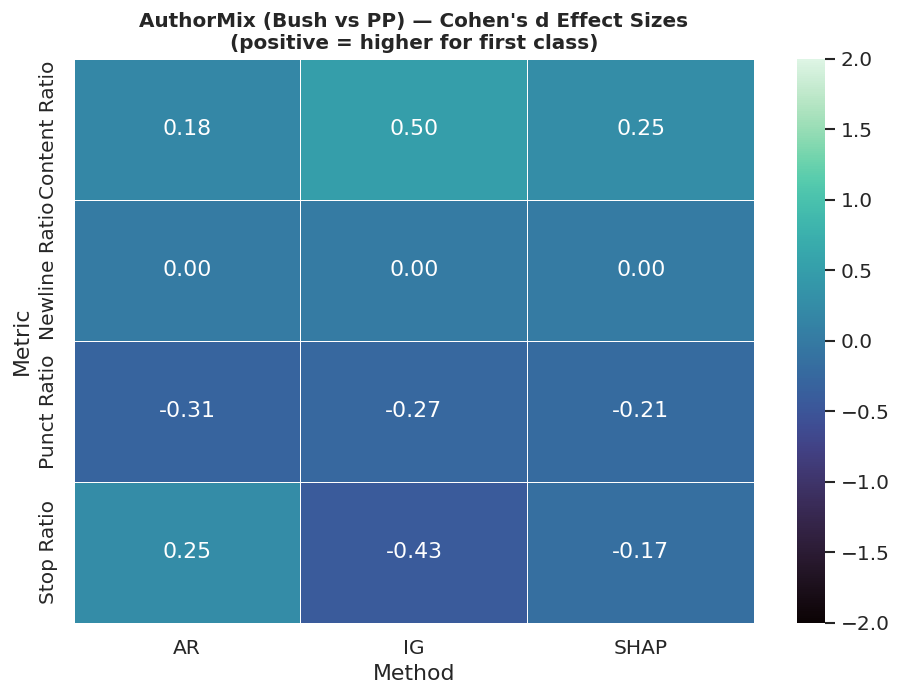

In [21]:
# PAN25: human vs gpt-4o (full validation set)
pan_stats = full_statistical_comparison(
    pan_data, pan_ratios, "PAN25", "human", "gpt-4o"
)
effect_size_heatmap(pan_stats, "PAN25 (Human vs GPT-4o)")

# AuthorMix: bush vs pp
am_stats = full_statistical_comparison(
    am_data, am_ratios, "AuthorMix", "bush", "pp"
)
effect_size_heatmap(am_stats, "AuthorMix (Bush vs PP)")

## 10. Content ratio analysis (full validation)

Per-class content ratios across all 3 methods, using the full validation set.

In [22]:
def plot_full_ratios(ratios_df, dataset_name, method_prefix="ig", method_label="IG"):
    """
    Horizontal bar chart of content ratio per class.
    Design-only change: uses the same mako colour style as the other plots.
    """
    col = f"{method_prefix}_content_ratio"
    means = ratios_df.groupby("class")[col].mean().sort_values()

    fig, ax = plt.subplots(
        figsize=(10, max(6, len(means) * 0.4)),
        dpi=150
    )
    colors = sns.color_palette("mako", n_colors=len(means))

    ax.barh(
        means.index,
        means.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6
    )

    ax.set_xlabel(f"Mean Content Ratio ({method_label})", fontsize=10)
    ax.set_ylabel("")
    ax.set_title(
        f"{dataset_name} — Content Ratio per Class ({method_label}, Full Validation)",
        fontsize=12,
        fontweight="bold"
    )

    ax.grid(axis="x", alpha=0.25)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    plt.show()


def summarize_ratios_with_std(ratios_df, dataset_name):
    """Summary table: mean +/- std for all 3 methods."""
    for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
        cols = [f"{prefix}_{ratio}" for ratio in RATIO_TYPES]
        summary = ratios_df.groupby("class")[cols].agg(["mean", "std"]).round(3)
        print(f"\n{dataset_name} — {label} ratios (mean +/- std):")
        display(summary)

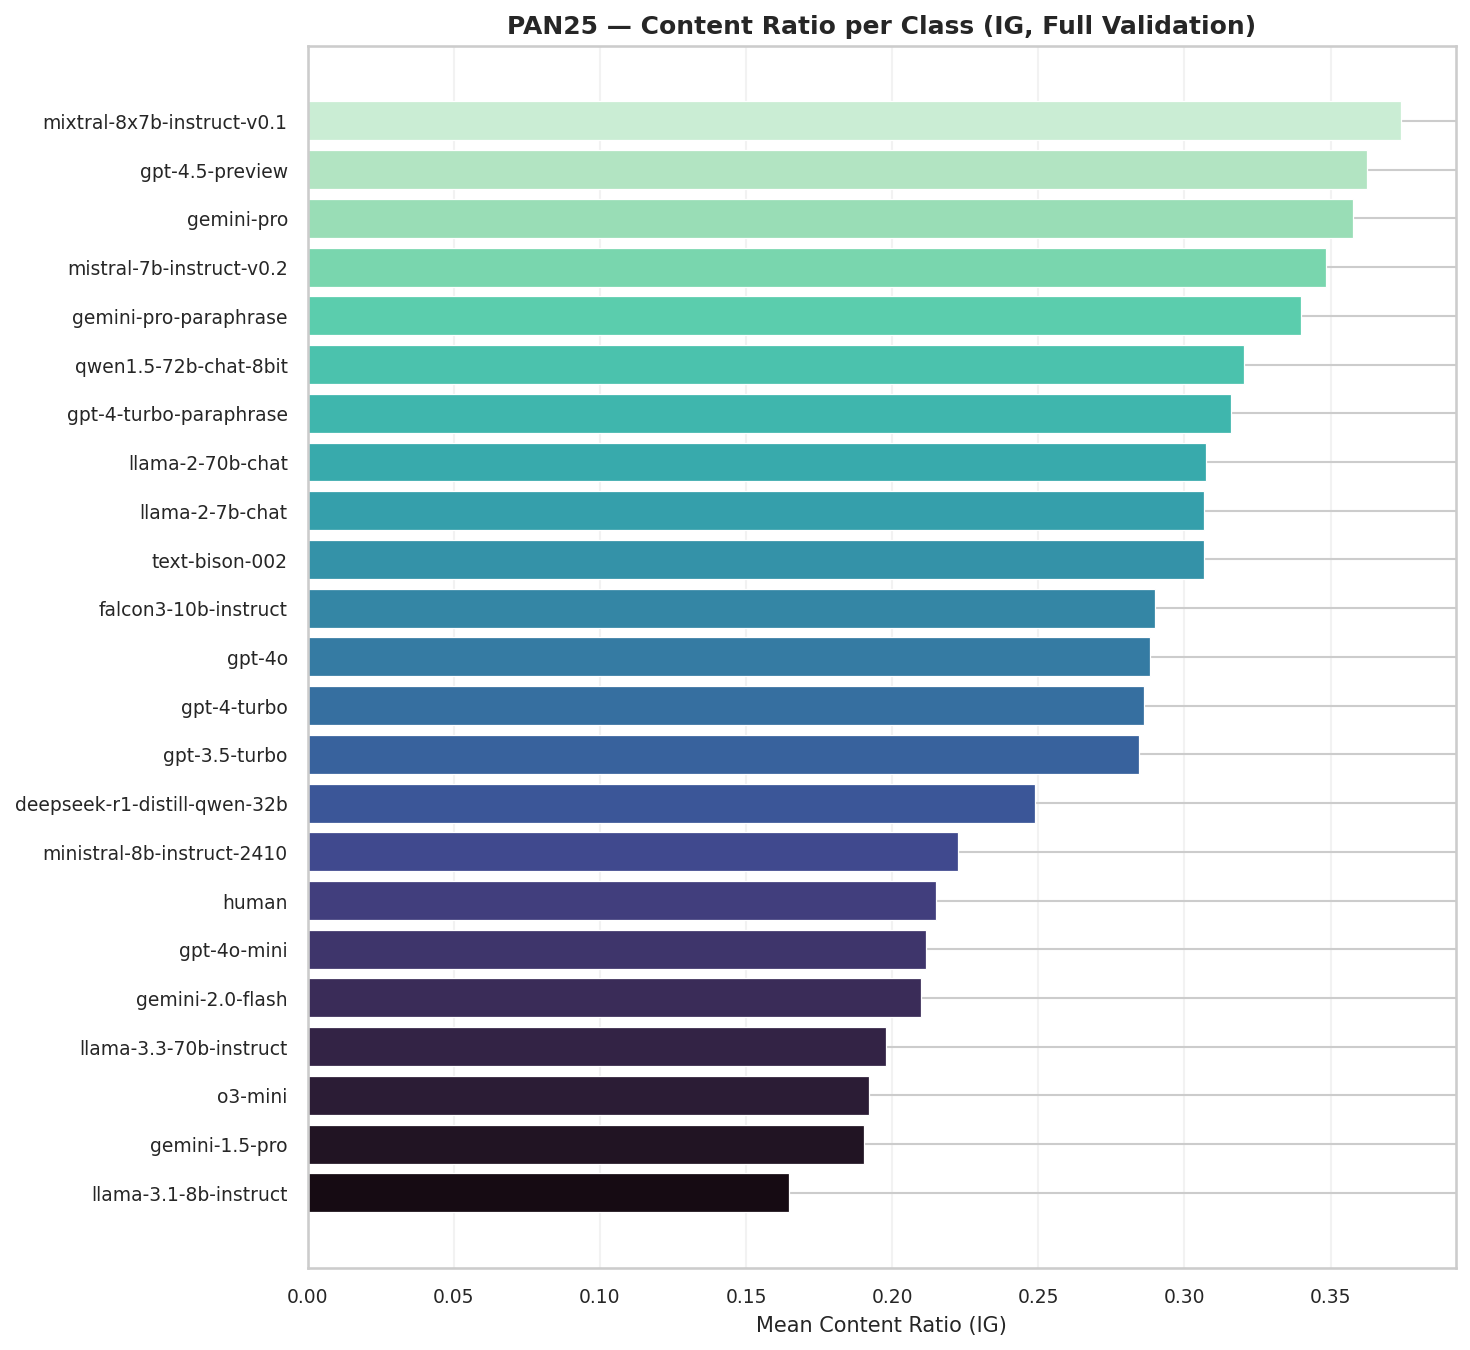

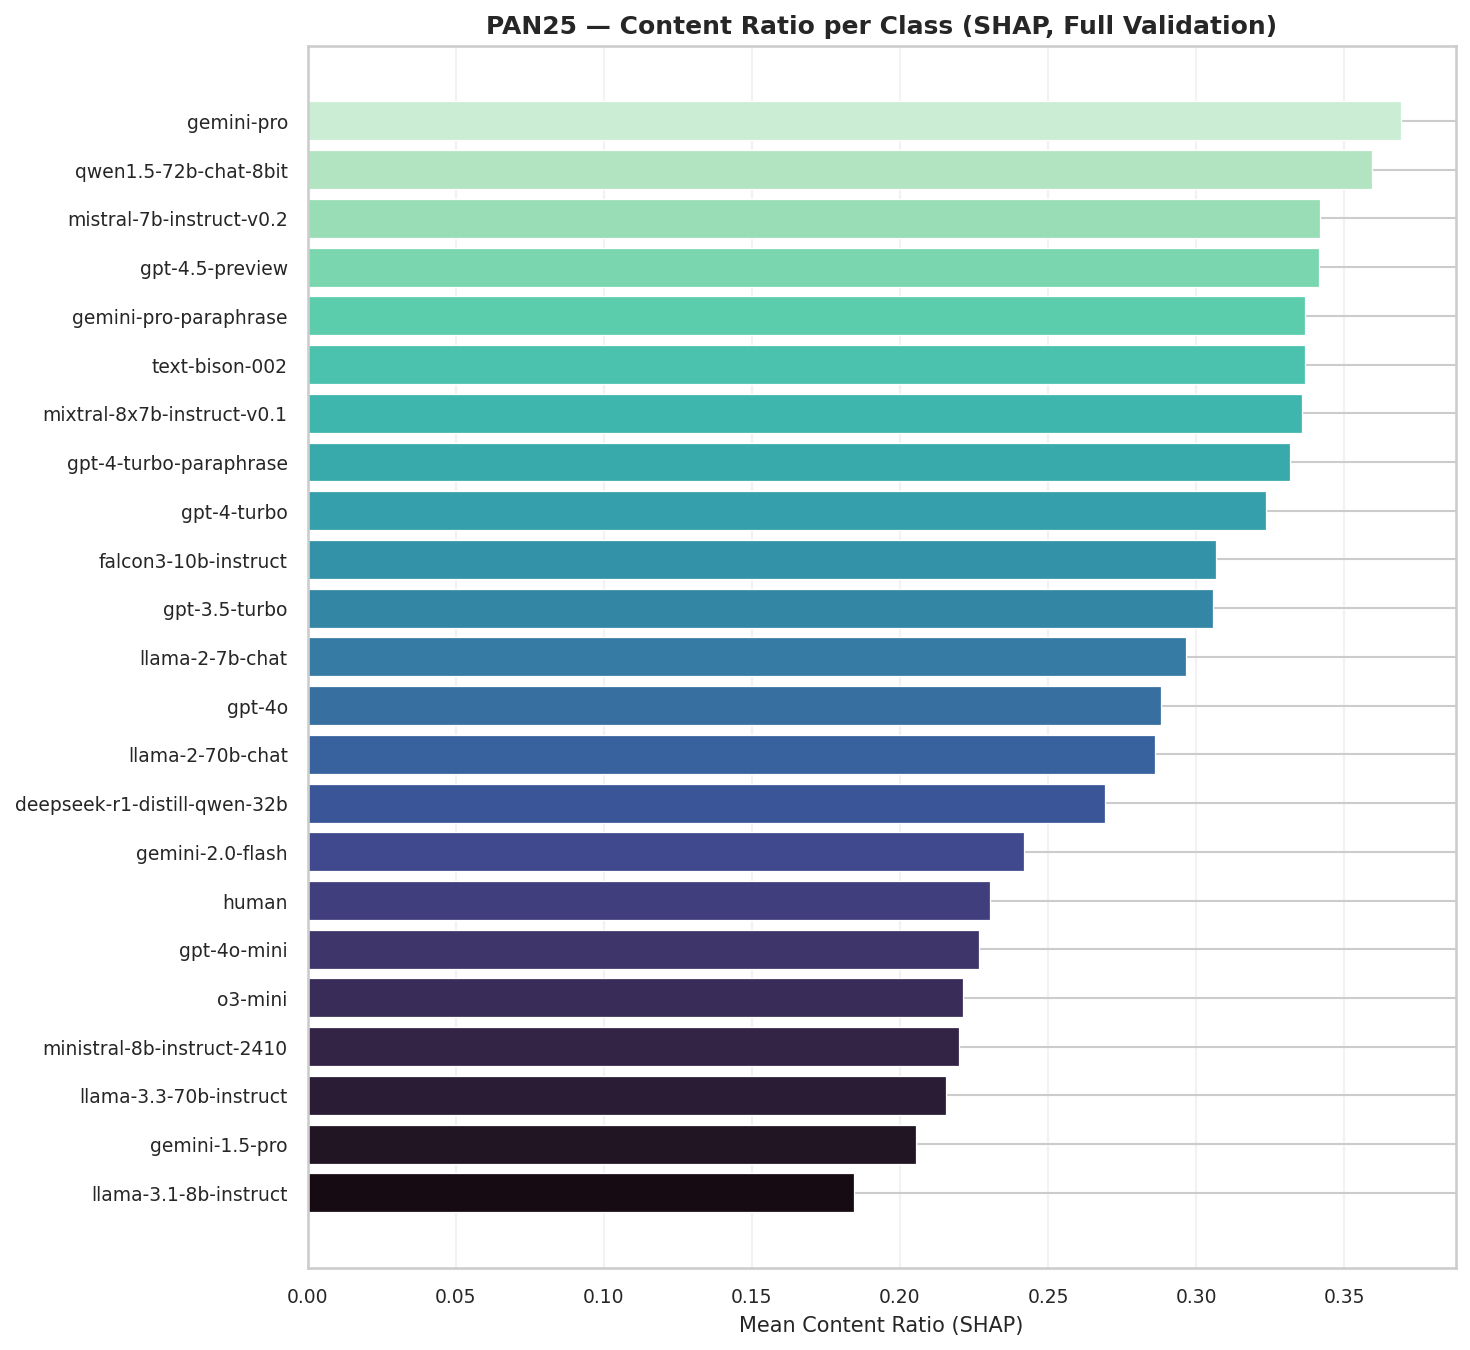

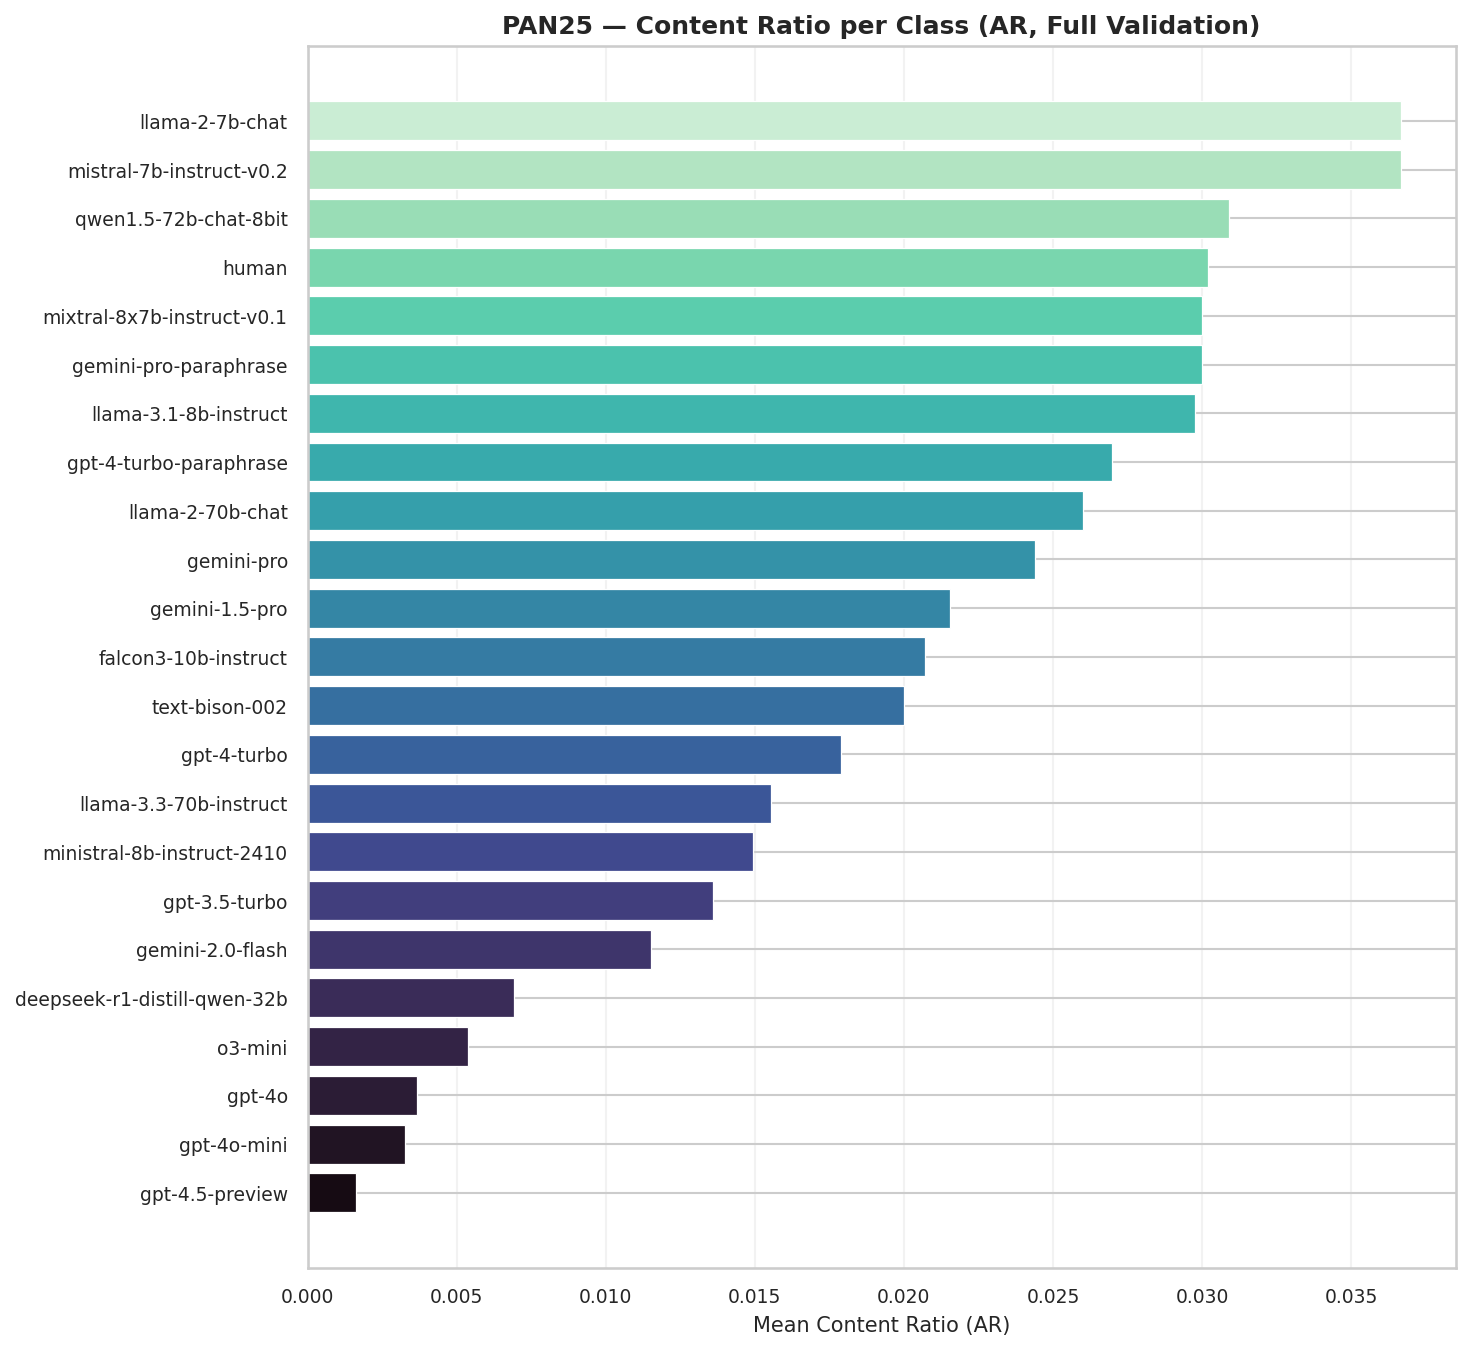


PAN25 — IG ratios (mean +/- std):


ig_content_ratio        ig_punct_ratio         \
                                         mean    std           mean    std   
class                                                                        
deepseek-r1-distill-qwen-32b            0.249  0.115          0.282  0.112   
falcon3-10b-instruct                    0.290  0.132          0.312  0.117   
gemini-1.5-pro                          0.190  0.106          0.323  0.125   
gemini-2.0-flash                        0.210  0.099          0.305  0.121   
gemini-pro                              0.358  0.116          0.330  0.129   
gemini-pro-paraphrase                   0.340  0.122          0.343  0.125   
gpt-3.5-turbo                           0.284  0.122          0.341  0.127   
gpt-4-turbo                             0.286  0.110          0.363  0.104   
gpt-4-turbo-paraphrase                  0.316  0.112          0.327  0.101   
gpt-4.5-preview                         0.363  0.141          0.249  0.100   
gpt-4o                                  0.288  0.125          0.295  0.123   
gpt-4o-mini                             0.211  0.117          0.347  0.132   
human                                   0.215  0.132          0.334  0.132   
llama-2-70b-chat                        0.307  0.127          0.351  0.114   
llama-2-7b-chat                         0.307  0.111          0.355  0.110   
llama-3.1-8b-instruct                   0.165  0.099          0.362  0.129   
llama-3.3-70b-instruct                  0.198  0.103          0.328  0.125   
ministral-8b-instruct-2410              0.223  0.105          0.290  0.115   
mistral-7b-instruct-v0.2                0.348  0.110          0.362  0.127   
mixtral-8x7b-instruct-v0.1              0.374  0.132          0.321  0.115   
o3-mini                                 0.192  0.109          0.323  0.134   
qwen1.5-72b-chat-8bit                   0.320  0.129          0.366  0.125   
text-bison-002                          0.307  0.121          0.385  0.118   

                             ig_stop_ratio        ig_newline_ratio       
                                      mean    std             mean  std  
class                                                                    
deepseek-r1-distill-qwen-32b         0.469  0.132              0.0  0.0  
falcon3-10b-instruct                 0.398  0.145              0.0  0.0  
gemini-1.5-pro                       0.486  0.137              0.0  0.0  
gemini-2.0-flash                     0.485  0.140              0.0  0.0  
gemini-pro                           0.312  0.123              0.0  0.0  
gemini-pro-paraphrase                0.317  0.110              0.0  0.0  
gpt-3.5-turbo                        0.374  0.143              0.0  0.0  
gpt-4-turbo                          0.351  0.148              0.0  0.0  
gpt-4-turbo-paraphrase               0.357  0.122              0.0  0.0  
gpt-4.5-preview                      0.389  0.138              0.0  0.0  
gpt-4o                               0.416  0.145              0.0  0.0  
gpt-4o-mini                          0.441  0.142              0.0  0.0  
human                                0.451  0.151              0.0  0.0  
llama-2-70b-chat                     0.341  0.133              0.0  0.0  
llama-2-7b-chat                      0.338  0.116              0.0  0.0  
llama-3.1-8b-instruct                0.473  0.142              0.0  0.0  
llama-3.3-70b-instruct               0.474  0.129              0.0  0.0  
ministral-8b-instruct-2410           0.487  0.116              0.0  0.0  
mistral-7b-instruct-v0.2             0.290  0.112              0.0  0.0  
mixtral-8x7b-instruct-v0.1           0.305  0.123              0.0  0.0  
o3-mini                              0.484  0.145              0.0  0.0  
qwen1.5-72b-chat-8bit                0.314  0.100              0.0  0.0  
text-bison-002                       0.308  0.119              0.0  0.0


PAN25 — SHAP ratios (mean +/- std):


gs_content_ratio        gs_punct_ratio         \
                                         mean    std           mean    std   
class                                                                        
deepseek-r1-distill-qwen-32b            0.269  0.126          0.254  0.124   
falcon3-10b-instruct                    0.307  0.153          0.315  0.123   
gemini-1.5-pro                          0.205  0.114          0.329  0.136   
gemini-2.0-flash                        0.242  0.125          0.290  0.129   
gemini-pro                              0.369  0.115          0.312  0.122   
gemini-pro-paraphrase                   0.337  0.133          0.342  0.142   
gpt-3.5-turbo                           0.306  0.131          0.316  0.121   
gpt-4-turbo                             0.324  0.119          0.340  0.118   
gpt-4-turbo-paraphrase                  0.332  0.120          0.340  0.107   
gpt-4.5-preview                         0.341  0.142          0.254  0.127   
gpt-4o                                  0.288  0.143          0.307  0.133   
gpt-4o-mini                             0.227  0.125          0.328  0.136   
human                                   0.230  0.142          0.318  0.142   
llama-2-70b-chat                        0.286  0.123          0.324  0.131   
llama-2-7b-chat                         0.297  0.143          0.342  0.121   
llama-3.1-8b-instruct                   0.184  0.110          0.339  0.142   
llama-3.3-70b-instruct                  0.216  0.111          0.319  0.137   
ministral-8b-instruct-2410              0.220  0.112          0.287  0.118   
mistral-7b-instruct-v0.2                0.342  0.119          0.370  0.112   
mixtral-8x7b-instruct-v0.1              0.336  0.127          0.296  0.111   
o3-mini                                 0.221  0.118          0.295  0.142   
qwen1.5-72b-chat-8bit                   0.359  0.137          0.343  0.124   
text-bison-002                          0.337  0.138          0.342  0.122   

                             gs_stop_ratio        gs_newline_ratio       
                                      mean    std             mean  std  
class                                                                    
deepseek-r1-distill-qwen-32b         0.477  0.148              0.0  0.0  
falcon3-10b-instruct                 0.378  0.146              0.0  0.0  
gemini-1.5-pro                       0.465  0.137              0.0  0.0  
gemini-2.0-flash                     0.468  0.152              0.0  0.0  
gemini-pro                           0.319  0.127              0.0  0.0  
gemini-pro-paraphrase                0.322  0.138              0.0  0.0  
gpt-3.5-turbo                        0.378  0.153              0.0  0.0  
gpt-4-turbo                          0.337  0.122              0.0  0.0  
gpt-4-turbo-paraphrase               0.329  0.150              0.0  0.0  
gpt-4.5-preview                      0.405  0.161              0.0  0.0  
gpt-4o                               0.405  0.173              0.0  0.0  
gpt-4o-mini                          0.445  0.150              0.0  0.0  
human                                0.452  0.160              0.0  0.0  
llama-2-70b-chat                     0.390  0.165              0.0  0.0  
llama-2-7b-chat                      0.362  0.134              0.0  0.0  
llama-3.1-8b-instruct                0.476  0.152              0.0  0.0  
llama-3.3-70b-instruct               0.466  0.141              0.0  0.0  
ministral-8b-instruct-2410           0.493  0.134              0.0  0.0  
mistral-7b-instruct-v0.2             0.288  0.128              0.0  0.0  
mixtral-8x7b-instruct-v0.1           0.369  0.156              0.0  0.0  
o3-mini                              0.484  0.157              0.0  0.0  
qwen1.5-72b-chat-8bit                0.298  0.115              0.0  0.0  
text-bison-002                       0.322  0.113              0.0  0.0


PAN25 — AR ratios (mean +/- std):


ar_content_ratio        ar_punct_ratio         \
                                         mean    std           mean    std   
class                                                                        
deepseek-r1-distill-qwen-32b            0.007  0.022          0.985  0.036   
falcon3-10b-instruct                    0.021  0.048          0.974  0.051   
gemini-1.5-pro                          0.022  0.043          0.967  0.050   
gemini-2.0-flash                        0.012  0.027          0.982  0.039   
gemini-pro                              0.024  0.042          0.963  0.056   
gemini-pro-paraphrase                   0.030  0.048          0.958  0.056   
gpt-3.5-turbo                           0.014  0.029          0.973  0.042   
gpt-4-turbo                             0.018  0.030          0.980  0.034   
gpt-4-turbo-paraphrase                  0.027  0.039          0.959  0.049   
gpt-4.5-preview                         0.002  0.010          0.972  0.039   
gpt-4o                                  0.004  0.015          0.992  0.027   
gpt-4o-mini                             0.003  0.014          0.994  0.021   
human                                   0.030  0.052          0.960  0.064   
llama-2-70b-chat                        0.026  0.049          0.967  0.056   
llama-2-7b-chat                         0.037  0.060          0.955  0.061   
llama-3.1-8b-instruct                   0.030  0.052          0.959  0.059   
llama-3.3-70b-instruct                  0.016  0.036          0.972  0.054   
ministral-8b-instruct-2410              0.015  0.034          0.963  0.060   
mistral-7b-instruct-v0.2                0.037  0.050          0.953  0.057   
mixtral-8x7b-instruct-v0.1              0.030  0.056          0.967  0.062   
o3-mini                                 0.005  0.024          0.993  0.026   
qwen1.5-72b-chat-8bit                   0.031  0.056          0.963  0.060   
text-bison-002                          0.020  0.034          0.975  0.039   

                             ar_stop_ratio        ar_newline_ratio       
                                      mean    std             mean  std  
class                                                                    
deepseek-r1-distill-qwen-32b         0.008  0.024              0.0  0.0  
falcon3-10b-instruct                 0.006  0.020              0.0  0.0  
gemini-1.5-pro                       0.012  0.026              0.0  0.0  
gemini-2.0-flash                     0.007  0.024              0.0  0.0  
gemini-pro                           0.013  0.027              0.0  0.0  
gemini-pro-paraphrase                0.012  0.030              0.0  0.0  
gpt-3.5-turbo                        0.013  0.027              0.0  0.0  
gpt-4-turbo                          0.002  0.010              0.0  0.0  
gpt-4-turbo-paraphrase               0.014  0.028              0.0  0.0  
gpt-4.5-preview                      0.026  0.039              0.0  0.0  
gpt-4o                               0.005  0.018              0.0  0.0  
gpt-4o-mini                          0.002  0.014              0.0  0.0  
human                                0.010  0.032              0.0  0.0  
llama-2-70b-chat                     0.007  0.020              0.0  0.0  
llama-2-7b-chat                      0.008  0.022              0.0  0.0  
llama-3.1-8b-instruct                0.011  0.030              0.0  0.0  
llama-3.3-70b-instruct               0.012  0.029              0.0  0.0  
ministral-8b-instruct-2410           0.022  0.042              0.0  0.0  
mistral-7b-instruct-v0.2             0.010  0.028              0.0  0.0  
mixtral-8x7b-instruct-v0.1           0.003  0.015              0.0  0.0  
o3-mini                              0.002  0.010              0.0  0.0  
qwen1.5-72b-chat-8bit                0.007  0.020              0.0  0.0  
text-bison-002                       0.005  0.018              0.0  0.0

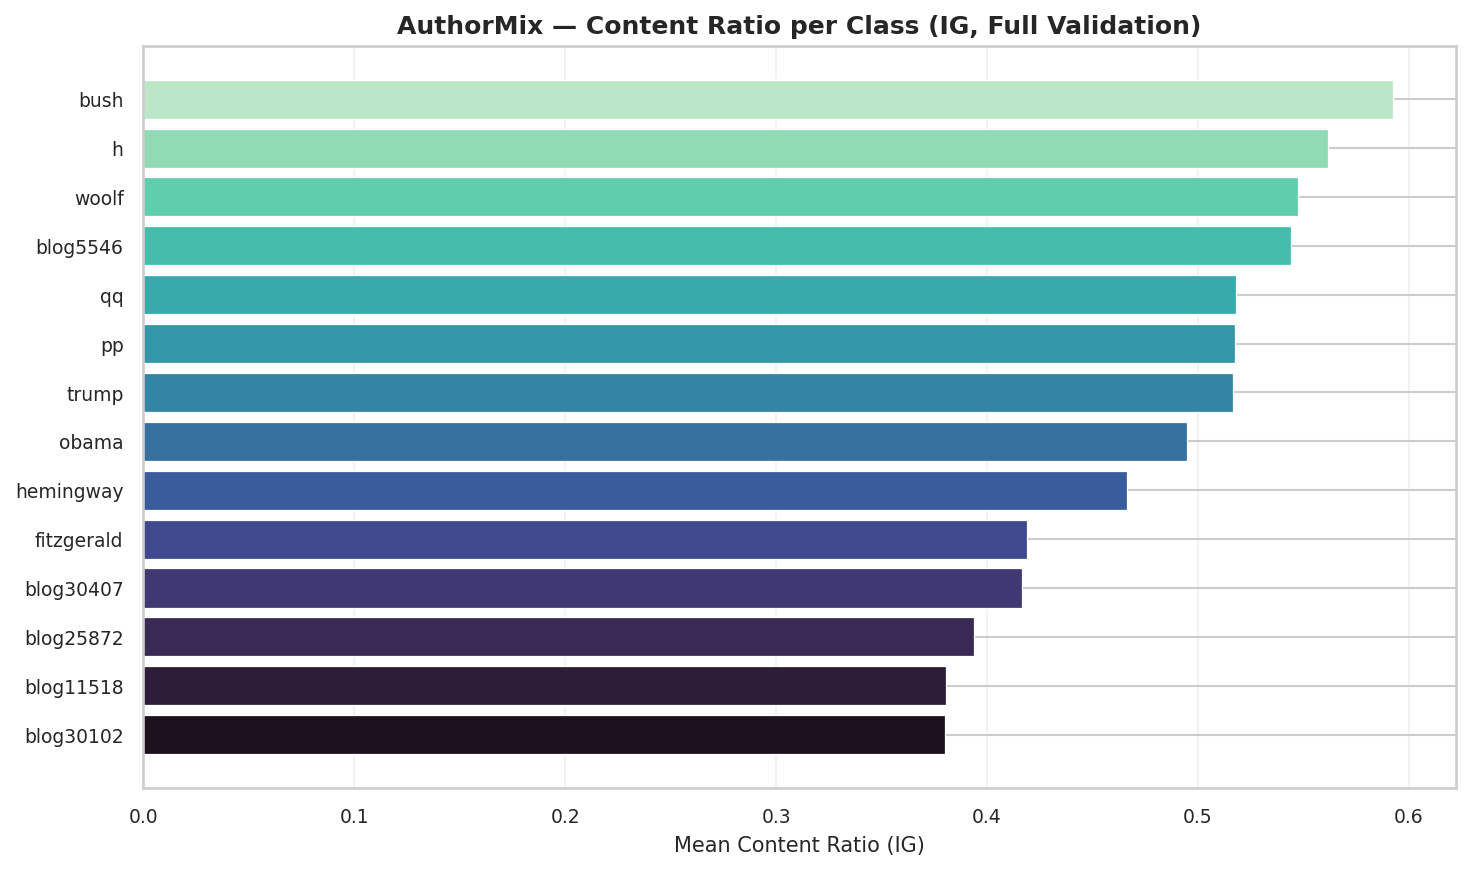

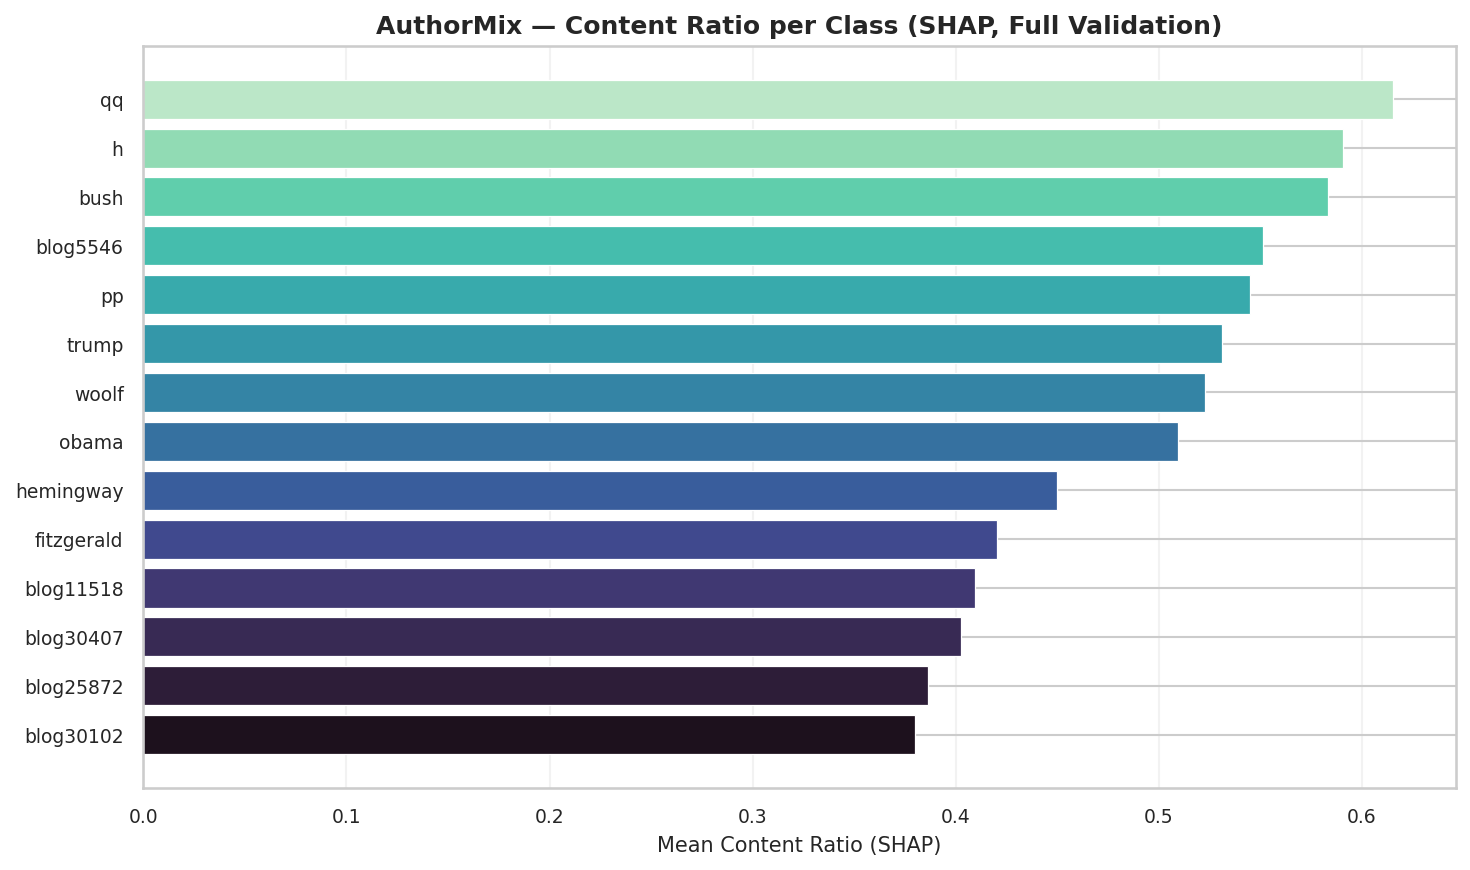

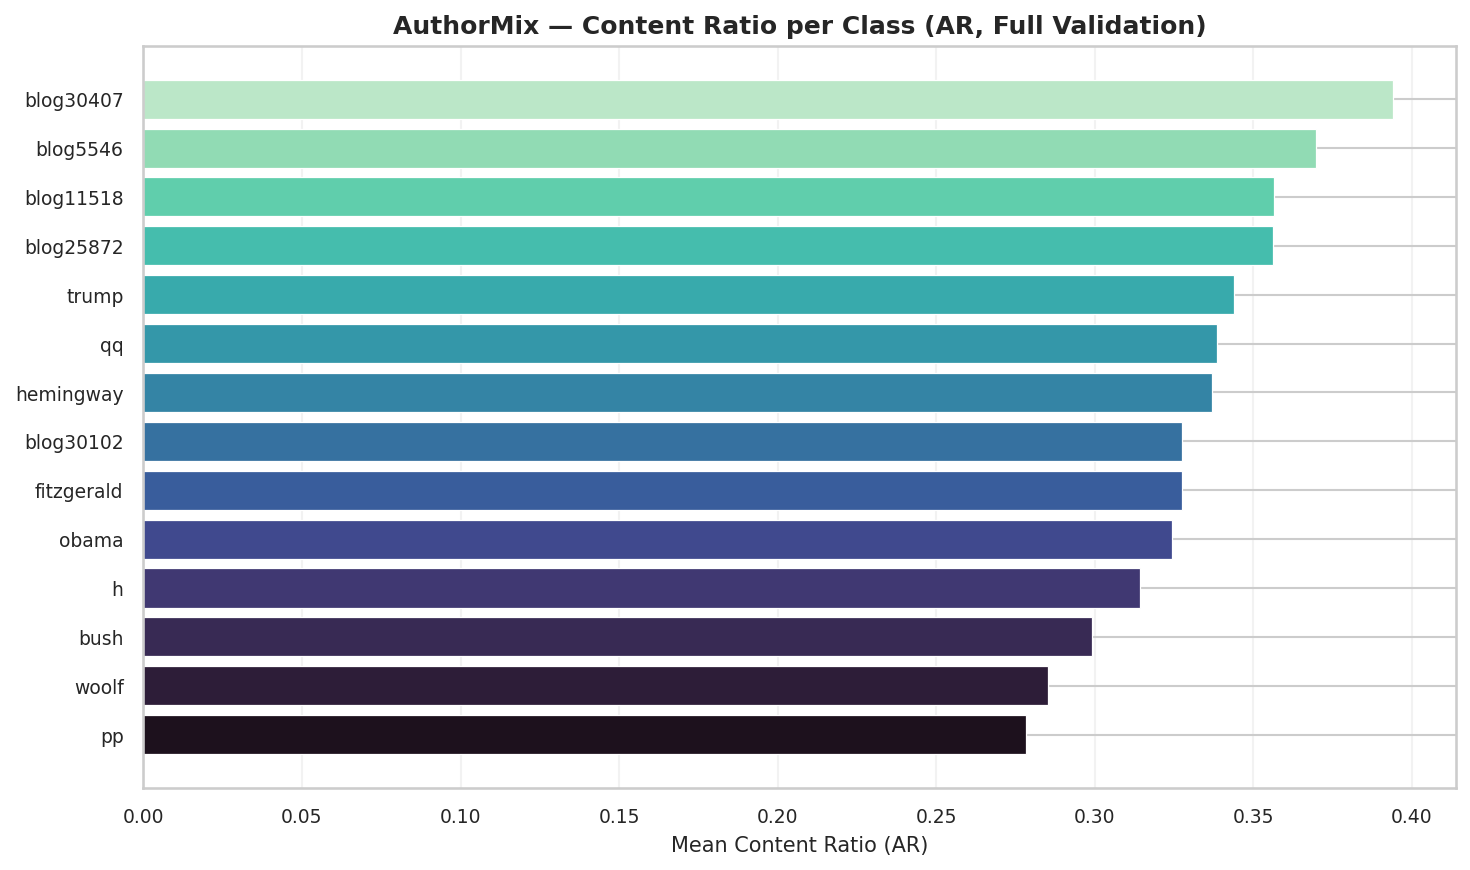


AuthorMix — IG ratios (mean +/- std):


ig_content_ratio        ig_punct_ratio        ig_stop_ratio         \
                       mean    std           mean    std          mean    std   
class                                                                           
blog11518             0.381  0.141          0.246  0.116         0.374  0.132   
blog25872             0.394  0.138          0.275  0.149         0.331  0.141   
blog30102             0.380  0.172          0.224  0.119         0.396  0.179   
blog30407             0.416  0.138          0.200  0.091         0.383  0.126   
blog5546              0.544  0.147          0.210  0.115         0.246  0.113   
bush                  0.593  0.152          0.134  0.087         0.273  0.125   
fitzgerald            0.419  0.159          0.274  0.133         0.307  0.138   
h                     0.562  0.119          0.143  0.090         0.295  0.104   
hemingway             0.466  0.140          0.243  0.125         0.290  0.118   
obama                 0.495  0.182          0.168  0.086         0.338  0.148   
pp                    0.518  0.142          0.157  0.070         0.325  0.091   
qq                    0.518  0.137          0.159  0.058         0.323  0.121   
trump                 0.517  0.183          0.160  0.099         0.323  0.143   
woolf                 0.548  0.148          0.191  0.110         0.261  0.124   

           ig_newline_ratio       
                       mean  std  
class                             
blog11518               0.0  0.0  
blog25872               0.0  0.0  
blog30102               0.0  0.0  
blog30407               0.0  0.0  
blog5546                0.0  0.0  
bush                    0.0  0.0  
fitzgerald              0.0  0.0  
h                       0.0  0.0  
hemingway               0.0  0.0  
obama                   0.0  0.0  
pp                      0.0  0.0  
qq                      0.0  0.0  
trump                   0.0  0.0  
woolf                   0.0  0.0


AuthorMix — SHAP ratios (mean +/- std):


gs_content_ratio        gs_punct_ratio        gs_stop_ratio         \
                       mean    std           mean    std          mean    std   
class                                                                           
blog11518             0.409  0.150          0.236  0.115         0.355  0.133   
blog25872             0.386  0.140          0.267  0.149         0.346  0.143   
blog30102             0.380  0.190          0.221  0.121         0.398  0.198   
blog30407             0.403  0.162          0.214  0.106         0.384  0.129   
blog5546              0.551  0.166          0.194  0.116         0.255  0.128   
bush                  0.583  0.156          0.133  0.077         0.284  0.139   
fitzgerald            0.421  0.168          0.262  0.135         0.318  0.142   
h                     0.590  0.122          0.133  0.083         0.276  0.104   
hemingway             0.450  0.155          0.253  0.131         0.297  0.124   
obama                 0.509  0.179          0.164  0.090         0.327  0.145   
pp                    0.545  0.130          0.149  0.076         0.306  0.085   
qq                    0.615  0.175          0.154  0.069         0.231  0.135   
trump                 0.531  0.188          0.158  0.104         0.311  0.148   
woolf                 0.523  0.167          0.204  0.115         0.273  0.137   

           gs_newline_ratio       
                       mean  std  
class                             
blog11518               0.0  0.0  
blog25872               0.0  0.0  
blog30102               0.0  0.0  
blog30407               0.0  0.0  
blog5546                0.0  0.0  
bush                    0.0  0.0  
fitzgerald              0.0  0.0  
h                       0.0  0.0  
hemingway               0.0  0.0  
obama                   0.0  0.0  
pp                      0.0  0.0  
qq                      0.0  0.0  
trump                   0.0  0.0  
woolf                   0.0  0.0


AuthorMix — AR ratios (mean +/- std):


ar_content_ratio        ar_punct_ratio        ar_stop_ratio         \
                       mean    std           mean    std          mean    std   
class                                                                           
blog11518             0.357  0.122          0.430  0.178         0.213  0.122   
blog25872             0.356  0.122          0.455  0.177         0.189  0.103   
blog30102             0.328  0.116          0.459  0.189         0.214  0.124   
blog30407             0.394  0.108          0.364  0.147         0.241  0.114   
blog5546              0.370  0.107          0.450  0.152         0.181  0.107   
bush                  0.299  0.115          0.456  0.150         0.245  0.104   
fitzgerald            0.327  0.105          0.485  0.146         0.188  0.106   
h                     0.314  0.174          0.443  0.180         0.243  0.077   
hemingway             0.337  0.091          0.430  0.119         0.233  0.112   
obama                 0.324  0.108          0.470  0.138         0.206  0.108   
pp                    0.278  0.118          0.502  0.127         0.220  0.084   
qq                    0.338  0.092          0.379  0.132         0.282  0.106   
trump                 0.344  0.101          0.423  0.142         0.233  0.123   
woolf                 0.285  0.112          0.586  0.147         0.129  0.090   

           ar_newline_ratio       
                       mean  std  
class                             
blog11518               0.0  0.0  
blog25872               0.0  0.0  
blog30102               0.0  0.0  
blog30407               0.0  0.0  
blog5546                0.0  0.0  
bush                    0.0  0.0  
fitzgerald              0.0  0.0  
h                       0.0  0.0  
hemingway               0.0  0.0  
obama                   0.0  0.0  
pp                      0.0  0.0  
qq                      0.0  0.0  
trump                   0.0  0.0  
woolf                   0.0  0.0

In [23]:
# PAN25 content ratios
for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
    plot_full_ratios(pan_ratios, "PAN25", prefix, label)

summarize_ratios_with_std(pan_ratios, "PAN25")

# AuthorMix content ratios
for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
    plot_full_ratios(am_ratios, "AuthorMix", prefix, label)

summarize_ratios_with_std(am_ratios, "AuthorMix")

In [ ]:
# T-tests on full validation: human vs gpt-4o content ratio (all methods)
from scipy.stats import ttest_ind

print("PAN25 — Human vs GPT-4o (full validation):")
for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
    col = f"{prefix}_content_ratio"
    h = pan_ratios[pan_ratios["class"] == "human"][col]
    g = pan_ratios[pan_ratios["class"] == "gpt-4o"][col]
    stat, p = ttest_ind(h, g, equal_var=False)
    print(f"  {label}: t={stat:.3f}, p={p:.2e}")

print("\nAuthorMix — Bush vs PP (full validation):")
for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
    col = f"{prefix}_content_ratio"
    b = am_ratios[am_ratios["class"] == "bush"][col]
    p_vals = am_ratios[am_ratios["class"] == "pp"][col]
    stat, p = ttest_ind(b, p_vals, equal_var=False)
    print(f"  {label}: t={stat:.3f}, p={p:.2e}")

## 11. Summary dashboard

In [48]:
import os
import re

def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_-]+", "_", text)
    return text.strip("_").lower()


def summary_dashboard(data, ratios_df, dataset_name, save_dir=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    classes = sorted(ratios_df["class"].unique())
    palette = {c: color for c, color in zip(classes, mako_palette(len(classes)))}
    method_palette = {label: color for label, color in zip(["IG", "SHAP", "AR"], mako_palette(3))}

    # (0,0) Content Ratio by Method
    ax = axes[0, 0]
    ratio_rows = []
    for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
        sub = ratios_df[["class", f"{prefix}_content_ratio"]].copy()
        sub.columns = ["class", "content_ratio"]
        sub["method"] = label
        ratio_rows.append(sub)
    combined = pd.concat(ratio_rows, ignore_index=True)
    sns.barplot(data=combined, x="method", y="content_ratio", hue="class",
                ax=ax, palette=palette, edgecolor="white")
    ax.set_title("Raw Content Ratio by Method", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=5, ncol=3)

    # (0,1) Lexical metrics (IG) — sample
    ax = axes[0, 1]
    sample = stratified_sample(data, n_per_class=20)
    lex = lexical_metrics(sample, "top_ig")
    metrics = ["mean_word_length", "stopword_ratio", "subword_ratio"]
    x = np.arange(len(metrics))
    width = 0.8 / max(len(classes), 1)
    for i, cls in enumerate(sorted(lex["class"].unique())):
        subset = lex[lex["class"] == cls]
        vals = [subset[m].mean() for m in metrics]
        ax.bar(x + i * width, vals, width, label=cls,
               color=palette.get(cls), edgecolor="white")
    ax.set_xticks(x + width * len(classes) / 2)
    ax.set_xticklabels(["Word Len", "Stopword", "Subword"], fontsize=9)
    ax.set_title("Lexical Metrics (IG)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=5, ncol=3)

    # (0,2) Attribution Concentration
    ax = axes[0, 2]
    conc_rows = []
    for mk, ml in [("top_ig", "IG"), ("top_gs", "SHAP"), ("top_ar", "AR")]:
        conc = attribution_concentration(sample, mk)
        conc["method"] = ml
        conc_rows.append(conc)
    conc_all = pd.concat(conc_rows)
    sns.barplot(data=conc_all, x="method", y="normalised_entropy", hue="class",
                ax=ax, palette=palette, edgecolor="white")
    ax.set_title("Attribution Entropy", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=5, ncol=3)

    # (1,0) IG-SHAP Agreement
    ax = axes[1, 0]
    agree = pairwise_agreement(sample)
    sns.barplot(data=agree, x="pair", y="jaccard", hue="class",
                ax=ax, palette=palette, edgecolor="white")
    ax.set_title("Cross-Method Agreement", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=5, ncol=3)

    # (1,1) Punct vs Content (full)
    ax = axes[1, 1]
    for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
        ax.scatter(
            ratios_df[f"{prefix}_content_ratio"],
            ratios_df[f"{prefix}_punct_ratio"],
            alpha=0.12, s=5, label=label,
            color=method_palette[label]
        )
    ax.set_xlabel("Content Ratio")
    ax.set_ylabel("Punctuation Ratio")
    ax.set_title("Content vs Punctuation", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

    # (1,2) Distribution of IG content ratio
    ax = axes[1, 2]
    for cls in sorted(ratios_df["class"].unique()):
        vals = ratios_df[ratios_df["class"] == cls]["ig_content_ratio"]
        ax.hist(vals, bins=15, alpha=0.35, label=cls, density=True,
                color=palette[cls], edgecolor="white", linewidth=0.3)
    ax.set_xlabel("IG Content Ratio")
    ax.set_ylabel("Density")
    ax.set_title("Content Ratio Distribution (IG)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=5, ncol=3)

    fig.suptitle(
        f"{dataset_name} — Attribution Analysis Dashboard (Full Validation)",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        filename_base = safe_filename(
            f"{dataset_name}_attribution_analysis_dashboard"
        )

        png_path = os.path.join(save_dir, filename_base + ".png")
        pdf_path = os.path.join(save_dir, filename_base + ".pdf")

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white"
        )

        print(f"Saved PNG: {png_path}")
        print(f"Saved PDF: {pdf_path}")

    plt.show()

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/pan25_attribution_analysis_dashboard.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/pan25_attribution_analysis_dashboard.pdf


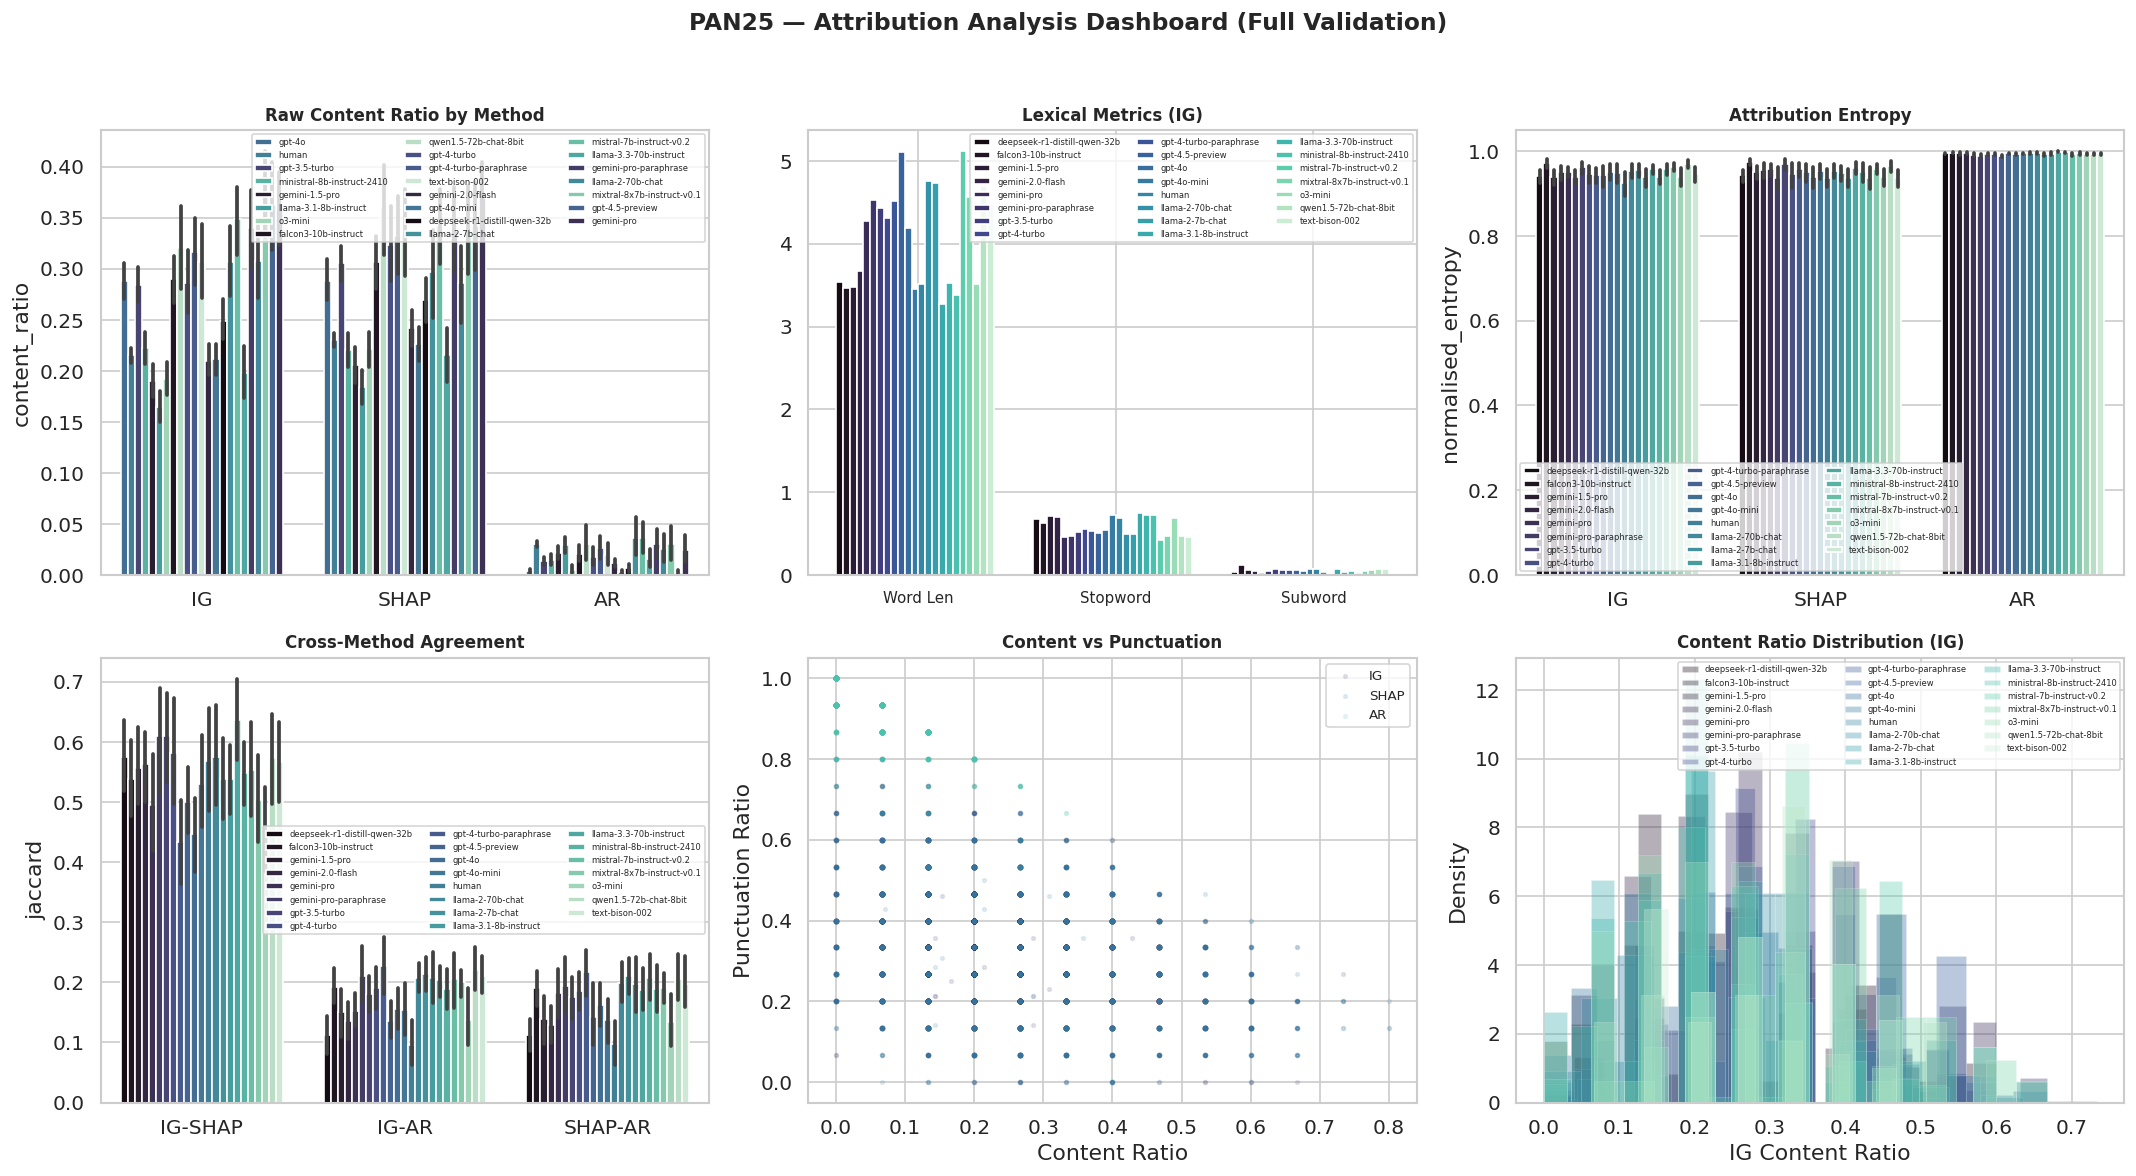

Saved PNG: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/authormix_attribution_analysis_dashboard.png
Saved PDF: /content/drive/MyDrive/ap-thesis/runs/plots/dashboards/authormix_attribution_analysis_dashboard.pdf


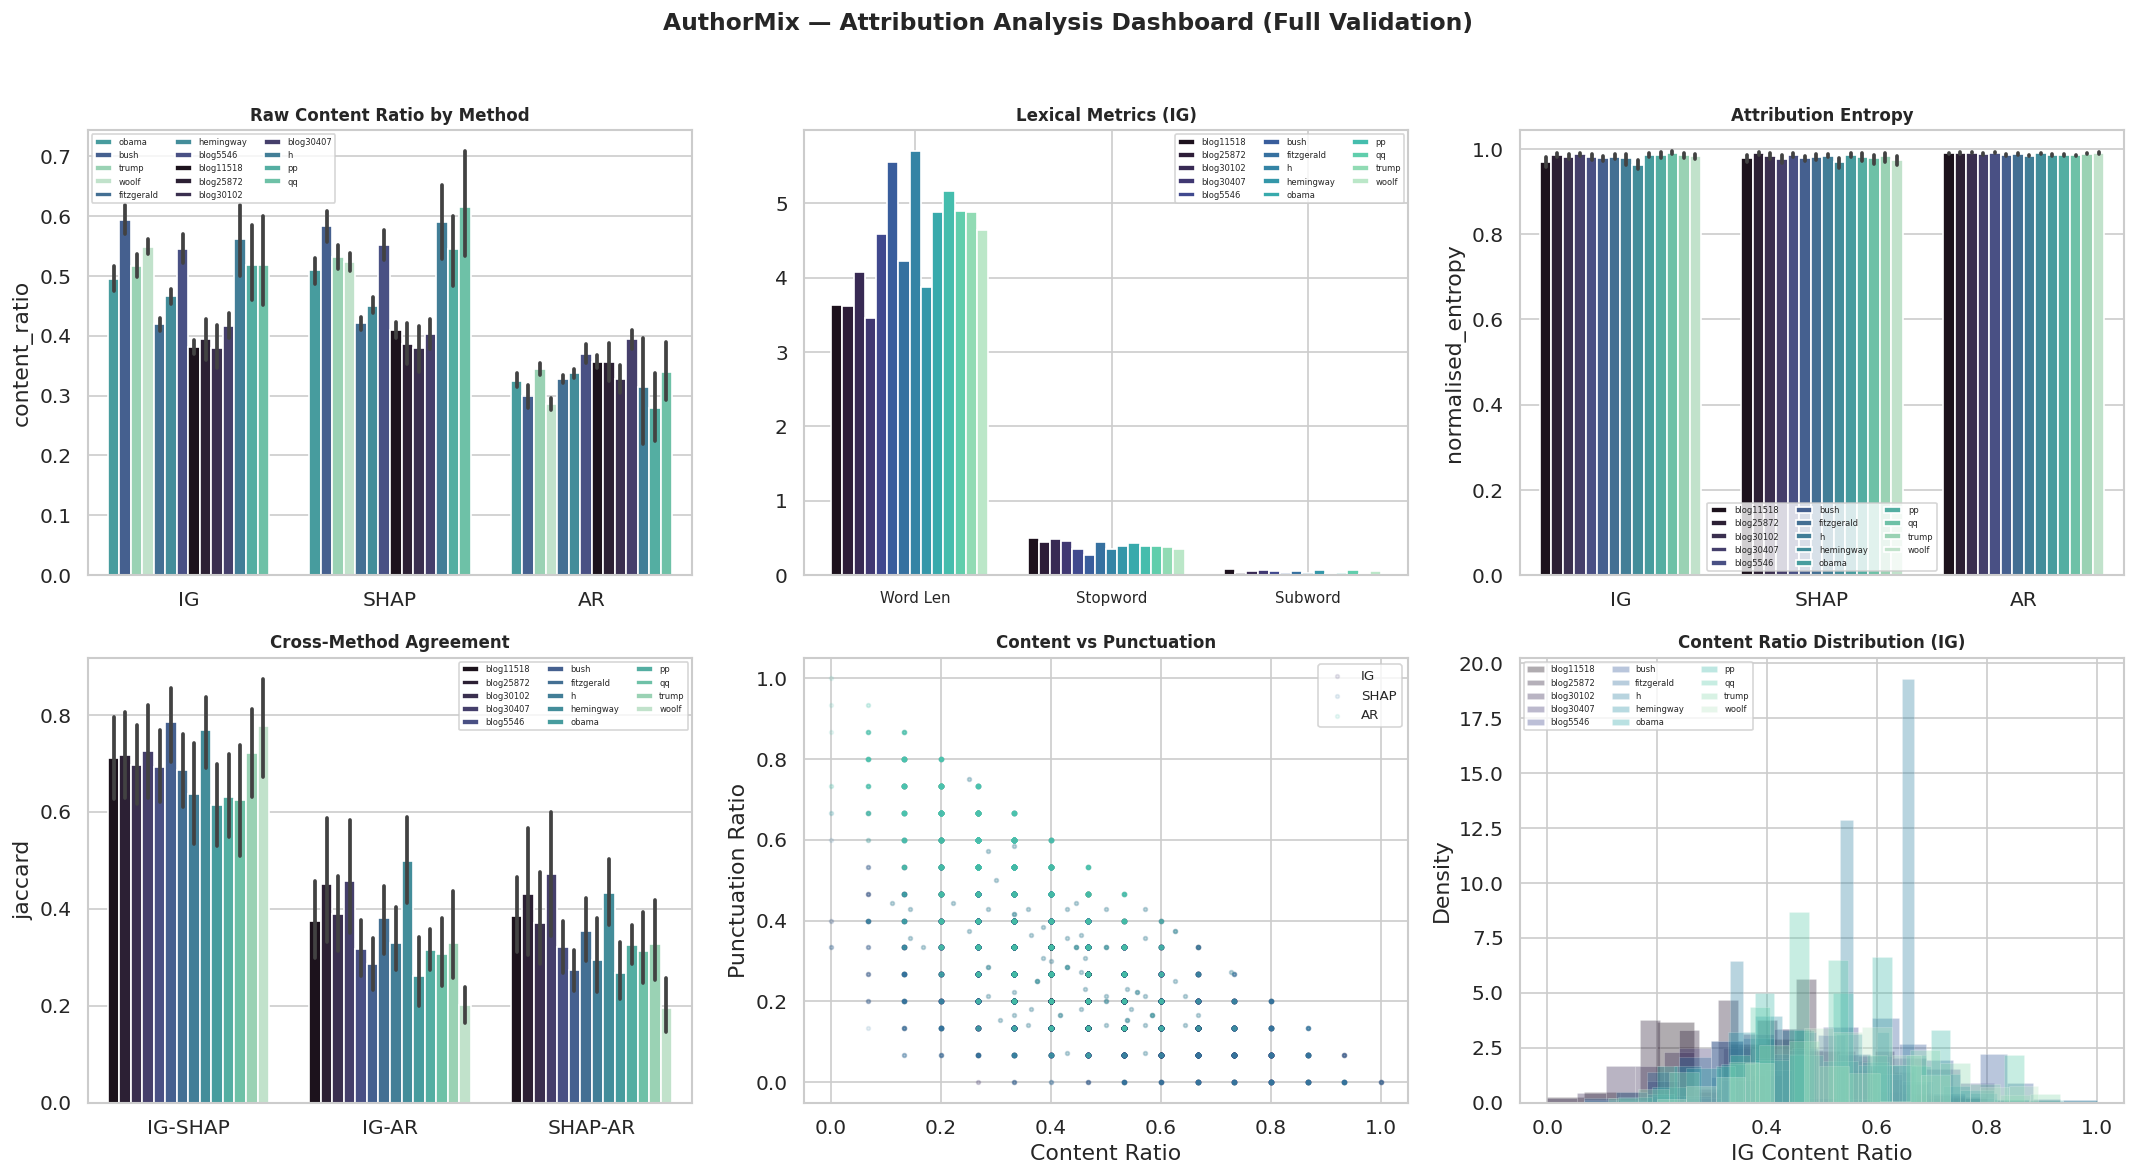

In [49]:
DASHBOARD_DIR = f"{RUNS_ROOT}/plots/dashboards"

summary_dashboard(pan_data, pan_ratios, "PAN25", save_dir=DASHBOARD_DIR)
summary_dashboard(am_data, am_ratios, "AuthorMix", save_dir=DASHBOARD_DIR)

## 12. Save final summary

In [26]:
# Save per-class ratio summaries for both datasets
for name, df in [("pan25", pan_ratios), ("authormix", am_ratios)]:
    summary_rows = []
    for prefix, label in [("ig", "IG"), ("gs", "SHAP"), ("ar", "AR")]:
        for ratio in RATIO_TYPES:
            col = f"{prefix}_{ratio}"
            grouped = df.groupby("class")[col].agg(["mean", "std", "count"])
            for cls, row in grouped.iterrows():
                summary_rows.append({
                    "class": cls,
                    "method": label,
                    "metric": ratio,
                    "mean": round(row["mean"], 4),
                    "std": round(row["std"], 4),
                    "n": int(row["count"]),
                })

    out = f"{RUNS_ROOT}/results/{name}_full_validation_ratio_summary.csv"
    pd.DataFrame(summary_rows).to_csv(out, index=False)
    print(f"Saved: {out}")

# Save cross-method agreement summary
for name, data in [("pan25", pan_data), ("authormix", am_data)]:
    agree_df = pairwise_agreement(data)
    summary = agree_df.groupby(["class", "pair"])["jaccard"].agg(["mean", "std"]).round(4)
    out = f"{RUNS_ROOT}/results/{name}_full_validation_agreement_summary.csv"
    summary.to_csv(out)
    print(f"Saved: {out}")

print("\nAll enhanced analysis results saved.")

Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_full_validation_ratio_summary.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_full_validation_ratio_summary.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/pan25_full_validation_agreement_summary.csv
Saved: /content/drive/MyDrive/ap-thesis/runs/results/authormix_full_validation_agreement_summary.csv

All enhanced analysis results saved.


Additional.


In [28]:
import os, json, gzip, re as _re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from itertools import combinations
from collections import defaultdict

try:
    mako_palette
except NameError:
    def mako_palette(n, reverse=False):
        colors = sns.color_palette("mako", n_colors=max(n, 1))
        if reverse:
            colors = list(reversed(colors))
        return colors[:n]

try:
    RESULTS
except NameError:
    RESULTS = f"{ROOT}/runs/results"
PLOTS_DIR = f"{ROOT}/thesis plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

_CAT = mako_palette(4)
CAT_COLOR  = {"content": _CAT[0], "stop": _CAT[1], "punct": _CAT[2], "newline": _CAT[3]}
_MOD = mako_palette(2)
MODEL_COLOR = {"BERT": _MOD[0], "ModernBERT": _MOD[1]}
CATS = ["content", "stop", "punct", "newline"]

RATIOS = {
    ("BERT","PAN25"):"pan25_full_validation_all_methods_ratios.csv",
    ("BERT","AuthorMix"):"authormix_full_validation_all_methods_ratios.csv",
    ("ModernBERT","PAN25"):"pan25_modernbert_full_validation_all_methods_ratios.csv",
    ("ModernBERT","AuthorMix"):"authormix_modernbert_full_validation_all_methods_ratios.csv",
}
ATTRIB = {
    ("BERT","PAN25"):"pan25_full_validation_all_methods_attributions.json",
    ("BERT","AuthorMix"):"authormix_full_validation_all_methods_attributions.json",
    ("ModernBERT","PAN25"):"pan25_modernbert_full_validation_all_methods_attributions.json.gz",
    ("ModernBERT","AuthorMix"):"authormix_modernbert_full_validation_all_methods_attributions.json",
}

def save_fig(fig, name):
    path = os.path.join(PLOTS_DIR, name + ".pdf")
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("saved", path)

def _ratios(model, dataset):
    return pd.read_csv(os.path.join(RESULTS, RATIOS[(model, dataset)]))

def _attrib(model, dataset):
    p = os.path.join(RESULTS, ATTRIB[(model, dataset)])
    if not os.path.exists(p) or os.path.getsize(p) < 100:
        return None
    op = gzip.open if p.endswith(".gz") else open
    with op(p, "rt", encoding="utf-8") as f:
        return json.load(f)

# token decoding + content filter (figure 5)
def _b2u():
    bs=list(range(33,127))+list(range(161,173))+list(range(174,256)); cs=bs[:]; n=0
    for b in range(256):
        if b not in bs: bs.append(b); cs.append(256+n); n+=1
    return {chr(c):b for b,c in zip(bs,cs)}
_BD=_b2u()
_STOP=set(("i me my myself we our ours ourselves you your yours yourself yourselves he him his "
"himself she her hers herself it its itself they them their theirs themselves what which who "
"whom this that these those am is are was were be been being have has had having do does did "
"doing a an the and but if or because as until while of at by for with about against between "
"into through during before after above below to from up down in out on off over under again "
"further then once here there when where why how all any both each few more most other some "
"such no nor not only own same so than too very s t can will just don should now d ll m o re "
"ve y").split())
def _decode(tok, model):
    if model=="ModernBERT":
        try: return bytes(_BD[c] for c in tok).decode("utf-8", errors="replace")
        except KeyError: return tok
    return tok[2:] if tok.startswith("##") else tok
def _is_content(tok, model):
    if tok in ("[CLS]","[SEP]","[PAD]","[UNK]","[MASK]"): return False
    core=_decode(tok, model).strip()
    if core=="" or _re.fullmatch(r"\W+", core): return False
    return core.lower() not in _STOP

# figure 1: token-type ratios (content/stop/punct/newline)
def fig1_token_type_ratios(model, dataset):
    df=_ratios(model, dataset)
    methods=[("ig","IG"),("gs","GradientSHAP"),("ar","Attention Rollout")]
    fig,ax=plt.subplots(figsize=(9,5.2))
    x=np.arange(len(methods)); w=0.2
    for i,c in enumerate(CATS):
        ax.bar(x+i*w, [df[f"{m}_{c}_ratio"].mean() for m,_ in methods], w,
               label=c.capitalize(), color=CAT_COLOR[c], edgecolor="white")
    ax.set_xticks(x+1.5*w); ax.set_xticklabels([l for _,l in methods])
    ax.set_ylabel("Mean ratio of top-15 tokens"); ax.set_ylim(0,1)
    ax.legend(title="Token type")
    ax.set_title(f"{dataset} ({model}) — Mean Token-Type Ratios of Top Attributed Tokens",
                 fontsize=12, fontweight="bold")
    save_fig(fig, f"fig1_token_type_ratios_{dataset.lower()}_{model.lower()}")

# figure 2: non-newline content ratio, BERT vs ModernBERT
def fig2_nonnewline_content(dataset, method="ig"):
    out={}
    for model in ("BERT","ModernBERT"):
        df=_ratios(model, dataset)
        c,s,p=(df[f"{method}_content_ratio"],df[f"{method}_stop_ratio"],df[f"{method}_punct_ratio"])
        denom=(c+s+p).replace(0,np.nan)
        out[model]=df.assign(cnn=c/denom).groupby("class")["cnn"].mean()
    classes=out["ModernBERT"].sort_values().index.tolist()
    fig,ax=plt.subplots(figsize=(10,max(4.5,0.42*len(classes))))
    y=np.arange(len(classes)); h=0.4
    for i,model in enumerate(("BERT","ModernBERT")):
        ax.barh(y+i*h,[out[model].get(cl,np.nan) for cl in classes],h,
                label=model,color=MODEL_COLOR[model],edgecolor="white")
    ax.set_yticks(y+h/2); ax.set_yticklabels(classes)
    ax.set_xlabel("Content ratio (renormalised over non-newline tokens)"); ax.set_xlim(0,1)
    ax.legend()
    ax.set_title(f"{dataset} — Content Ratio by Class, BERT vs ModernBERT (non-newline tokens)",
                 fontsize=12, fontweight="bold")
    save_fig(fig, f"fig2_content_nonnewline_{dataset.lower()}")

# figure 3: Attention Rollout comparison
def fig3_ar_comparison(dataset):
    means={m:[_ratios(m,dataset)[f"ar_{c}_ratio"].mean() for c in CATS]
           for m in ("BERT","ModernBERT")}
    fig,ax=plt.subplots(figsize=(8.5,5))
    x=np.arange(len(CATS)); w=0.38
    for i,model in enumerate(("BERT","ModernBERT")):
        ax.bar(x+i*w,means[model],w,label=model,color=MODEL_COLOR[model],edgecolor="white")
    ax.set_xticks(x+w/2); ax.set_xticklabels([c.capitalize() for c in CATS])
    ax.set_ylabel("Mean Attention Rollout ratio"); ax.set_ylim(0,1); ax.legend()
    ax.set_title(f"{dataset} — Attention Rollout Token-Type Ratios, BERT vs ModernBERT",
                 fontsize=12, fontweight="bold")
    save_fig(fig, f"fig3_attention_rollout_{dataset.lower()}")

# figure 4: cross-method agreement
def fig4_agreement(model, dataset):
    data=_attrib(model, dataset)
    if data is None:
        print(f"[skip] fig4 {model} {dataset}: attribution JSON unavailable"); return
    methods=[("top_ig","IG"),("top_gs","SHAP"),("top_ar","AR")]
    pv=defaultdict(list)
    for ex in data:
        sets={l:set(t[0] for t in ex.get(k,[])) for k,l in methods}
        for (l1,s1),(l2,s2) in combinations(sets.items(),2):
            u=s1|s2; pv[f"{l1}-{l2}"].append(len(s1&s2)/len(u) if u else 0.0)
    pairs=["IG-SHAP","IG-AR","SHAP-AR"]; means={p:np.mean(pv[p]) for p in pairs}
    fig,axes=plt.subplots(1,2,figsize=(12,4.2))
    axes[0].bar(pairs,[means[p] for p in pairs],
                color=mako_palette(3),edgecolor="white")
    axes[0].set_ylim(0,1); axes[0].set_ylabel("Mean Jaccard overlap")
    axes[0].set_title("Mean overlap by method pair", fontsize=11)
    labels=["IG","SHAP","AR"]; mat=np.eye(3)
    for p,(i,j) in {"IG-SHAP":(0,1),"IG-AR":(0,2),"SHAP-AR":(1,2)}.items():
        mat[i,j]=mat[j,i]=means[p]
    sns.heatmap(mat,annot=True,fmt=".2f",xticklabels=labels,yticklabels=labels,
                cmap="mako",vmin=0,vmax=1,square=True,ax=axes[1],
                cbar_kws={"label":"Jaccard"})
    axes[1].set_title("Pairwise agreement", fontsize=11)
    fig.suptitle(f"{dataset} ({model}) — Cross-Method Agreement (IG, SHAP, Attention Rollout)",
                 fontsize=12, fontweight="bold")
    save_fig(fig, f"fig4_agreement_{dataset.lower()}_{model.lower()}")

# figure 5: vocabulary fingerprint table
def fig5_fingerprint_table(model, dataset, top_n=8):
    data=_attrib(model, dataset)
    if data is None:
        print(f"[skip] fig5 {model} {dataset}: attribution JSON unavailable"); return
    bc=defaultdict(lambda: defaultdict(float))
    for ex in data:
        for tok,score in ex.get("top_ig",[]):
            if not _is_content(tok, model): continue
            bc[ex["class_name"]][_decode(tok,model).strip().lower()]+=abs(float(score))
    rows=[]
    for cls in sorted(bc):
        top=sorted(bc[cls].items(),key=lambda kv:-kv[1])[:top_n]
        rows.append([cls]+[w for w,_ in top])
    ncol=max((len(r) for r in rows),default=1)
    rows=[r+[""]*(ncol-len(r)) for r in rows]
    fig,ax=plt.subplots(figsize=(1.5*ncol,0.5*len(rows)+1)); ax.axis("off")
    tbl=ax.table(cellText=[r[1:] for r in rows],rowLabels=[r[0] for r in rows],
                 colLabels=[f"#{i+1}" for i in range(ncol-1)],loc="center",cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.4)

    header_color = mako_palette(1)[0]
    row_colors = mako_palette(max(len(rows), 1))
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("white")
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color="white", weight="bold")
        elif col == -1:
            cell.set_facecolor(row_colors[(row - 1) % len(row_colors)])
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor((1, 1, 1, 1))
    ax.set_title(f"{dataset} ({model}) — Per-Class Vocabulary Fingerprints",
                 fontsize=12, fontweight="bold", pad=20)
    save_fig(fig, f"fig5_fingerprints_{dataset.lower()}_{model.lower()}")

# figure 6: positional distribution
def fig6_positional(model, dataset, sample_per_class=30, seed=42):
    data=_attrib(model, dataset)
    if data is None:
        print(f"[skip] fig6 {model} {dataset}: attribution JSON unavailable"); return
    rng=np.random.default_rng(seed); bc=defaultdict(list)
    for ex in data: bc[ex["class_name"]].append(ex)
    thirds={"First third":[],"Middle third":[],"Last third":[]}
    for cls,exs in bc.items():
        for k in rng.choice(len(exs),size=min(sample_per_class,len(exs)),replace=False):
            ex=exs[k]; toks=ex["tokens"]; n=max(len(toks)-1,1)
            used,pos=set(),[]
            for tok,_ in ex.get("top_ig",[]):
                for j,t in enumerate(toks):
                    if j not in used and t==tok:
                        used.add(j); pos.append(j/n); break
            if not pos: continue
            pos=np.array(pos)
            thirds["First third"].append(np.mean(pos<0.33))
            thirds["Middle third"].append(np.mean((pos>=0.33)&(pos<0.67)))
            thirds["Last third"].append(np.mean(pos>=0.67))
    labels=list(thirds)
    fig,ax=plt.subplots(figsize=(7,4.5))
    ax.bar(labels,[np.mean(thirds[k]) for k in labels],
           color=mako_palette(3),edgecolor="white")
    ax.set_ylabel("Mean share of top attributed tokens"); ax.set_ylim(0,1)
    ax.set_title(f"{dataset} ({model}) — Positional Distribution of Top Attributed Tokens",
                 fontsize=12, fontweight="bold")
    save_fig(fig, f"fig6_positional_{dataset.lower()}_{model.lower()}")


In [29]:
for ds in ("PAN25", "AuthorMix"):
    fig1_token_type_ratios("BERT", ds)
    fig4_agreement("BERT", ds)
    fig5_fingerprint_table("BERT", ds)
    fig6_positional("BERT", ds)


saved /content/drive/MyDrive/ap-thesis/thesis plots/fig1_token_type_ratios_pan25_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig4_agreement_pan25_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig5_fingerprints_pan25_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig6_positional_pan25_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig1_token_type_ratios_authormix_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig4_agreement_authormix_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig5_fingerprints_authormix_bert.pdf
saved /content/drive/MyDrive/ap-thesis/thesis plots/fig6_positional_authormix_bert.pdf
